In [1]:
# Tokenizer avec Stanza
# Repérér les ngrams avec NLTK
# LDA avec Sklearn

In [2]:
# Unigrams vs ngrams
# Lemmatiser vs ne pas lemmatiser

# My notes

- For stanza: https://stanfordnlp.github.io/stanza/data_objects.html
- nltk collocations: https://www.nltk.org/api/nltk.collocations.html
- what does collocations and what exactly is the methods used (potentially): https://link.springer.com/article/10.1007/s10579-009-9101-4
- overstack example: https://stackoverflow.com/questions/8683588/understanding-nltk-collocation-scoring-for-bigrams-and-trigrams
- package example: https://www.nltk.org/howto/collocations.html

## Imports et lecture des données

In [1]:
# !pip install stanza

In [1]:
import stanza
from stanza.models.common.doc import Document

from nltk.collocations import QuadgramCollocationFinder, TrigramCollocationFinder, BigramCollocationFinder
from nltk.metrics import QuadgramAssocMeasures, TrigramAssocMeasures, BigramAssocMeasures
from nltk.probability import FreqDist

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from scipy import stats
import matplotlib.pyplot as plt

import re
import json
from time import time


In [2]:
df = pd.read_csv('FedSpeechesWithTime.csv', parse_dates = ['date','dateOnly'])
print(df.shape)
df['text'] = df['content'].astype(str)
df.head()


(7239, 83)


,District,MultSpeakers,VideoForm,Article,content,title,speaker,location,link,date,...,second_order_coherence,upStrain,board_role,IsBpres,title_main,name,dateOnly,timeOnly,score,text
0,Boston,0.0,False,False,"Economic Resilience, Amid Elevated Tariffs and...",Perspectives on the Economy from Susan M. Collins,Susan M. Collins,"Massachusetts towns of Fall River, New Bedford...",https://www.bostonfed.org/news-and-events/spee...,2025-06-25,...,0.511636,4.969992,Not Board,True,perspectives on the economy from susan m collins,susan collins,2025-06-25,NaN,NaN,"Economic Resilience, Amid Elevated Tariffs and..."
1,Boston,0.0,False,False,I am pleased to welcome all of you to the Fede...,Welcoming Remarks at the forum on “Meeting the...,Susan M. Collins,Federal Reserve Bank of Boston,https://www.bostonfed.org/news-and-events/spee...,2024-09-30,...,0.416154,5.349004,Not Board,True,welcoming remarks at the forum on meeting the ...,susan collins,2024-09-30,NaN,NaN,I am pleased to welcome all of you to the Fede...
2,Boston,0.0,False,False,Takeaways from Boston Fed President Susan M. C...,A Partnership for Progress,Susan M. Collins,"Lawrence, Massachusetts",https://www.bostonfed.org/news-and-events/spee...,2024-06-18,...,0.397782,4.661486,Not Board,True,a partnership for progress,susan collins,2024-06-18,NaN,NaN,Takeaways from Boston Fed President Susan M. C...
3,Boston,0.0,False,False,Boston Fed President and CEO Susan M. Collins'...,Reflections on Uncertainty and Patience in Mon...,Susan M. Collins,"Cambridge, Massachusetts",https://www.bostonfed.org/news-and-events/spee...,2024-05-08,...,0.446677,4.695629,Not Board,True,reflections on uncertainty and patience in mon...,susan collins,2024-05-08,NaN,NaN,Boston Fed President and CEO Susan M. Collins'...
4,Boston,1.0,True,False,"hi, good afternoon everyone. my name is Beth B...",Remarks for the National Association of Corpor...,Susan M. Collins,Federal Reserve Bank of Boston,https://www.bostonfed.org/news-and-events/spee...,2024-04-16,...,0.361304,5.368856,Not Board,True,remarks for the national association of corpor...,susan collins,2024-04-16,NaN,NaN,"hi, good afternoon everyone. my name is Beth B..."


In [3]:
# ici, on prend comme unité élémentaire le statement, mais on pourrait aussi joindre par individu

In [4]:
shuffled_df = df.sample(frac=1, random_state=118712)
shuffled_df

,District,MultSpeakers,VideoForm,Article,content,title,speaker,location,link,date,...,second_order_coherence,upStrain,board_role,IsBpres,title_main,name,dateOnly,timeOnly,score,text
5876,SanFrancisco,NaN,False,False,"HOLD FOR RELEASE AT 8:30 A.M. PST FRIDAY, NOVE...",Shifting to Another Gear: Monetary Policy in 1...,Robert T. Parry,Federal Reserve Bank of San Francisco,https://fraser.stlouisfed.org/files/docs/histo...,1994-11-04,...,0.367792,4.531372,Not Board,True,shifting to another gear monetary policy in 19...,robert parry,1994-11-04,NaN,NaN,"HOLD FOR RELEASE AT 8:30 A.M. PST FRIDAY, NOVE..."
6306,StLouis,NaN,False,False,President's Message: The Fed's Latest Balance-...,The Fed's Latest Balance-Sheet Policy: What Co...,James Bullard,Federal Reserve Bank of St Louis,https://www.stlouisfed.org/publications/region...,2013-01-18,...,0.443078,4.847228,Not Board,True,the feds latest balancesheet policy what const...,james bullard,2013-01-18,00:00:00,90.25641,President's Message: The Fed's Latest Balance-...
798,BoardGovernors,NaN,False,False,"Roger W Ferguson, Jr: Panel discussion - safeg...",Panel discussion - safeguarding good policy pr...,Roger W Ferguson,Board of Governors of the Federal Reserve,https://www.bis.org/review/r041013k.pdf,2004-10-08,...,0.468183,5.560085,Vice Chair,False,panel discussion safeguarding good policy pra...,roger ferguson,2004-10-08,NaN,NaN,"Roger W Ferguson, Jr: Panel discussion - safeg..."
5013,Richmond,NaN,False,False,Home News Speeches Jeffrey M Lacker 2008 Jeffr...,The Economic Outlook for 2008,Jeffrey M Lacker,Federal Reserve Bank of Richmond,https://www.richmondfed.org/press_room/speeche...,2008-02-05,...,0.473368,4.214442,Not Board,False,the economic outlook for 2008,jeffrey lacker,2008-02-05,NaN,NaN,Home News Speeches Jeffrey M Lacker 2008 Jeffr...
4609,Dallas,NaN,False,False,14:23 Ending 'Too Big to Fail' Speech by Richa...,Ending 'Too Big to Fail',Richard W. Fisher,Federal Reserve Bank of Dallas,https://www.dallasfed.org/news/speeches/fisher...,2013-03-16,...,0.410897,4.701037,Not Board,True,ending too big to fail,richard fisher,2013-03-16,14:00:00,100.00000,14:23 Ending 'Too Big to Fail' Speech by Richa...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4695,Kansas,NaN,False,False,Maintaining Stability in a Changing Financial ...,Maintaining Stability in a Changing Financial ...,Thomas M. Hoenig,Federal Reserve Bank of Kansas City,https://www.kansascityfed.org/documents/2204/H...,2007-11-06,...,0.495487,4.327230,Not Board,True,maintaining stability in a changing financial ...,thomas hoenig,2007-11-06,NaN,NaN,Maintaining Stability in a Changing Financial ...
3310,Boston,NaN,False,False,"EMBARGOED UNTIL October 18, 2014 at 8:30 Can E...",Can Economic Opportunity Flourish When Communi...,Eric S. Rosengren,Federal Reserve Bank of Boston,https://www.bostonfed.org/news-and-events/spee...,2014-10-18,...,0.428881,5.066549,Not Board,True,can economic opportunity flourish when communi...,eric rosengren,2014-10-18,08:30:00,100.00000,"EMBARGOED UNTIL October 18, 2014 at 8:30 Can E..."
1909,NewYork,NaN,False,False,Kevin Stiroh: The theory and practice of super...,The theory and practice of supervision,Kevin Stiroh,Federal Reserve Bank of New York,https://www.bis.org/review/r160418a.htm,2016-04-11,...,0.441783,4.358094,Not Board,False,the theory and practice of supervision,kevin stiroh,2016-04-11,NaN,NaN,Kevin Stiroh: The theory and practice of super...
3467,BoardGovernors,NaN,False,False,Remarks by Chairman Alan Greenspan At the Fede...,Banking in the global marketplace,Alan Greenspan,Board of Governors of the Federal Reserve,https://www.federalreserve.gov/boarddocs/speec...,1996-11-18,...,0.449692,4.715885,Chair,False,banking in the global marketplace,alan greenspan,1996-11-18,NaN,NaN,Remarks by Chairman Alan Greenspan At the Fede...


In [5]:
text = shuffled_df['content'].to_list()
text[:3]

['HOLD FOR RELEASE AT 8:30 A.M. PST FRIDAY, NOVEMBER 4, 1994 Western Growers Association Robert T. Parry, President Tucson, AZ Federal Reserve Bank of San Francisco For delivery on November 4, 1994 Shifting to Another Gear: Monetary Policy in 1994 I. Good morning. A. This year monetary policy began shifting into another gear. 1. After four years of gradually lowering short-term interest rates to stimulate the economys recovery from recession, the Fed began raising rates in February. a. All told, this year, there have been five rate increases, b. taking the federal funds rate from 3 percent to 4% percent. B. The Fed took these actions to contain the buildup of inflationary pressures, which is key to fostering sustainable economic growth. C. Our moves have been met with controversy in some quarters. 1. For example, the economy in California is still pretty weak. a. This has led some critics to ask, "Why not help the weak parts of the country before worrying about inflationary 2. Others a

## Stop words

In [8]:
# http://snowball.tartarus.org/algorithms/english/stop.txt

In [6]:
stop_words_selected = []
with open('stopwords-en.txt') as f:
    for line in f:
        if re.match(r'[a-z]', line): # la ligne commence par une lettre
            stop_words_selected.append(line.split(' ')[0].rstrip())
stop_words_selected

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 'her',
 'hers',
 'herself',
 'it',
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'would',
 'should',
 'could',
 'ought',
 "i'm",
 "you're",
 "he's",
 "she's",
 "it's",
 "we're",
 "they're",
 "i've",
 "you've",
 "we've",
 "they've",
 "i'd",
 "you'd",
 "he'd",
 "she'd",
 "we'd",
 "they'd",
 "i'll",
 "you'll",
 "he'll",
 "she'll",
 "we'll",
 "they'll",
 "isn't",
 "aren't",
 "wasn't",
 "weren't",
 "hasn't",
 "haven't",
 "hadn't",
 "doesn't",
 "don't",
 "didn't",
 "won't",
 "wouldn't",
 "shan't",
 "shouldn't",
 "can't",
 'cannot',
 "couldn't",
 "mustn't",
 "let's",
 "that's",
 "who's",
 "what'

## Tokenization (Stanza)

In [25]:
# stanza.download('en', processors='tokenize,lemma')

2026-04-06 12:28:55 INFO: Downloaded file to C:\Users\Lynn\stanza_resources\resources.json
2026-04-06 12:28:55 WARNING: Language en package default expects mwt, which has been added
2026-04-06 12:28:55 INFO: Downloading these customized packages for language: en (English)...
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| lemma     | combined_nocharlm |

2026-04-06 12:28:55 INFO: File exists: C:\Users\Lynn\stanza_resources\en\tokenize\combined.pt
2026-04-06 12:28:55 INFO: File exists: C:\Users\Lynn\stanza_resources\en\mwt\combined.pt
2026-04-06 12:28:55 INFO: File exists: C:\Users\Lynn\stanza_resources\en\lemma\combined_nocharlm.pt
2026-04-06 12:28:55 INFO: Finished downloading models and saved to C:\Users\Lynn\stanza_resources


In [27]:
# nlp = stanza.Pipeline('en', processors='tokenize,lemma', verbose=True, download_method=None, pos_batch_size=3000)

2026-04-06 12:29:02 WARNING: Language en package default expects mwt, which has been added
2026-04-06 12:29:02 INFO: Loading these models for language: en (English):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| lemma     | combined_nocharlm |

2026-04-06 12:29:02 INFO: Using device: cpu
2026-04-06 12:29:02 INFO: Loading: tokenize
2026-04-06 12:29:05 INFO: Loading: mwt
2026-04-06 12:29:05 INFO: Loading: lemma
2026-04-06 12:29:06 INFO: Done loading processors!


In [7]:
len(text)

7239

In [8]:
from tqdm import tqdm

In [32]:
# # To execute if not already saved json
# out_docs = []
# for i in tqdm(list(range((len(text)//100)+1))):
#     start = i*100
#     stop = min(i*100+99, len(text))+1
#     print(start, stop)
#     in_docs = [stanza.Document([], text=d) for d in text[start:stop]] # Wrap each document with a stanza.Document object
#     out_docs.append(nlp(in_docs)) # Call the neural pipeline on this list of documents

  0%|          | 0/73 [00:00<?, ?it/s]

0 100


  1%|▏         | 1/73 [00:50<1:00:54, 50.75s/it]

100 200


  3%|▎         | 2/73 [01:43<1:01:18, 51.81s/it]

...

 97%|█████████▋| 71/73 [1:02:00<01:42, 51.10s/it]

7100 7200


 99%|█████████▊| 72/73 [1:03:03<00:54, 54.69s/it]

7200 7240


100%|██████████| 73/73 [1:03:23<00:00, 52.10s/it]


In [33]:
# out = [v.to_dict() for chunk in out_docs for v in chunk]

In [34]:
# with open('annotations_stanza.json', 'w') as f:
#     json.dump(out, f, indent=4)

In [17]:
with open('annotations_stanza.json', 'r') as f:
    from_json = json.load(f)

Old code

In [65]:
# # Mettre from_json au format tokénisé
# tokenized_statements = []
# for i, doc in enumerate(from_json):
#     temp = []
#     for sent in doc:
#         for tok in sent:
#             if isinstance(tok['id'], tuple): # This line does not work as there are no tuple
#                 temp.append(f"{tok['text'].lower()}#{tok['lemma'].lower()}")
# #             elif isinstance(tok['id'], list): # multi-word token
# #                 continue
#     tokenized_statements.append(temp)
    

In [67]:
# # Finding out what happened
# doc = from_json[0]
# temp = []
# sent = doc[0]
# tok = sent[0]
# print(tok)
# print(isinstance(tok['id'], tuple))
# print(tok['id'])
# print(f"{tok['text'].lower()}#{tok['lemma'].lower()}")

{'id': 1, 'text': 'The', 'lemma': 'the', 'start_char': 0, 'end_char': 3}
False
1
the#the


New code

In [18]:
# Mettre from_json au format tokénisé
tokenized_statements = []
for i, doc in enumerate(from_json):
    temp = []
    for sent in doc:
        for tok in sent:
            if isinstance(tok['id'], int): # This line does not work as there are no tuple
                temp.append(f"{tok['text'].lower()}#{tok['lemma'].lower()}")
            elif isinstance(tok['id'], list): # multi-word token
                continue
    tokenized_statements.append(temp)
    

In [19]:
tokenized_statements_mots = []
for st in tokenized_statements:
    temp = []
    for token in st:
        temp.append(token.split('#')[0])
    tokenized_statements_mots.append(temp)

In [20]:
tokenized_statements_lemmas = []
for st in tokenized_statements:
    temp = []
    for token in st:
        temp.append(token.split('#')[1])
    tokenized_statements_lemmas.append(temp)

New code

In [17]:
text[3]

'THE INTERNATIONAL ECONOMIC OUTLOOK FOR 1994 Remarks by Robert P. Forrestal President and Chief Executive Officer Federal Reserve Bank of Atlanta To the German American Chamber of Commerce Atlanta, Georgia February 7, 1994 It is always a pleasure to visit the World Trade Club Atlanta to address the German American Chamber of Commerce and the other co-sponsoring groups on the topic of my international economic outlook for the new year. This year, I find myself in the enviable position of being able to report on many positive developments in international trade as well as some promising changes in the long-term outlook for the United States. At the same time, I must speak less happily about the state of the world economy in which many ordinarily resilient economies have been experiencing slowdowns and recessions. Overall, there are some notable contradictions in the world situation today. Like the lyrics from a Broadway musical by Stephen Sondheim: "Whats hard is simple, whats natural co

In [ ]:
tokenized_statements[3]

In [ ]:
tokenized_statements_mots[3]

In [21]:
tokenized_statements_lemmas[3]

['home',
 'news',
 'speeches',
 'jeffrey',
 'm',
 'lacker',
 '2008',
 'jeffrey',
 'm.',
 'lacker',
 'the',
 'economic',
 'outlook',
 'for',
 '2008',
 'february',
 '5',
 ',',
 '2008',
 'jeffrey',
 'm.',
 'lacker',
 'president',
 ',',
 'federal',
 'reserve',
 'bank',
 'of',
 'richmond',
 'remark',
 'to',
 'the',
 'west',
 'virginia',
 'bankers',
 'association',
 'and',
 'the',
 'community',
 'bankers',
 'of',
 'west',
 'virginia',
 'charleston',
 ',',
 'w.va',
 '.',
 'download',
 'speech',
 'related',
 'multimedia',
 'download',
 'mp3',
 'it',
 "'s",
 'a',
 'pleasure',
 'to',
 'be',
 'with',
 'you',
 '.',
 'while',
 'the',
 'economy',
 'be',
 'seldom',
 'far',
 'from',
 'many',
 'person',
 "'s",
 'mind',
 ',',
 'think',
 'it',
 "'s",
 'fair',
 'to',
 'say',
 'that',
 'economic',
 'condition',
 'be',
 'garnering',
 'a',
 'bit',
 'more',
 'attention',
 'than',
 'usual',
 'right',
 'now',
 '.',
 'housing',
 'market',
 'have',
 'deteriorate',
 'over',
 'the',
 'last',
 'two',
 'year',
 'and'

# Mots

## Ngrams

### Quadgrams

In [53]:
colloc_finder = QuadgramCollocationFinder.from_documents(tokenized_statements_mots)
features = pd.DataFrame.from_dict(colloc_finder.ngram_fd, orient='index').reset_index()
print(f"Nombre de quadgrams total: {features.shape[0]}")
features.columns = ['infos', 'count']
features = features [ features['count'] >= 50 ]
features = features.sort_values(by='count', ascending=False)
features

Nombre de quadgrams total: 9742844


,infos,count
919,"(,, mr., chairman, .)",8328
917,"(thank, you, ,, mr.)",7735
918,"(you, ,, mr., chairman)",7047
6924,"(it, seems, to, me)",4537
4057,"(the, federal, funds, rate)",4497
...,...,...
849218,"(-, for, -, one)",50
851658,"(and, the, second, is)",50
200376,"(alternative, b, ,, as)",50
17724,"(committee, as, a, whole)",50


In [54]:
features['mot_1'] = features['infos'].apply(lambda x: x[0].split('#')[0])
features['mot_2'] = features['infos'].apply(lambda x: x[1].split('#')[0])
features['mot_3'] = features['infos'].apply(lambda x: x[2].split('#')[0])
features['mot_4'] = features['infos'].apply(lambda x: x[3].split('#')[0])
features['ngram'] = features.apply(lambda x: f"{x['mot_1']} {x['mot_2']} {x['mot_3']} {x['mot_4']}", axis=1)
features = features[['ngram', 'count', 'mot_1', 'mot_2', 'mot_3', 'mot_4', 'infos']]
features


,ngram,count,mot_1,mot_2,mot_3,mot_4,infos
919,", mr. chairman .",8328,",",mr.,chairman,.,"(,, mr., chairman, .)"
917,"thank you , mr.",7735,thank,you,",",mr.,"(thank, you, ,, mr.)"
918,"you , mr. chairman",7047,you,",",mr.,chairman,"(you, ,, mr., chairman)"
6924,it seems to me,4537,it,seems,to,me,"(it, seems, to, me)"
4057,the federal funds rate,4497,the,federal,funds,rate,"(the, federal, funds, rate)"
...,...,...,...,...,...,...,...
849218,- for - one,50,-,for,-,one,"(-, for, -, one)"
851658,and the second is,50,and,the,second,is,"(and, the, second, is)"
200376,"alternative b , as",50,alternative,b,",",as,"(alternative, b, ,, as)"
17724,committee as a whole,50,committee,as,a,whole,"(committee, as, a, whole)"


In [57]:
# Ponctuation ?
sorted(list(set(list(''.join(features['ngram'].to_list())))))


[' ',
 '!',
 '"',
 '$',
 '&',
 "'",
 '(',
 ')',
 ',',
 '-',
 '.',
 '/',
 '0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 ':',
 ';',
 '?',
 '@',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 '¼',
 '½',
 '¾',
 '—',
 '’',
 '“',
 '”']

In [74]:
ponctuation = [
 ' ',
 '!',
 '"',
 '&',
 "'",
 '(',
 ')',
 ',',
 '-',
 '--',
 '.',
 '/',
 ':',
 ';',
 '?',
 '@',
 '—',
 '’',
 '“',
 '”'
]

In [61]:
features [features['ngram'].str.contains('@')]

,ngram,count,mot_1,mot_2,mot_3,mot_4,infos
45808,. @ laugh i,351,.,@,laugh,i,"(., @, laugh, i)"
41198,. ” @ laugh,190,.,”,@,laugh,"(., ”, @, laugh)"
24909,. @ laugh the,135,.,@,laugh,the,"(., @, laugh, the)"
19326,mr. chairman . @appendix,129,mr.,chairman,.,@appendix,"(mr., chairman, ., @appendix)"
41795,. @ laugh but,121,.,@,laugh,but,"(., @, laugh, but)"
347884,. @ laugh so,118,.,@,laugh,so,"(., @, laugh, so)"
187112,. @ laugh we,80,.,@,laugh,we,"(., @, laugh, we)"
589576,@ laugh i think,73,@,laugh,i,think,"(@, laugh, i, think)"
169122,. @ laugh in,67,.,@,laugh,in,"(., @, laugh, in)"
768442,. @ laugh it,65,.,@,laugh,it,"(., @, laugh, it)"


In [62]:
# il faut que j'ajoute une règle pour traiter les '@'

In [75]:
features = features[ (
    ~((features['mot_1'].isin(ponctuation)) | (features['mot_2'].isin(ponctuation)) | (features['mot_3'].isin(ponctuation)) | (features['mot_4'].isin(ponctuation)))
) & (
    ~((features['mot_1'].isin(stop_words_selected)) | (features['mot_4'].isin(stop_words_selected)))
) ]
features

,ngram,count,mot_1,mot_2,mot_3,mot_4,infos
12870,half of the year,909,half,of,the,year,"(half, of, the, year)"
14359,half of this year,864,half,of,this,year,"(half, of, this, year)"
6165,thank you very much,836,thank,you,very,much,"(thank, you, very, much)"
22391,end of the year,704,end,of,the,year,"(end, of, the, year)"
119583,shown in the middle,640,shown,in,the,middle,"(shown, in, the, middle)"
...,...,...,...,...,...,...,...
89784,one direction or another,50,one,direction,or,another,"(one, direction, or, another)"
268982,n't want to get,50,n't,want,to,get,"(n't, want, to, get)"
193982,think that is going,50,think,that,is,going,"(think, that, is, going)"
83774,shape of the yield,50,shape,of,the,yield,"(shape, of, the, yield)"


In [76]:
features.head(20)

,ngram,count,mot_1,mot_2,mot_3,mot_4,infos
12870,half of the year,909,half,of,the,year,"(half, of, the, year)"
14359,half of this year,864,half,of,this,year,"(half, of, this, year)"
6165,thank you very much,836,thank,you,very,much,"(thank, you, very, much)"
22391,end of the year,704,end,of,the,year,"(end, of, the, year)"
119583,shown in the middle,640,shown,in,the,middle,"(shown, in, the, middle)"
29814,value of the dollar,587,value,of,the,dollar,"(value, of, the, dollar)"
119659,shown in the bottom,584,shown,in,the,bottom,"(shown, in, the, bottom)"
35952,since our last meeting,562,since,our,last,meeting,"(since, our, last, meeting)"
35632,since the last meeting,549,since,the,last,meeting,"(since, the, last, meeting)"
119158,shown in the top,508,shown,in,the,top,"(shown, in, the, top)"


In [77]:
# apply filter to colloc_finder

In [78]:
kept_quadgrams = features['ngram'].to_list()
colloc_finder.apply_ngram_filter(lambda w1, w2, w3, w4: f"{w1} {w2} {w3} {w4}" not in kept_quadgrams)

In [79]:
len(colloc_finder.score_ngrams(QuadgramAssocMeasures.raw_freq))

870

In [80]:
likelihood_ratio = pd.DataFrame(colloc_finder.score_ngrams(QuadgramAssocMeasures.likelihood_ratio), columns=['infos', 'llr'])

In [81]:
likelihood_ratio

,infos,llr
0,"(say, that, i, think)",436902.968456
1,"(something, that, i, think)",420615.705235
2,"(growth, in, the, economy)",335777.853329
3,"(improvement, in, the, economy)",330258.623957
4,"(increase, in, the, federal)",328050.473018
...,...,...
865,"(labor, and, product, markets)",3419.330172
866,"(lender, of, last, resort)",3185.891999
867,"(overnight, bank, funding, rate)",2559.500749
868,"(first, and, second, quarters)",2474.204605


In [82]:
features = features.merge(likelihood_ratio, on='infos')
features

,ngram,count,mot_1,mot_2,mot_3,mot_4,infos,llr
0,half of the year,909,half,of,the,year,"(half, of, the, year)",214540.946685
1,half of this year,864,half,of,this,year,"(half, of, this, year)",107951.389240
2,thank you very much,836,thank,you,very,much,"(thank, you, very, much)",244226.141781
3,end of the year,704,end,of,the,year,"(end, of, the, year)",222829.295793
4,shown in the middle,640,shown,in,the,middle,"(shown, in, the, middle)",309278.514330
...,...,...,...,...,...,...,...,...
865,one direction or another,50,one,direction,or,another,"(one, direction, or, another)",8749.879969
866,n't want to get,50,n't,want,to,get,"(n't, want, to, get)",122639.608012
867,think that is going,50,think,that,is,going,"(think, that, is, going)",97606.095626
868,shape of the yield,50,shape,of,the,yield,"(shape, of, the, yield)",162991.520767


In [85]:
features.sort_values(by='llr', ascending=False).head(50)

,ngram,count,mot_1,mot_2,mot_3,mot_4,infos,llr
173,say that i think,123,say,that,i,think,"(say, that, i, think)",436902.968456
748,something that i think,54,something,that,i,think,"(something, that, i, think)",420615.705235
249,growth in the economy,99,growth,in,the,economy,"(growth, in, the, economy)",335777.853329
798,improvement in the economy,52,improvement,in,the,economy,"(improvement, in, the, economy)",330258.623957
78,increase in the federal,183,increase,in,the,federal,"(increase, in, the, federal)",328050.473018
212,strength in the economy,108,strength,in,the,economy,"(strength, in, the, economy)",326490.802052
315,weakness in the economy,90,weakness,in,the,economy,"(weakness, in, the, economy)",325555.067281
389,developments in the economy,80,developments,in,the,economy,"(developments, in, the, economy)",322800.657335
65,slack in the economy,200,slack,in,the,economy,"(slack, in, the, economy)",322572.574806
474,momentum in the economy,72,momentum,in,the,economy,"(momentum, in, the, economy)",321245.702288


Axes(0.125,0.11;0.775x0.77)


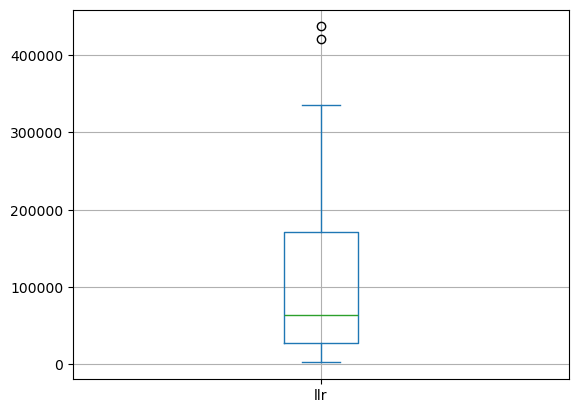

In [86]:
print( 
    features['llr'].plot.box(grid=True) 
)

In [92]:
print(features [ np.percentile(features['llr'], 80) <= features['llr'] ].sort_values(by='llr', ascending=False).to_markdown())

|     | ngram                          |   count | mot_1        | mot_2   | mot_3   | mot_4        | infos                                       |    llr |
|----:|:-------------------------------|--------:|:-------------|:--------|:--------|:-------------|:--------------------------------------------|-------:|
| 173 | say that i think               |     123 | say          | that    | i       | think        | ('say', 'that', 'i', 'think')               | 436903 |
| 748 | something that i think         |      54 | something    | that    | i       | think        | ('something', 'that', 'i', 'think')         | 420616 |
| 249 | growth in the economy          |      99 | growth       | in      | the     | economy      | ('growth', 'in', 'the', 'economy')          | 335778 |
| 798 | improvement in the economy     |      52 | improvement  | in      | the     | economy      | ('improvement', 'in', 'the', 'economy')     | 330259 |
|  78 | increase in the federal        |     183 | increase     

In [95]:
print( features [ np.percentile(features['llr'], 80) > features['llr'] ].drop('infos', axis=1).sort_values(by='llr', ascending=False).to_markdown() )

|     | ngram                                |   count | mot_1            | mot_2         | mot_3         | mot_4          |       llr |
|----:|:-------------------------------------|--------:|:-----------------|:--------------|:--------------|:---------------|----------:|
| 835 | percent fed funds rate               |      51 | percent          | fed           | funds         | rate           | 187211    |
| 220 | 're going to see                     |     107 | 're              | going         | to            | see            | 186994    |
| 254 | just do n’t think                    |      99 | just             | do            | n’t           | think          | 186823    |
| 390 | balance of the year                  |      80 | balance          | of            | the           | year           | 185932    |
| 471 | think that we can                    |      72 | think            | that          | we            | can            | 185841    |
| 360 | course of the year               

In [96]:
# je pense qu'on peut tous les garder (il y a un petit "lender of last resort" à la fin)

In [97]:
quadgrams = features['ngram'].to_list()
quadgrams

['half of the year',
 'half of this year',
 'thank you very much',
 'end of the year',
 'shown in the middle',
 'value of the dollar',
 'shown in the bottom',
 'since our last meeting',
 'since the last meeting',
 'shown in the top',
 'one of the things',
 'members of the committee',
 'turning to the national',
 'rest of the world',
 'stance of monetary policy',
 'natural rate of unemployment',
 'earlier in the year',
 'one of the reasons',
 'risks to the outlook',
 'quarter of this year',
 'end of this year',
 'percent by the end',
 'shown to the right',
 '4 to 8 percent',
 'think it ’s important',
 'n’t think it ’s',
 'beginning of the year',
 "n't think it 's",
 'size of the balance',
 'year and a half',
 'federal open market committee',
 'real federal funds rate',
 'growth in the second',
 'end of the range',
 'range for the federal',
 'improvement in the labor',
 'labor force participation rate',
 'next couple of years',
 'nation as a whole',
 'percent at an annual',
 'percent in 

## Trigrams

In [99]:
colloc_finder = TrigramCollocationFinder.from_documents(tokenized_statements_mots)
features = pd.DataFrame.from_dict(colloc_finder.ngram_fd, orient='index').reset_index()
print(f"Nombre de trigrams total: {features.shape[0]}")
features.columns = ['infos', 'count']
features = features [ features['count'] >= 50 ]
features = features.sort_values(by='count', ascending=False)
features

Nombre de trigrams total: 5051940


,infos,count
882,"(., i, think)",17851
284,"(,, i, think)",16281
924,"(,, mr., chairman)",11173
922,"(thank, you, ,)",11063
1379,"(,, and, i)",10891
...,...,...
741689,"(that, the, foreign)",50
686919,"(i, know, this)",50
701162,"(were, it, not)",50
844364,"(i, expect, it)",50


In [ ]:
features['mot_1'] = features['infos'].apply(lambda x: x[0].split('#')[0])
features['mot_2'] = features['infos'].apply(lambda x: x[1].split('#')[0])
features['mot_3'] = features['infos'].apply(lambda x: x[2].split('#')[0])
features['ngram'] = features.apply(lambda x: f"{x['mot_1']} {x['mot_2']} {x['mot_3']}", axis=1)
features = features[['ngram', 'count', 'mot_1', 'mot_2', 'mot_3', 'infos']]
features


,ngram,count,mot_1,mot_2,mot_3,infos
882,. i think,17851,.,i,think,"(., i, think)"
284,", i think",16281,",",i,think,"(,, i, think)"
924,", mr. chairman",11173,",",mr.,chairman,"(,, mr., chairman)"
922,"thank you ,",11063,thank,you,",","(thank, you, ,)"
1379,", and i",10891,",",and,i,"(,, and, i)"
...,...,...,...,...,...,...
741689,that the foreign,50,that,the,foreign,"(that, the, foreign)"
686919,i know this,50,i,know,this,"(i, know, this)"
701162,were it not,50,were,it,not,"(were, it, not)"
844364,i expect it,50,i,expect,it,"(i, expect, it)"


In [102]:
features = features[ (
    ~((features['mot_1'].isin(ponctuation)) | (features['mot_2'].isin(ponctuation)) | (features['mot_3'].isin(ponctuation)))
) & (
    ~((features['mot_1'].isin(stop_words_selected)) | (features['mot_3'].isin(stop_words_selected)))
) ]
features

,ngram,count,mot_1,mot_2,mot_3,infos
3957,federal funds rate,6212,federal,funds,rate,"(federal, funds, rate)"
5222,1/ 2 percent,2951,1/,2,percent,"(1/, 2, percent)"
4363,think it ’s,2802,think,it,’s,"(think, it, ’s)"
1135,fed funds rate,1921,fed,funds,rate,"(fed, funds, rate)"
15954,around the table,1762,around,the,table,"(around, the, table)"
...,...,...,...,...,...,...
396524,demand for credit,50,demand,for,credit,"(demand, for, credit)"
16683,though it may,50,though,it,may,"(though, it, may)"
799289,monetary policy framework,50,monetary,policy,framework,"(monetary, policy, framework)"
858078,want to express,50,want,to,express,"(want, to, express)"


In [103]:
features.head(20)

,ngram,count,mot_1,mot_2,mot_3,infos
3957,federal funds rate,6212,federal,funds,rate,"(federal, funds, rate)"
5222,1/ 2 percent,2951,1/,2,percent,"(1/, 2, percent)"
4363,think it ’s,2802,think,it,’s,"(think, it, ’s)"
1135,fed funds rate,1921,fed,funds,rate,"(fed, funds, rate)"
15954,around the table,1762,around,the,table,"(around, the, table)"
5187,think it 's,1754,think,it,'s,"(think, it, 's)"
4487,think that ’s,1697,think,that,’s,"(think, that, ’s)"
9819,term interest rates,1413,term,interest,rates,"(term, interest, rates)"
30044,real gdp growth,1331,real,gdp,growth,"(real, gdp, growth)"
21436,period of time,1214,period,of,time,"(period, of, time)"


In [104]:
# apply filter to colloc_finder

In [105]:
kept_trigrams = features['ngram'].to_list()
colloc_finder.apply_ngram_filter(lambda w1, w2, w3: f"{w1} {w2} {w3}" not in kept_trigrams)

In [107]:
len(colloc_finder.score_ngrams(TrigramAssocMeasures.raw_freq))

2628

In [108]:
likelihood_ratio = pd.DataFrame(colloc_finder.score_ngrams(TrigramAssocMeasures.likelihood_ratio), columns=['infos', 'llr'])

In [109]:
likelihood_ratio

,infos,llr
0,"(although, i, think)",415853.534372
1,"(though, i, think)",413776.311475
2,"(reason, i, think)",413709.483304
3,"(laugh, i, think)",413669.452273
4,"(way, i, think)",413066.928629
...,...,...
2623,"(may, i, make)",748.863525
2624,"(hold, the, line)",736.884421
2625,"(market, ’s, expectations)",721.311819
2626,"(set, the, stage)",699.527649


In [110]:
features = features.merge(likelihood_ratio, on='infos')
features

,ngram,count,mot_1,mot_2,mot_3,infos,llr
0,federal funds rate,6212,federal,funds,rate,"(federal, funds, rate)",241250.460242
1,1/ 2 percent,2951,1/,2,percent,"(1/, 2, percent)",149654.108264
2,think it ’s,2802,think,it,’s,"(think, it, ’s)",149009.939277
3,fed funds rate,1921,fed,funds,rate,"(fed, funds, rate)",187024.514651
4,around the table,1762,around,the,table,"(around, the, table)",47697.458554
...,...,...,...,...,...,...,...
2623,demand for credit,50,demand,for,credit,"(demand, for, credit)",10081.621203
2624,though it may,50,though,it,may,"(though, it, may)",10756.641338
2625,monetary policy framework,50,monetary,policy,framework,"(monetary, policy, framework)",111018.435667
2626,want to express,50,want,to,express,"(want, to, express)",89302.458782


In [111]:
features.sort_values(by='llr', ascending=False).head(50)

,ngram,count,mot_1,mot_2,mot_3,infos,llr
514,although i think,146,although,i,think,"(although, i, think)",415853.534372
1335,though i think,79,though,i,think,"(though, i, think)",413776.311475
2579,reason i think,50,reason,i,think,"(reason, i, think)",413709.483304
1514,laugh i think,73,laugh,i,think,"(laugh, i, think)",413669.452273
1916,way i think,61,way,i,think,"(way, i, think)",413066.928629
1093,now i think,92,now,i,think,"(now, i, think)",412435.675970
0,federal funds rate,6212,federal,funds,rate,"(federal, funds, rate)",241250.460242
3,fed funds rate,1921,fed,funds,rate,"(fed, funds, rate)",187024.514651
66,going to make,476,going,to,make,"(going, to, make)",184020.415227
13,going to get,1122,going,to,get,"(going, to, get)",181514.379719


Axes(0.125,0.11;0.775x0.77)


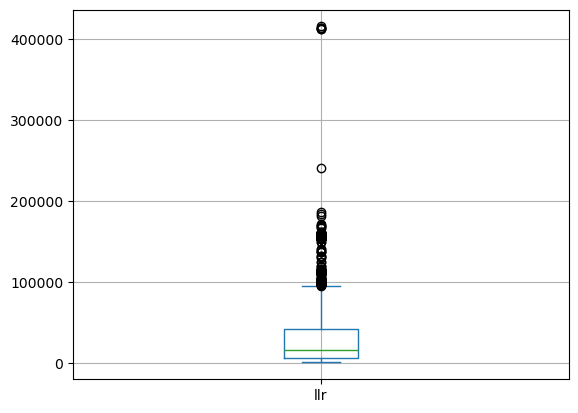

In [112]:
print( 
    features['llr'].plot.box(grid=True) 
)

In [113]:
print(features [ np.percentile(features['llr'], 80) <= features['llr'] ].sort_values(by='llr', ascending=False).to_markdown())

|      | ngram                          |   count | mot_1         | mot_2        | mot_3          | infos                                    |      llr |
|-----:|:-------------------------------|--------:|:--------------|:-------------|:---------------|:-----------------------------------------|---------:|
|  514 | although i think               |     146 | although      | i            | think          | ('although', 'i', 'think')               | 415854   |
| 1335 | though i think                 |      79 | though        | i            | think          | ('though', 'i', 'think')                 | 413776   |
| 2579 | reason i think                 |      50 | reason        | i            | think          | ('reason', 'i', 'think')                 | 413709   |
| 1514 | laugh i think                  |      73 | laugh         | i            | think          | ('laugh', 'i', 'think')                  | 413669   |
| 1916 | way i think                    |      61 | way           | i       

In [114]:
print( features [ np.percentile(features['llr'], 80) > features['llr'] ].drop('infos', axis=1).sort_values(by='llr', ascending=False).to_markdown() )

|      | ngram                              |   count | mot_1            | mot_2         | mot_3          |       llr |
|-----:|:-----------------------------------|--------:|:-----------------|:--------------|:---------------|----------:|
| 1123 | labor market outlook               |      90 | labor            | market        | outlook        | 48507.5   |
| 1603 | strong labor market                |      70 | strong           | labor         | market         | 48463.8   |
|   98 | federal reserve ’s                 |     384 | federal          | reserve       | ’s             | 48458.9   |
| 2354 | labor market will                  |      53 | labor            | market        | will           | 48428.4   |
|  468 | lot of things                      |     157 | lot              | of            | things         | 48391.9   |
|  158 | $ 400 million                      |     285 | $                | 400           | million        | 48385.8   |
| 2072 | may be getting                 

In [115]:
trigrams = features['ngram'].to_list()
trigrams

['federal funds rate',
 '1/ 2 percent',
 'think it ’s',
 'fed funds rate',
 'around the table',
 "think it 's",
 'think that ’s',
 'term interest rates',
 'real gdp growth',
 'period of time',
 "think that 's",
 'think we need',
 '’m not sure',
 'going to get',
 '25 basis points',
 "'m not sure",
 'rate of growth',
 'think we can',
 'let me just',
 'like to see',
 'm2 and m3',
 '50 basis points',
 'couple of years',
 'commercial real estate',
 'want to make',
 'core pce inflation',
 'since the last',
 'labor force participation',
 'think we ’re',
 'labor market conditions',
 'going to happen',
 'balance of risks',
 'around this table',
 'support alternative b',
 'think there ’s',
 'going to go',
 'rate of inflation',
 'real interest rates',
 'along the lines',
 'quite a bit',
 "think we 're",
 'open market operations',
 'unit labor costs',
 'since our last',
 'federal reserve bank',
 'point of view',
 'support your recommendation',
 '1 percentage point',
 'couple of months',
 '25 basis

## Bigrams

In [116]:
colloc_finder = BigramCollocationFinder.from_documents(tokenized_statements_mots)
features = pd.DataFrame.from_dict(colloc_finder.ngram_fd, orient='index').reset_index()
print(f"Nombre de bigrams total: {features.shape[0]}")
features.columns = ['infos', 'count']
features = features [ features['count'] >= 50 ]
features = features.sort_values(by='count', ascending=False)
features

Nombre de bigrams total: 1182017


,infos,count
104,"(in, the)",113355
234,"(of, the)",94699
331,"(., i)",75657
531,"(,, and)",71786
274,"(i, think)",61572
...,...,...
184653,"(and, recovery)",50
34639,"(last, part)",50
105401,"(obviously, has)",50
105574,"(try, .)",50


In [117]:
features['mot_1'] = features['infos'].apply(lambda x: x[0].split('#')[0])
features['mot_2'] = features['infos'].apply(lambda x: x[1].split('#')[0])
features['ngram'] = features.apply(lambda x: f"{x['mot_1']} {x['mot_2']}", axis=1)
features = features[['ngram', 'count', 'mot_1', 'mot_2', 'infos']]
features


,ngram,count,mot_1,mot_2,infos
104,in the,113355,in,the,"(in, the)"
234,of the,94699,of,the,"(of, the)"
331,. i,75657,.,i,"(., i)"
531,", and",71786,",",and,"(,, and)"
274,i think,61572,i,think,"(i, think)"
...,...,...,...,...,...
184653,and recovery,50,and,recovery,"(and, recovery)"
34639,last part,50,last,part,"(last, part)"
105401,obviously has,50,obviously,has,"(obviously, has)"
105574,try .,50,try,.,"(try, .)"


In [118]:
features = features[ (
    ~((features['mot_1'].isin(ponctuation)) | (features['mot_2'].isin(ponctuation)))
) & (
    ~((features['mot_1'].isin(stop_words_selected)) | (features['mot_2'].isin(stop_words_selected)))
) ]
features

,ngram,count,mot_1,mot_2,infos
322,mr. chairman,15831,mr.,chairman,"(mr., chairman)"
1023,funds rate,15542,funds,rate,"(funds, rate)"
5156,interest rates,10311,interest,rates,"(interest, rates)"
1401,monetary policy,10303,monetary,policy,"(monetary, policy)"
943,2 percent,8852,2,percent,"(2, percent)"
...,...,...,...,...,...
96556,treasury portfolio,50,treasury,portfolio,"(treasury, portfolio)"
186146,early august,50,early,august,"(early, august)"
180041,prices seem,50,prices,seem,"(prices, seem)"
64580,contacts noted,50,contacts,noted,"(contacts, noted)"


In [119]:
features.head(20)

,ngram,count,mot_1,mot_2,infos
322,mr. chairman,15831,mr.,chairman,"(mr., chairman)"
1023,funds rate,15542,funds,rate,"(funds, rate)"
5156,interest rates,10311,interest,rates,"(interest, rates)"
1401,monetary policy,10303,monetary,policy,"(monetary, policy)"
943,2 percent,8852,2,percent,"(2, percent)"
3157,federal funds,7262,federal,funds,"(federal, funds)"
15266,unemployment rate,6652,unemployment,rate,"(unemployment, rate)"
7238,labor market,5328,labor,market,"(labor, market)"
3772,next year,5122,next,year,"(next, year)"
2128,basis points,5077,basis,points,"(basis, points)"


In [120]:
# apply filter to colloc_finder

In [121]:
kept_bigrams = features['ngram'].to_list()
colloc_finder.apply_ngram_filter(lambda w1, w2: f"{w1} {w2}" not in kept_bigrams)

In [122]:
len(colloc_finder.score_ngrams(BigramAssocMeasures.raw_freq))

6304

In [123]:
likelihood_ratio = pd.DataFrame(colloc_finder.score_ngrams(BigramAssocMeasures.likelihood_ratio), columns=['infos', 'llr'])

In [124]:
likelihood_ratio

,infos,llr
0,"(mr., chairman)",199389.501018
1,"(funds, rate)",157992.883109
2,"(interest, rates)",112693.279219
3,"(monetary, policy)",110235.103900
4,"(federal, funds)",82449.941708
...,...,...
6299,"(’s, even)",0.071191
6300,"(’s, see)",0.064480
6301,"(rates, going)",0.058411
6302,"(now, going)",0.052315


In [125]:
features = features.merge(likelihood_ratio, on='infos')
features

,ngram,count,mot_1,mot_2,infos,llr
0,mr. chairman,15831,mr.,chairman,"(mr., chairman)",199389.501018
1,funds rate,15542,funds,rate,"(funds, rate)",157992.883109
2,interest rates,10311,interest,rates,"(interest, rates)",112693.279219
3,monetary policy,10303,monetary,policy,"(monetary, policy)",110235.103900
4,2 percent,8852,2,percent,"(2, percent)",80914.126672
...,...,...,...,...,...,...
6299,treasury portfolio,50,treasury,portfolio,"(treasury, portfolio)",321.738616
6300,early august,50,early,august,"(early, august)",336.372700
6301,prices seem,50,prices,seem,"(prices, seem)",105.515975
6302,contacts noted,50,contacts,noted,"(contacts, noted)",312.180414


In [126]:
# Ajouter les tests du chi2
def chi2_p_value(chi2_statistic):
    return 1 - stats.chi2.cdf(chi2_statistic, 1)

In [127]:
features['llr_pvalue'] = features['llr'].apply(chi2_p_value)
features

,ngram,count,mot_1,mot_2,infos,llr,llr_pvalue
0,mr. chairman,15831,mr.,chairman,"(mr., chairman)",199389.501018,0.000000e+00
1,funds rate,15542,funds,rate,"(funds, rate)",157992.883109,0.000000e+00
2,interest rates,10311,interest,rates,"(interest, rates)",112693.279219,0.000000e+00
3,monetary policy,10303,monetary,policy,"(monetary, policy)",110235.103900,0.000000e+00
4,2 percent,8852,2,percent,"(2, percent)",80914.126672,0.000000e+00
...,...,...,...,...,...,...,...
6299,treasury portfolio,50,treasury,portfolio,"(treasury, portfolio)",321.738616,0.000000e+00
6300,early august,50,early,august,"(early, august)",336.372700,0.000000e+00
6301,prices seem,50,prices,seem,"(prices, seem)",105.515975,0.000000e+00
6302,contacts noted,50,contacts,noted,"(contacts, noted)",312.180414,0.000000e+00


In [128]:
features.sort_values(by='llr', ascending=False).head(50)

,ngram,count,mot_1,mot_2,infos,llr,llr_pvalue
0,mr. chairman,15831,mr.,chairman,"(mr., chairman)",199389.501018,0.0
1,funds rate,15542,funds,rate,"(funds, rate)",157992.883109,0.0
2,interest rates,10311,interest,rates,"(interest, rates)",112693.279219,0.0
3,monetary policy,10303,monetary,policy,"(monetary, policy)",110235.103900,0.0
5,federal funds,7262,federal,funds,"(federal, funds)",82449.941708,0.0
4,2 percent,8852,2,percent,"(2, percent)",80914.126672,0.0
12,balance sheet,4488,balance,sheet,"(balance, sheet)",68123.114439,0.0
9,basis points,5077,basis,points,"(basis, points)",66480.912865,0.0
10,1/ 2,5004,1/,2,"(1/, 2)",65807.451003,0.0
6,unemployment rate,6652,unemployment,rate,"(unemployment, rate)",58356.278031,0.0


Axes(0.125,0.11;0.775x0.77)


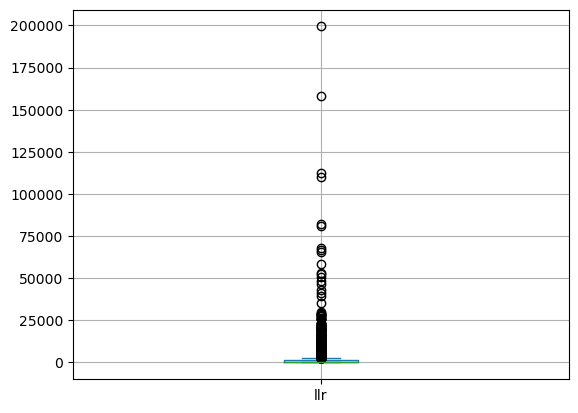

In [129]:
print( 
    features['llr'].plot.box(grid=True) 
)

In [132]:
trigrams

['federal funds rate',
 '1/ 2 percent',
 'think it ’s',
 'fed funds rate',
 'around the table',
 "think it 's",
 'think that ’s',
 'term interest rates',
 'real gdp growth',
 'period of time',
 "think that 's",
 'think we need',
 '’m not sure',
 'going to get',
 '25 basis points',
 "'m not sure",
 'rate of growth',
 'think we can',
 'let me just',
 'like to see',
 'm2 and m3',
 '50 basis points',
 'couple of years',
 'commercial real estate',
 'want to make',
 'core pce inflation',
 'since the last',
 'labor force participation',
 'think we ’re',
 'labor market conditions',
 'going to happen',
 'balance of risks',
 'around this table',
 'support alternative b',
 'think there ’s',
 'going to go',
 'rate of inflation',
 'real interest rates',
 'along the lines',
 'quite a bit',
 "think we 're",
 'open market operations',
 'unit labor costs',
 'since our last',
 'federal reserve bank',
 'point of view',
 'support your recommendation',
 '1 percentage point',
 'couple of months',
 '25 basis

In [137]:
print(features [ np.percentile(features['llr'], 75) <= features['llr'] ].sort_values(by='llr', ascending=False).to_markdown())

|      | ngram                       |   count | mot_1          | mot_2          | infos                              |       llr |   llr_pvalue |
|-----:|:----------------------------|--------:|:---------------|:---------------|:-----------------------------------|----------:|-------------:|
|    0 | mr. chairman                |   15831 | mr.            | chairman       | ('mr.', 'chairman')                | 199390    |            0 |
|    1 | funds rate                  |   15542 | funds          | rate           | ('funds', 'rate')                  | 157993    |            0 |
|    2 | interest rates              |   10311 | interest       | rates          | ('interest', 'rates')              | 112693    |            0 |
|    3 | monetary policy             |   10303 | monetary       | policy         | ('monetary', 'policy')             | 110235    |            0 |
|    5 | federal funds               |    7262 | federal        | funds          | ('federal', 'funds')               

In [136]:
print( features [ np.percentile(features['llr'], 75) > features['llr'] ].drop('infos', axis=1).sort_values(by='llr', ascending=False).to_markdown() )

|      | ngram                       |   count | mot_1           | mot_2          |           llr |   llr_pvalue |
|-----:|:----------------------------|--------:|:----------------|:---------------|--------------:|-------------:|
| 2587 | become increasingly         |     114 | become          | increasingly   | 1220          |  0           |
| 1420 | term yields                 |     187 | term            | yields         | 1219.81       |  0           |
|  487 | rate increase               |     419 | rate            | increase       | 1217.8        |  0           |
| 4220 | southern california         |      72 | southern        | california     | 1217.33       |  0           |
|  761 | ’re still                   |     301 | ’re             | still          | 1214.92       |  0           |
| 3669 | fed watchers                |      82 | fed             | watchers       | 1214.64       |  0           |
| 2953 | slight preference           |     101 | slight          | preference   

In [138]:
bigrams = features[ np.percentile(features['llr'], 75) <= features['llr'] ]['ngram'].to_list()
bigrams

['mr. chairman',
 'funds rate',
 'interest rates',
 'monetary policy',
 '2 percent',
 'federal funds',
 'unemployment rate',
 'labor market',
 'next year',
 'basis points',
 '1/ 2',
 'inflation expectations',
 'balance sheet',
 'n’t think',
 'alternative b',
 "n't think",
 'federal reserve',
 'last year',
 'interest rate',
 'percentage point',
 "n't know",
 'economic growth',
 'united states',
 'gdp growth',
 'madam chair',
 'financial markets',
 'fourth quarter',
 '’re going',
 'last meeting',
 'market participants',
 'fed funds',
 'right now',
 '4 percent',
 'going forward',
 '3 percent',
 'n’t know',
 'real gdp',
 'first quarter',
 'labor markets',
 'price stability',
 'core inflation',
 'even though',
 'intermeeting period',
 'little bit',
 'oil prices',
 'left panel',
 'economic activity',
 'second half',
 'committee ’s',
 'vice chairman',
 'something like',
 'financial conditions',
 'ca n’t',
 '5 percent',
 "'re going",
 'real estate',
 'discount rate',
 'second quarter',
 '’d li

## Fusion de termes et retrait des stopwords

In [143]:
tokenized_statements_mots_ngrams = []

In [146]:
from tqdm import tqdm

In [147]:
for i, st in tqdm(enumerate(tokenized_statements_mots)):
    st = ' '.join(st)
    for q in quadgrams:
        if q in st:
            st = st.replace(q, '_' + q.replace(' ', '_') + '_') # mettre des '_' et encadrer par des '#' pour ne pas que ce soit joint à un autre nrgam
            # print(i, q, st)
    for t in trigrams:
        if t in st:
            st = st.replace(t, '_' + t.replace(' ', '_') + '_') # mettre des '_' et encadrer par des '#' pour ne pas que ce soit joint à un autre nrgam
            # print(i, t, st)
    for b in bigrams:
        if b in st:
            st = st.replace(b, '_' + b.replace(' ', '_') + '_') # mettre des '_' et encadrer par des '#' pour ne pas que ce soit joint à un autre nrgam
            # print(i, b, st)
    tokenized_statements_mots_ngrams.append(st.split(' '))

142972it [09:08, 260.87it/s]


In [150]:
tokenized_statements_mots_ngrams[:4]

[['you', 'are', 'an', 'optimistic', 'man', '!', '_cathy_minehan_', '.'],
 ['so', 'moved', '.'],
 ['you', 'can', 'in', 'here', '.'],
 ['what',
  'bothers',
  'me',
  '--',
  'and',
  'i',
  'may',
  'see',
  'it',
  'totally',
  'incorrectly',
  '--',
  'is',
  'that',
  'a',
  'couple',
  'of',
  'our',
  'targets',
  'seem',
  'somewhat',
  'incompatible',
  ',',
  'just',
  'as',
  '_years_ago_',
  'our',
  '_interest_rate_',
  'targets',
  'were',
  'frequently',
  'incompatible',
  'with',
  'the',
  'aggregates',
  'targets',
  '.',
  "_one_ca_n't_",
  'steer',
  'with',
  'two',
  'compasses',
  'if',
  'those',
  'compasses',
  'are',
  "n't",
  'reconcilable',
  '.']]

In [151]:
tokenized_statements_mots_ngrams_cleaned = []

In [153]:
for statement in tqdm(tokenized_statements_mots_ngrams):
    temp = []
    for tok in statement:
        if tok in stop_words_selected or tok in ponctuation:
            continue
        else:
            temp.append(tok)
    tokenized_statements_mots_ngrams_cleaned.append(temp)

100%|██████████| 196963/196963 [00:34<00:00, 5718.42it/s]


In [154]:
tokenized_statements_mots_ngrams_cleaned[:4]

[['optimistic', 'man', '_cathy_minehan_'],
 ['moved'],
 ['can'],
 ['bothers',
  'may',
  'see',
  'totally',
  'incorrectly',
  'couple',
  'targets',
  'seem',
  'somewhat',
  'incompatible',
  'just',
  '_years_ago_',
  '_interest_rate_',
  'targets',
  'frequently',
  'incompatible',
  'aggregates',
  'targets',
  "_one_ca_n't_",
  'steer',
  'two',
  'compasses',
  'compasses',
  "n't",
  'reconcilable']]

## LDA

In [155]:
def identity_tokenizer(text):
    return text

In [156]:
n_top_words = 10

In [157]:
def plot_top_words(model, feature_names, n_components, n_top_words, title, filename):

    unique_values, counts = np.unique(np.argmax(model.components_, axis=0), return_counts=True)
    topics_ordered_by_most_tokens = list(pd.Series(data=counts, index=unique_values).sort_values(ascending=False).index)
    
    topics_words_distribution = model.components_ / model.components_.sum(axis=1)[:, np.newaxis]

    fig, axes = plt.subplots(n_components//5, 5, figsize=(50, 15*n_components//10), sharex=True)
    axes = axes.flatten()

    for idx, topic_idx in enumerate(topics_ordered_by_most_tokens):
        # topic = model.components_[topic_idx]
        # topic = ( model.components_ / model.components_.sum(axis=1)[:, np.newaxis] ) [topic_idx, :]
        topic = topics_words_distribution [topic_idx, :]
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = feature_names[top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx +1}", fontdict={"fontsize": 30})
        ax.tick_params(axis="both", which="major", labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()

    fig.savefig(filename)

In [158]:
# vectorizer = CountVectorizer(
#     tokenizer=identity_tokenizer, lowercase=False, # identity tokenization since we already did it
#     ngram_range=(1, 1)
# )    
# tf = vectorizer.fit_transform(tokenized_statements_mots_ngrams_cleaned)

/opt/conda/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
vectorizer = TfidfVectorizer(
    tokenizer=identity_tokenizer, lowercase=False, # identity tokenization since we already did it
    ngram_range=(1, 1),
)    
tfidf = vectorizer.fit_transform(tokenized_statements_mots_ngrams_cleaned)

In [159]:
features_count = tf.sum(axis=0).tolist()[0]
features_names = vectorizer.get_feature_names_out()
features = pd.DataFrame(
    zip(features_names, features_count), 
    columns=['feature', 'count']
).sort_values(by=['count'], ascending=False)
features

,feature,count
43692,think,159443
46954,will,103763
47662,’s,103079
32896,one,82871
46770,well,74073
...,...,...
13759,beneficence,1
13883,biding,1
14445,brash,1
14068,blockage,1


In [164]:
N_COMPONENTS = 10
# Fit the LDA model
print(
    "Fitting LDA models with tf features"
)
lda_10 = LatentDirichletAllocation(
    n_components=N_COMPONENTS,
    #doc_topic_prior=1/N_COMPONENTS, # adding 1 fake word
    #topic_word_prior=1/N_COMPONENTS, # adding 
    learning_method="online",
    max_iter=100,
    evaluate_every=1,
    verbose=True,
    random_state=118712
)
t0 = time()
lda_10.fit(tf)
print("done in %0.3fs." % (time() - t0))

Fitting LDA models with tf features
iteration: 1 of max_iter: 100, perplexity: 3687.4230
iteration: 2 of max_iter: 100, perplexity: 3644.9198
iteration: 3 of max_iter: 100, perplexity: 3634.0176
iteration: 4 of max_iter: 100, perplexity: 3629.3935
iteration: 5 of max_iter: 100, perplexity: 3626.8616
iteration: 6 of max_iter: 100, perplexity: 3625.2827
iteration: 7 of max_iter: 100, perplexity: 3624.2416
iteration: 8 of max_iter: 100, perplexity: 3623.4943
iteration: 9 of max_iter: 100, perplexity: 3622.9312
iteration: 10 of max_iter: 100, perplexity: 3622.4953
iteration: 11 of max_iter: 100, perplexity: 3622.1437
iteration: 12 of max_iter: 100, perplexity: 3621.9064
iteration: 13 of max_iter: 100, perplexity: 3621.6800
iteration: 14 of max_iter: 100, perplexity: 3621.4929
iteration: 15 of max_iter: 100, perplexity: 3621.3200
iteration: 16 of max_iter: 100, perplexity: 3621.1890
iteration: 17 of max_iter: 100, perplexity: 3621.0593
iteration: 18 of max_iter: 100, perplexity: 3620.9705
d

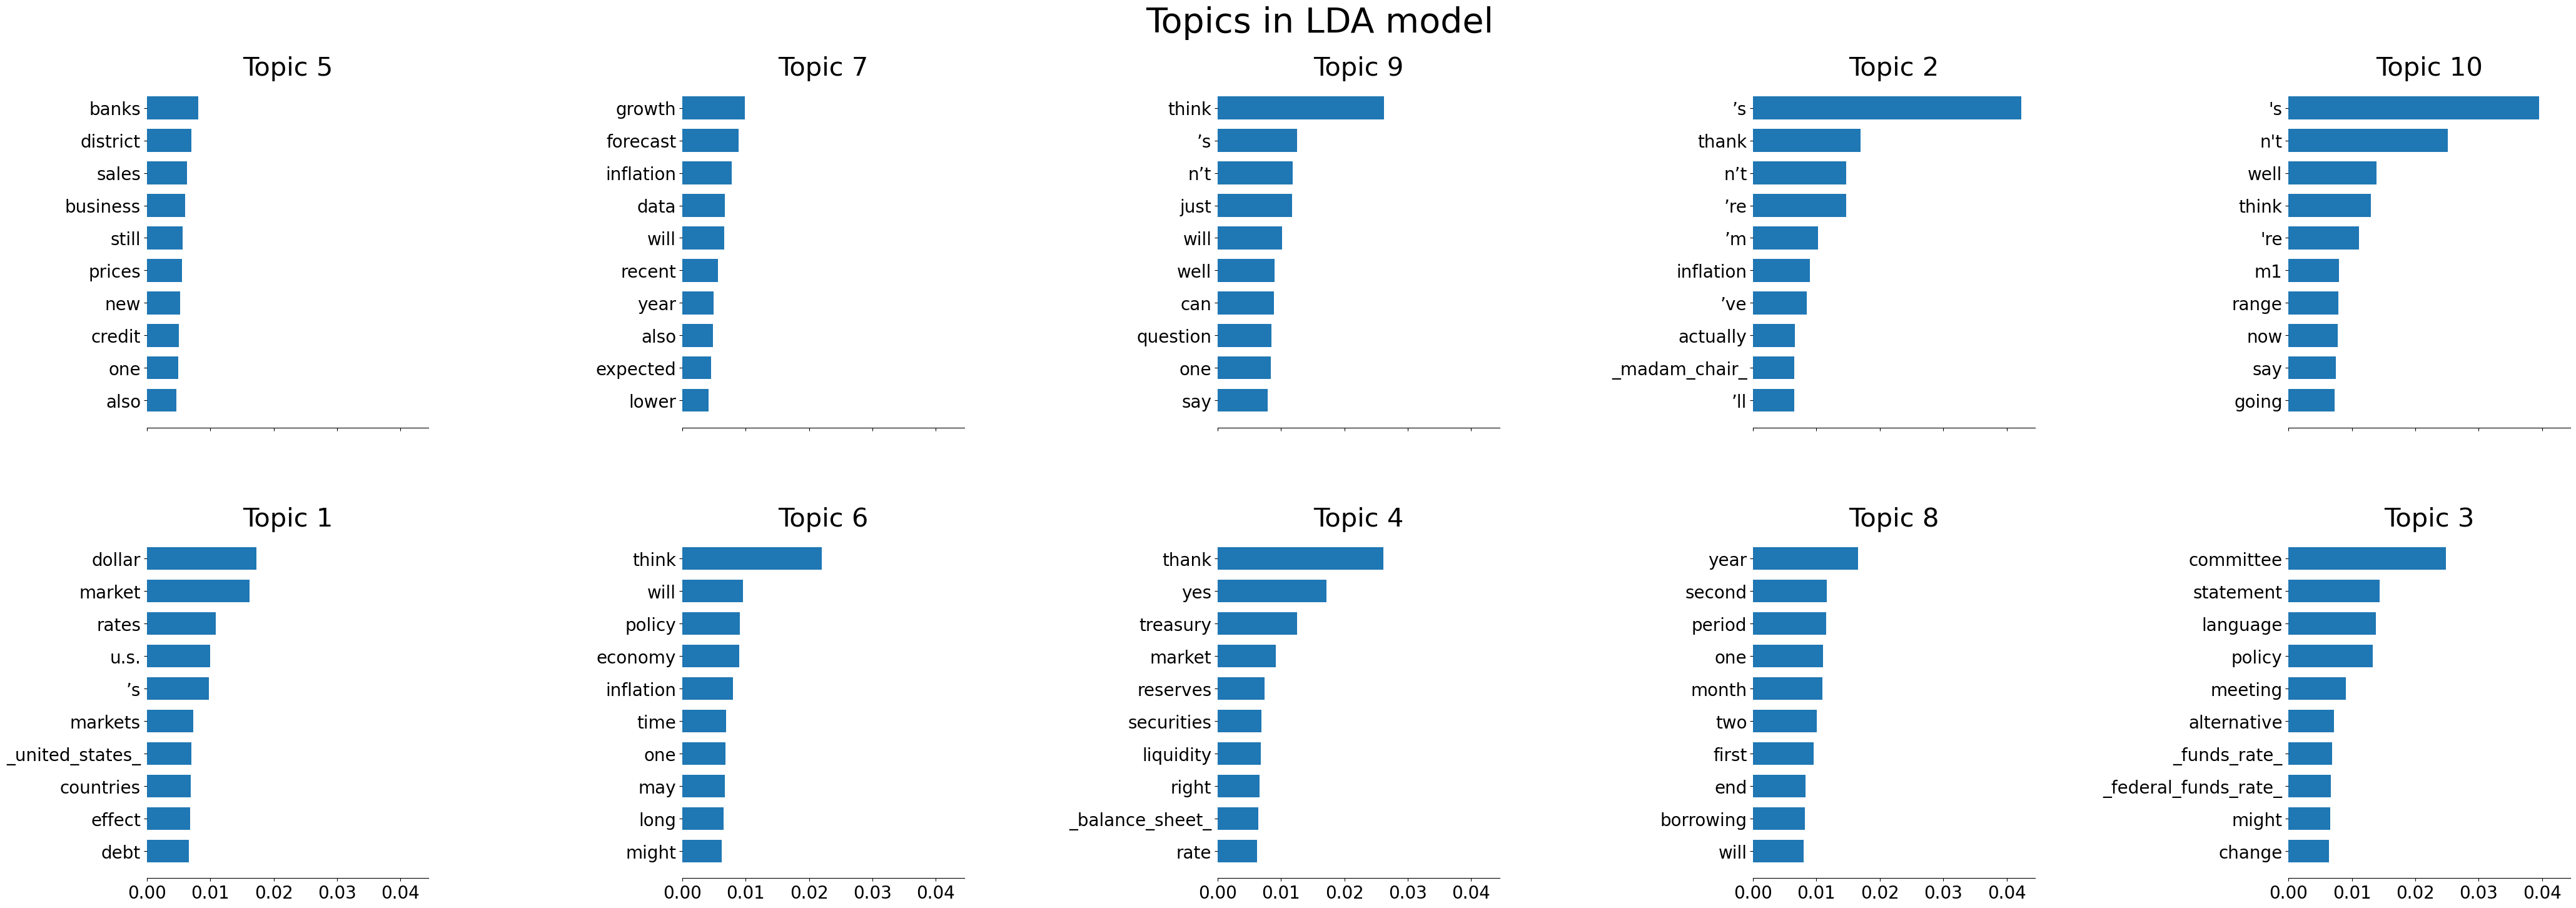

In [167]:
plot_top_words(lda_10, features_names, N_COMPONENTS, n_top_words, "Topics in LDA model", 'lda_results/lda_10.png')

In [172]:
print(features['feature'].head(100).to_list())

['think', 'will', '’s', 'one', 'well', 'now', "'s", 'may', 'just', 'also', 'inflation', 'time', 'thank', 'much', 'can', 'n’t', 'point', 'economy', 'market', 'going', 'policy', 'year', 'might', '_mr._chairman_', "n't", 'say', 'growth', 'forecast', 'still', 'even', 'way', 'see', 'committee', 'us', 'first', 'get', 'rate', 'really', 'question', 'view', 'long', '’re', 'seems', 'little', 'right', 'change', 'people', 'terms', 'said', 'data', 'like', 'two', 'term', 'make', 'risk', 'increase', 'lower', 'move', 'markets', 'high', 'rates', 'meeting', 'second', 'quite', 'period', 'fact', 'something', 'good', 'yes', 'least', 'look', 'take', 'part', 'go', 'effect', 'likely', 'higher', 'probably', 'back', 'whether', 'sense', 'prices', 'rather', 'know', 'given', 'staff', 'side', 'believe', 'many', 'number', 'come', 'actually', 'new', 'course', 'today', '’m', 'less', 'strong', 'range', 'low']


In [173]:
stop_supp = ['think', 'will', '’s', 'one', 'well', 'now', "'s", 'may', 'just', 'also', 'can', 'n’t', 'going', 'might', "n't", 'say', 'still', 'even', 'way', 'see', 'us', 'first', 'get', 'really', 'seems']


In [176]:
filtered_voc = features [ (features['count'] >= 50) & ~(features['feature'].isin(stop_supp)) ]['feature'].to_list()
filtered_voc[:3]

['inflation', 'time', 'thank']

In [177]:
# vectorizer = CountVectorizer(
#     tokenizer=identity_tokenizer, lowercase=False, # identity tokenization since we already did it
#     ngram_range=(1, 1),
#     vocabulary=filtered_voc
# )    
# tf = vectorizer.fit_transform(tokenized_statements_mots_ngrams_cleaned)

/opt/conda/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
vectorizer = TfidfVectorizer(
    tokenizer=identity_tokenizer, lowercase=False, # identity tokenization since we already did it
    ngram_range=(1, 1),
    vocabulary=filtered_voc
)    
tfidf = vectorizer.fit_transform(tokenized_statements_mots_ngrams_cleaned)

In [178]:
features_count = tf.sum(axis=0).tolist()[0]
features_names = vectorizer.get_feature_names_out()
features = pd.DataFrame(
    zip(features_names, features_count), 
    columns=['feature', 'count']
).sort_values(by=['count'], ascending=False)
features

,feature,count
0,inflation,60431
1,time,58079
2,thank,54903
3,much,52273
4,point,48610
...,...,...
15847,25th,50
15848,futile,50
15849,mill,50
15850,detract,50


In [179]:
N_COMPONENTS = 10
# Fit the LDA model
print(
    "Fitting LDA models with tf features"
)
lda_10_filtered = LatentDirichletAllocation(
    n_components=N_COMPONENTS,
    #doc_topic_prior=1/N_COMPONENTS, # adding 1 fake word
    #topic_word_prior=1/N_COMPONENTS, # adding 
    learning_method="online",
    max_iter=100,
    evaluate_every=1,
    verbose=True,
    random_state=118712
)
t0 = time()
lda_10_filtered.fit(tf)
print("done in %0.3fs." % (time() - t0))

Fitting LDA models with tf features
iteration: 1 of max_iter: 100, perplexity: 3732.0883
iteration: 2 of max_iter: 100, perplexity: 3715.5942
iteration: 3 of max_iter: 100, perplexity: 3710.3578
iteration: 4 of max_iter: 100, perplexity: 3707.8580
iteration: 5 of max_iter: 100, perplexity: 3706.3899
iteration: 6 of max_iter: 100, perplexity: 3705.4365
iteration: 7 of max_iter: 100, perplexity: 3704.7570
iteration: 8 of max_iter: 100, perplexity: 3704.2349
iteration: 9 of max_iter: 100, perplexity: 3703.8346
iteration: 10 of max_iter: 100, perplexity: 3703.5075
iteration: 11 of max_iter: 100, perplexity: 3703.2543
iteration: 12 of max_iter: 100, perplexity: 3703.0504
iteration: 13 of max_iter: 100, perplexity: 3702.8819
iteration: 14 of max_iter: 100, perplexity: 3702.7564
iteration: 15 of max_iter: 100, perplexity: 3702.6249
iteration: 16 of max_iter: 100, perplexity: 3702.5048
iteration: 17 of max_iter: 100, perplexity: 3702.4040
iteration: 18 of max_iter: 100, perplexity: 3702.3049
d

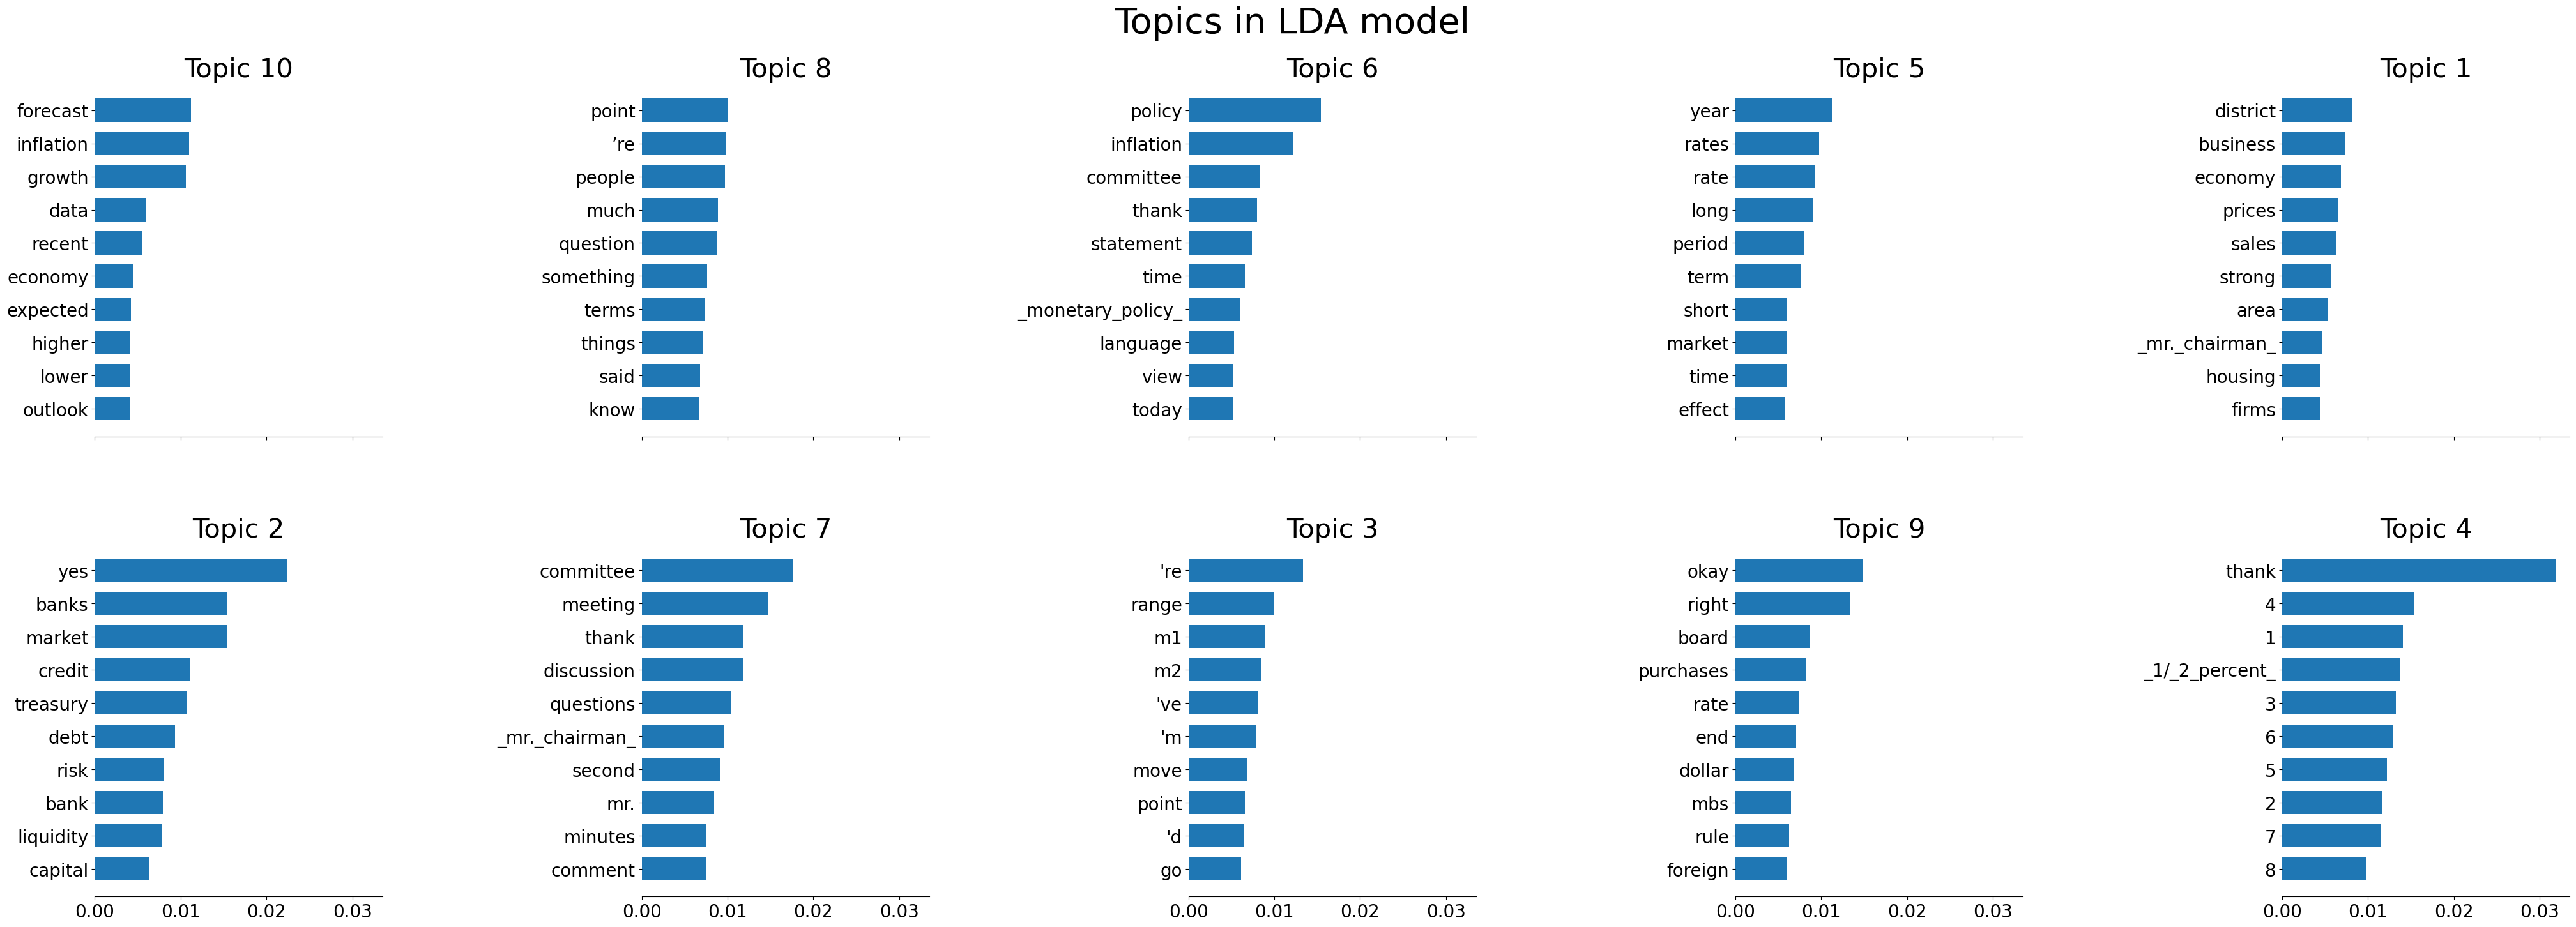

In [180]:
plot_top_words(lda_10_filtered, features_names, N_COMPONENTS, n_top_words, "Topics in LDA model", 'lda_results/lda_10_filtered.png')

In [181]:
N_COMPONENTS = 20
# Fit the LDA model
print(
    "Fitting LDA models with tf features"
)
lda_20_filtered = LatentDirichletAllocation(
    n_components=N_COMPONENTS,
    #doc_topic_prior=1/N_COMPONENTS, # adding 1 fake word
    #topic_word_prior=1/N_COMPONENTS, # adding 
    learning_method="online",
    max_iter=100,
    evaluate_every=1,
    verbose=True,
    random_state=118712
)
t0 = time()
lda_20_filtered.fit(tf)
print("done in %0.3fs." % (time() - t0))

Fitting LDA models with tf features
iteration: 1 of max_iter: 100, perplexity: 3928.8508
iteration: 2 of max_iter: 100, perplexity: 3900.7235
iteration: 3 of max_iter: 100, perplexity: 3891.3204
iteration: 4 of max_iter: 100, perplexity: 3886.4202
iteration: 5 of max_iter: 100, perplexity: 3884.0736
iteration: 6 of max_iter: 100, perplexity: 3882.5358
iteration: 7 of max_iter: 100, perplexity: 3881.6196
iteration: 8 of max_iter: 100, perplexity: 3880.8665
iteration: 9 of max_iter: 100, perplexity: 3880.4001
iteration: 10 of max_iter: 100, perplexity: 3879.9425
iteration: 11 of max_iter: 100, perplexity: 3879.6082
iteration: 12 of max_iter: 100, perplexity: 3879.2880
iteration: 13 of max_iter: 100, perplexity: 3879.0877
iteration: 14 of max_iter: 100, perplexity: 3878.9058
iteration: 15 of max_iter: 100, perplexity: 3878.7723
iteration: 16 of max_iter: 100, perplexity: 3878.6342
iteration: 17 of max_iter: 100, perplexity: 3878.4917
iteration: 18 of max_iter: 100, perplexity: 3878.4032
d

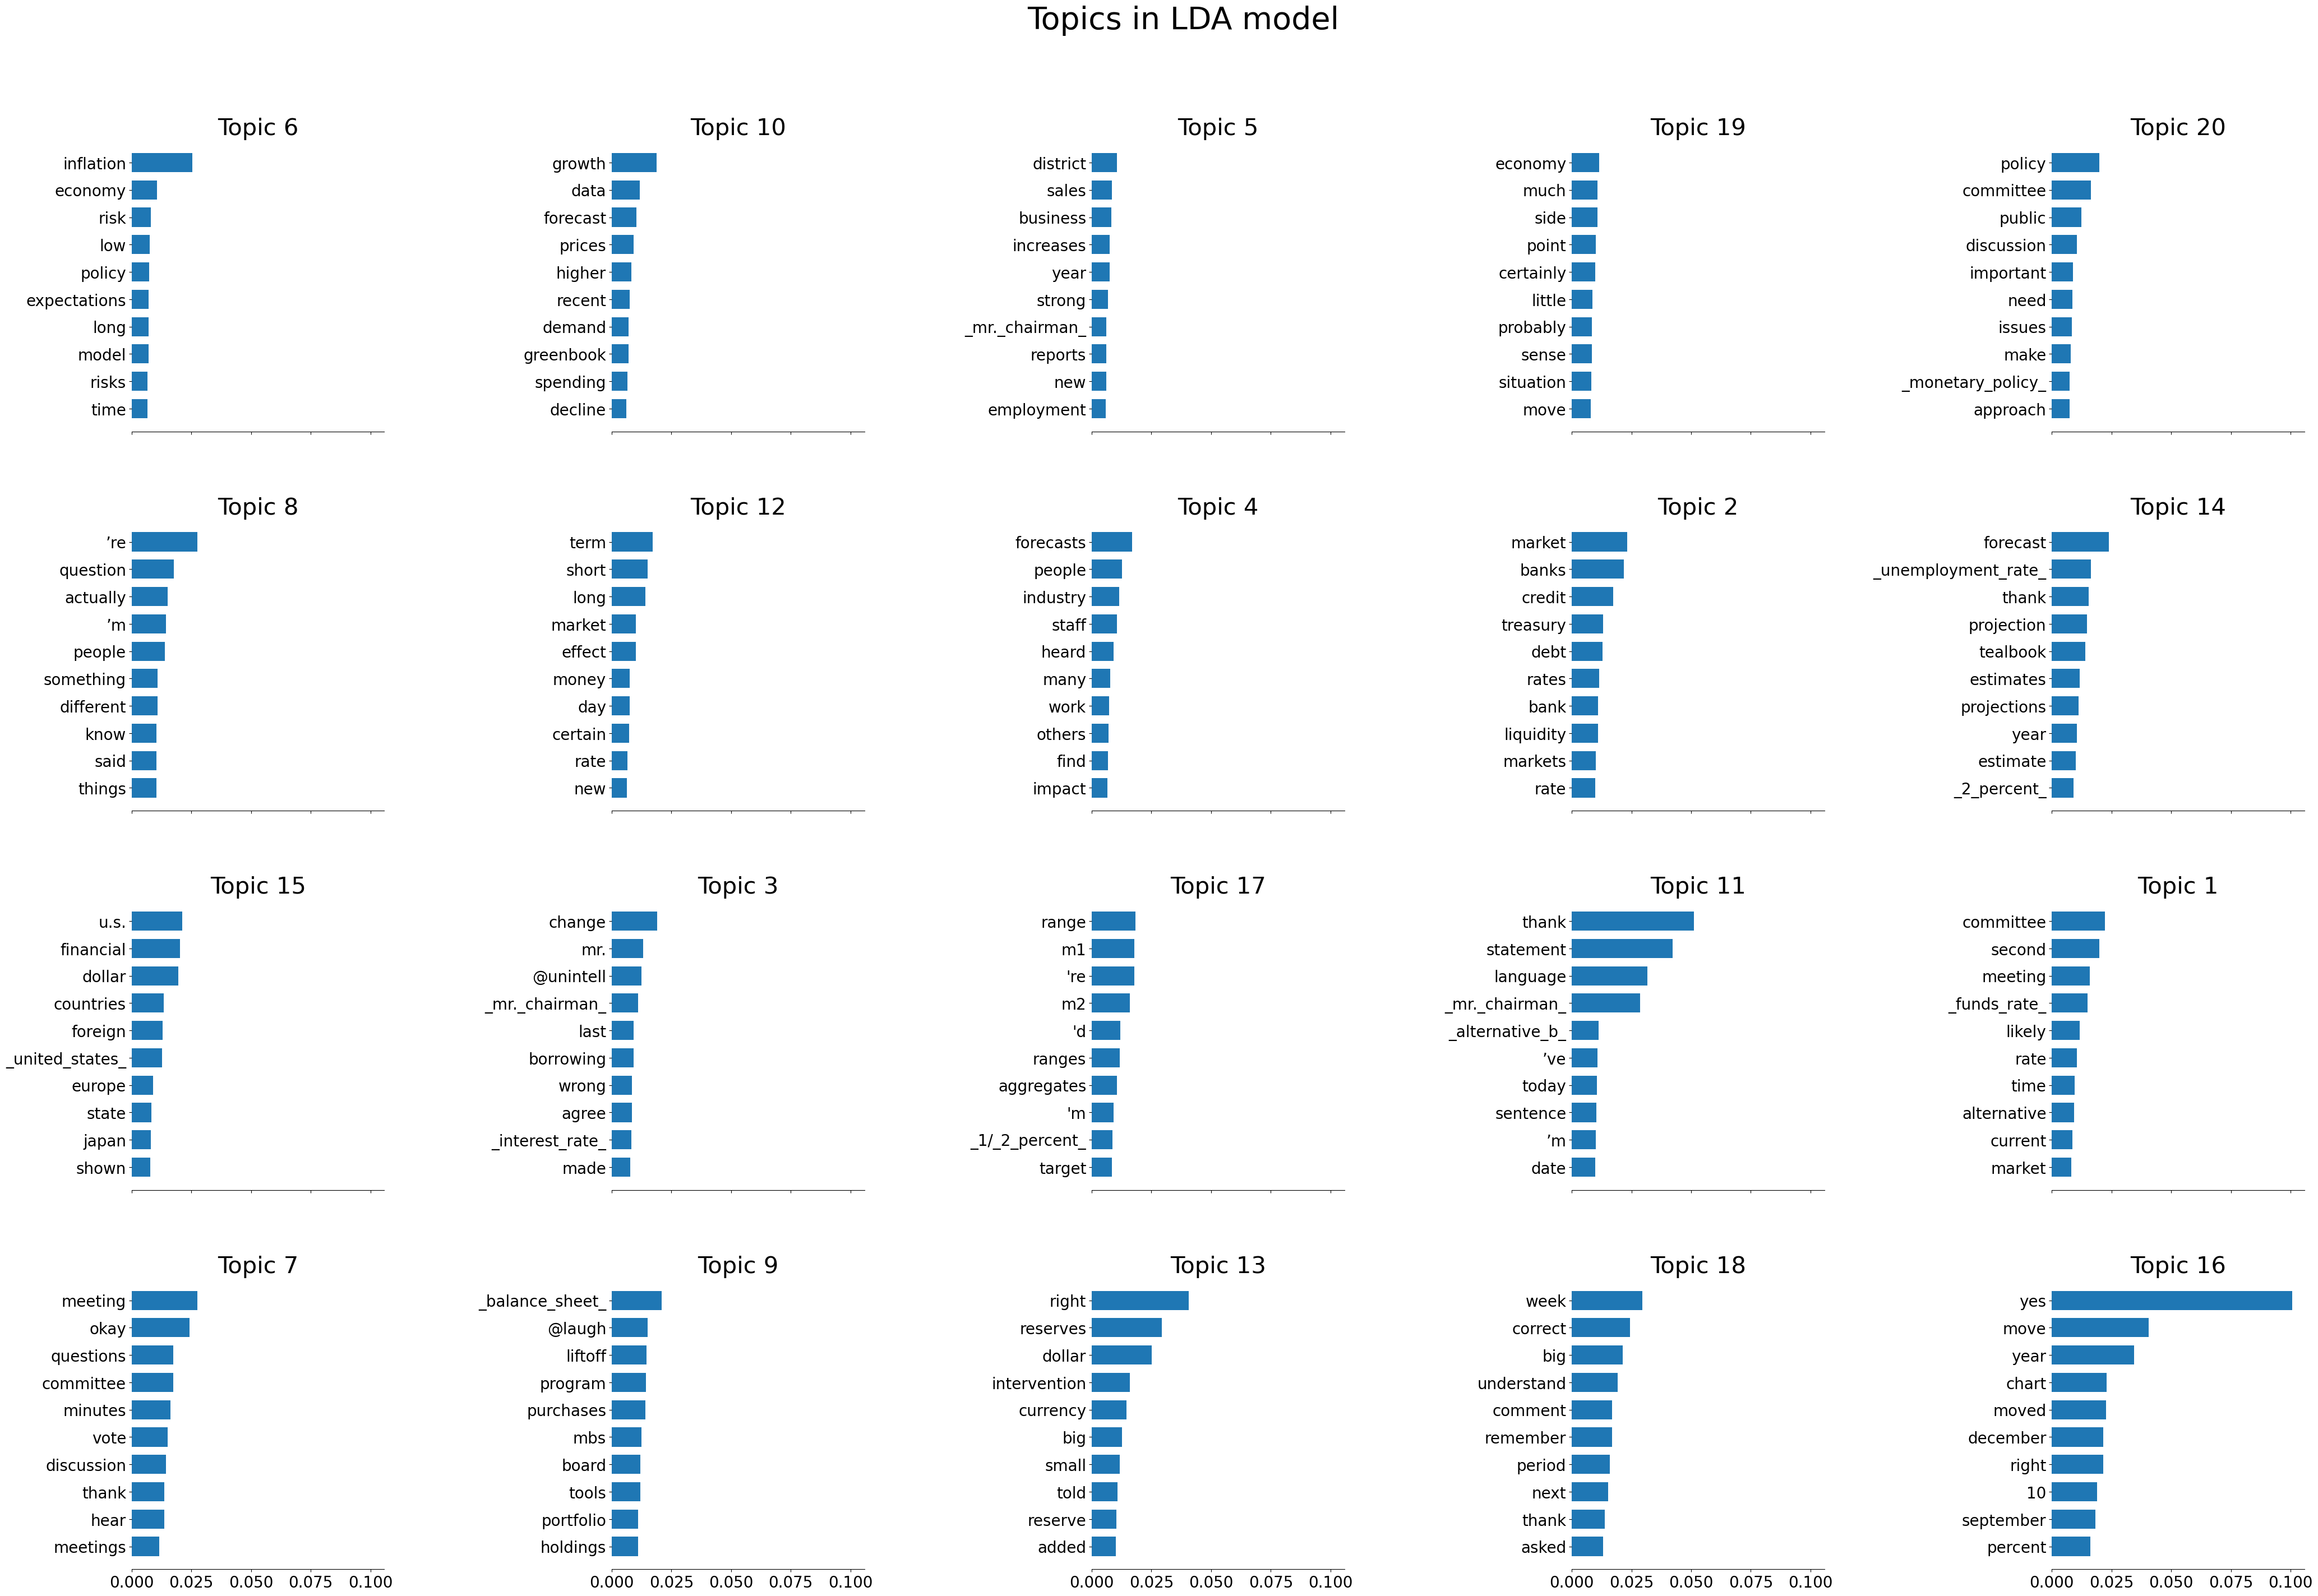

In [182]:
plot_top_words(lda_20_filtered, features_names, N_COMPONENTS, n_top_words, "Topics in LDA model", 'lda_results/lda_20_filtered.png')

In [183]:
N_COMPONENTS = 40
# Fit the LDA model
print(
    "Fitting LDA models with tf features"
)
lda_40_filtered = LatentDirichletAllocation(
    n_components=N_COMPONENTS,
    #doc_topic_prior=1/N_COMPONENTS, # adding 1 fake word
    #topic_word_prior=1/N_COMPONENTS, # adding 
    learning_method="online",
    max_iter=100,
    evaluate_every=1,
    verbose=True,
    random_state=118712
)
t0 = time()
lda_40_filtered.fit(tf)
print("done in %0.3fs." % (time() - t0))

Fitting LDA models with tf features
iteration: 1 of max_iter: 100, perplexity: 6447.0117
iteration: 2 of max_iter: 100, perplexity: 6399.8751
iteration: 3 of max_iter: 100, perplexity: 6385.6027
iteration: 4 of max_iter: 100, perplexity: 6377.3902
iteration: 5 of max_iter: 100, perplexity: 6372.5453
iteration: 6 of max_iter: 100, perplexity: 6369.4755
iteration: 7 of max_iter: 100, perplexity: 6367.3781
iteration: 8 of max_iter: 100, perplexity: 6365.7962
iteration: 9 of max_iter: 100, perplexity: 6364.6852
iteration: 10 of max_iter: 100, perplexity: 6363.9718
iteration: 11 of max_iter: 100, perplexity: 6363.2865
iteration: 12 of max_iter: 100, perplexity: 6362.8291
iteration: 13 of max_iter: 100, perplexity: 6362.3174
iteration: 14 of max_iter: 100, perplexity: 6361.8140
iteration: 15 of max_iter: 100, perplexity: 6361.6284
iteration: 16 of max_iter: 100, perplexity: 6361.0782
iteration: 17 of max_iter: 100, perplexity: 6360.8786
iteration: 18 of max_iter: 100, perplexity: 6360.4758
i

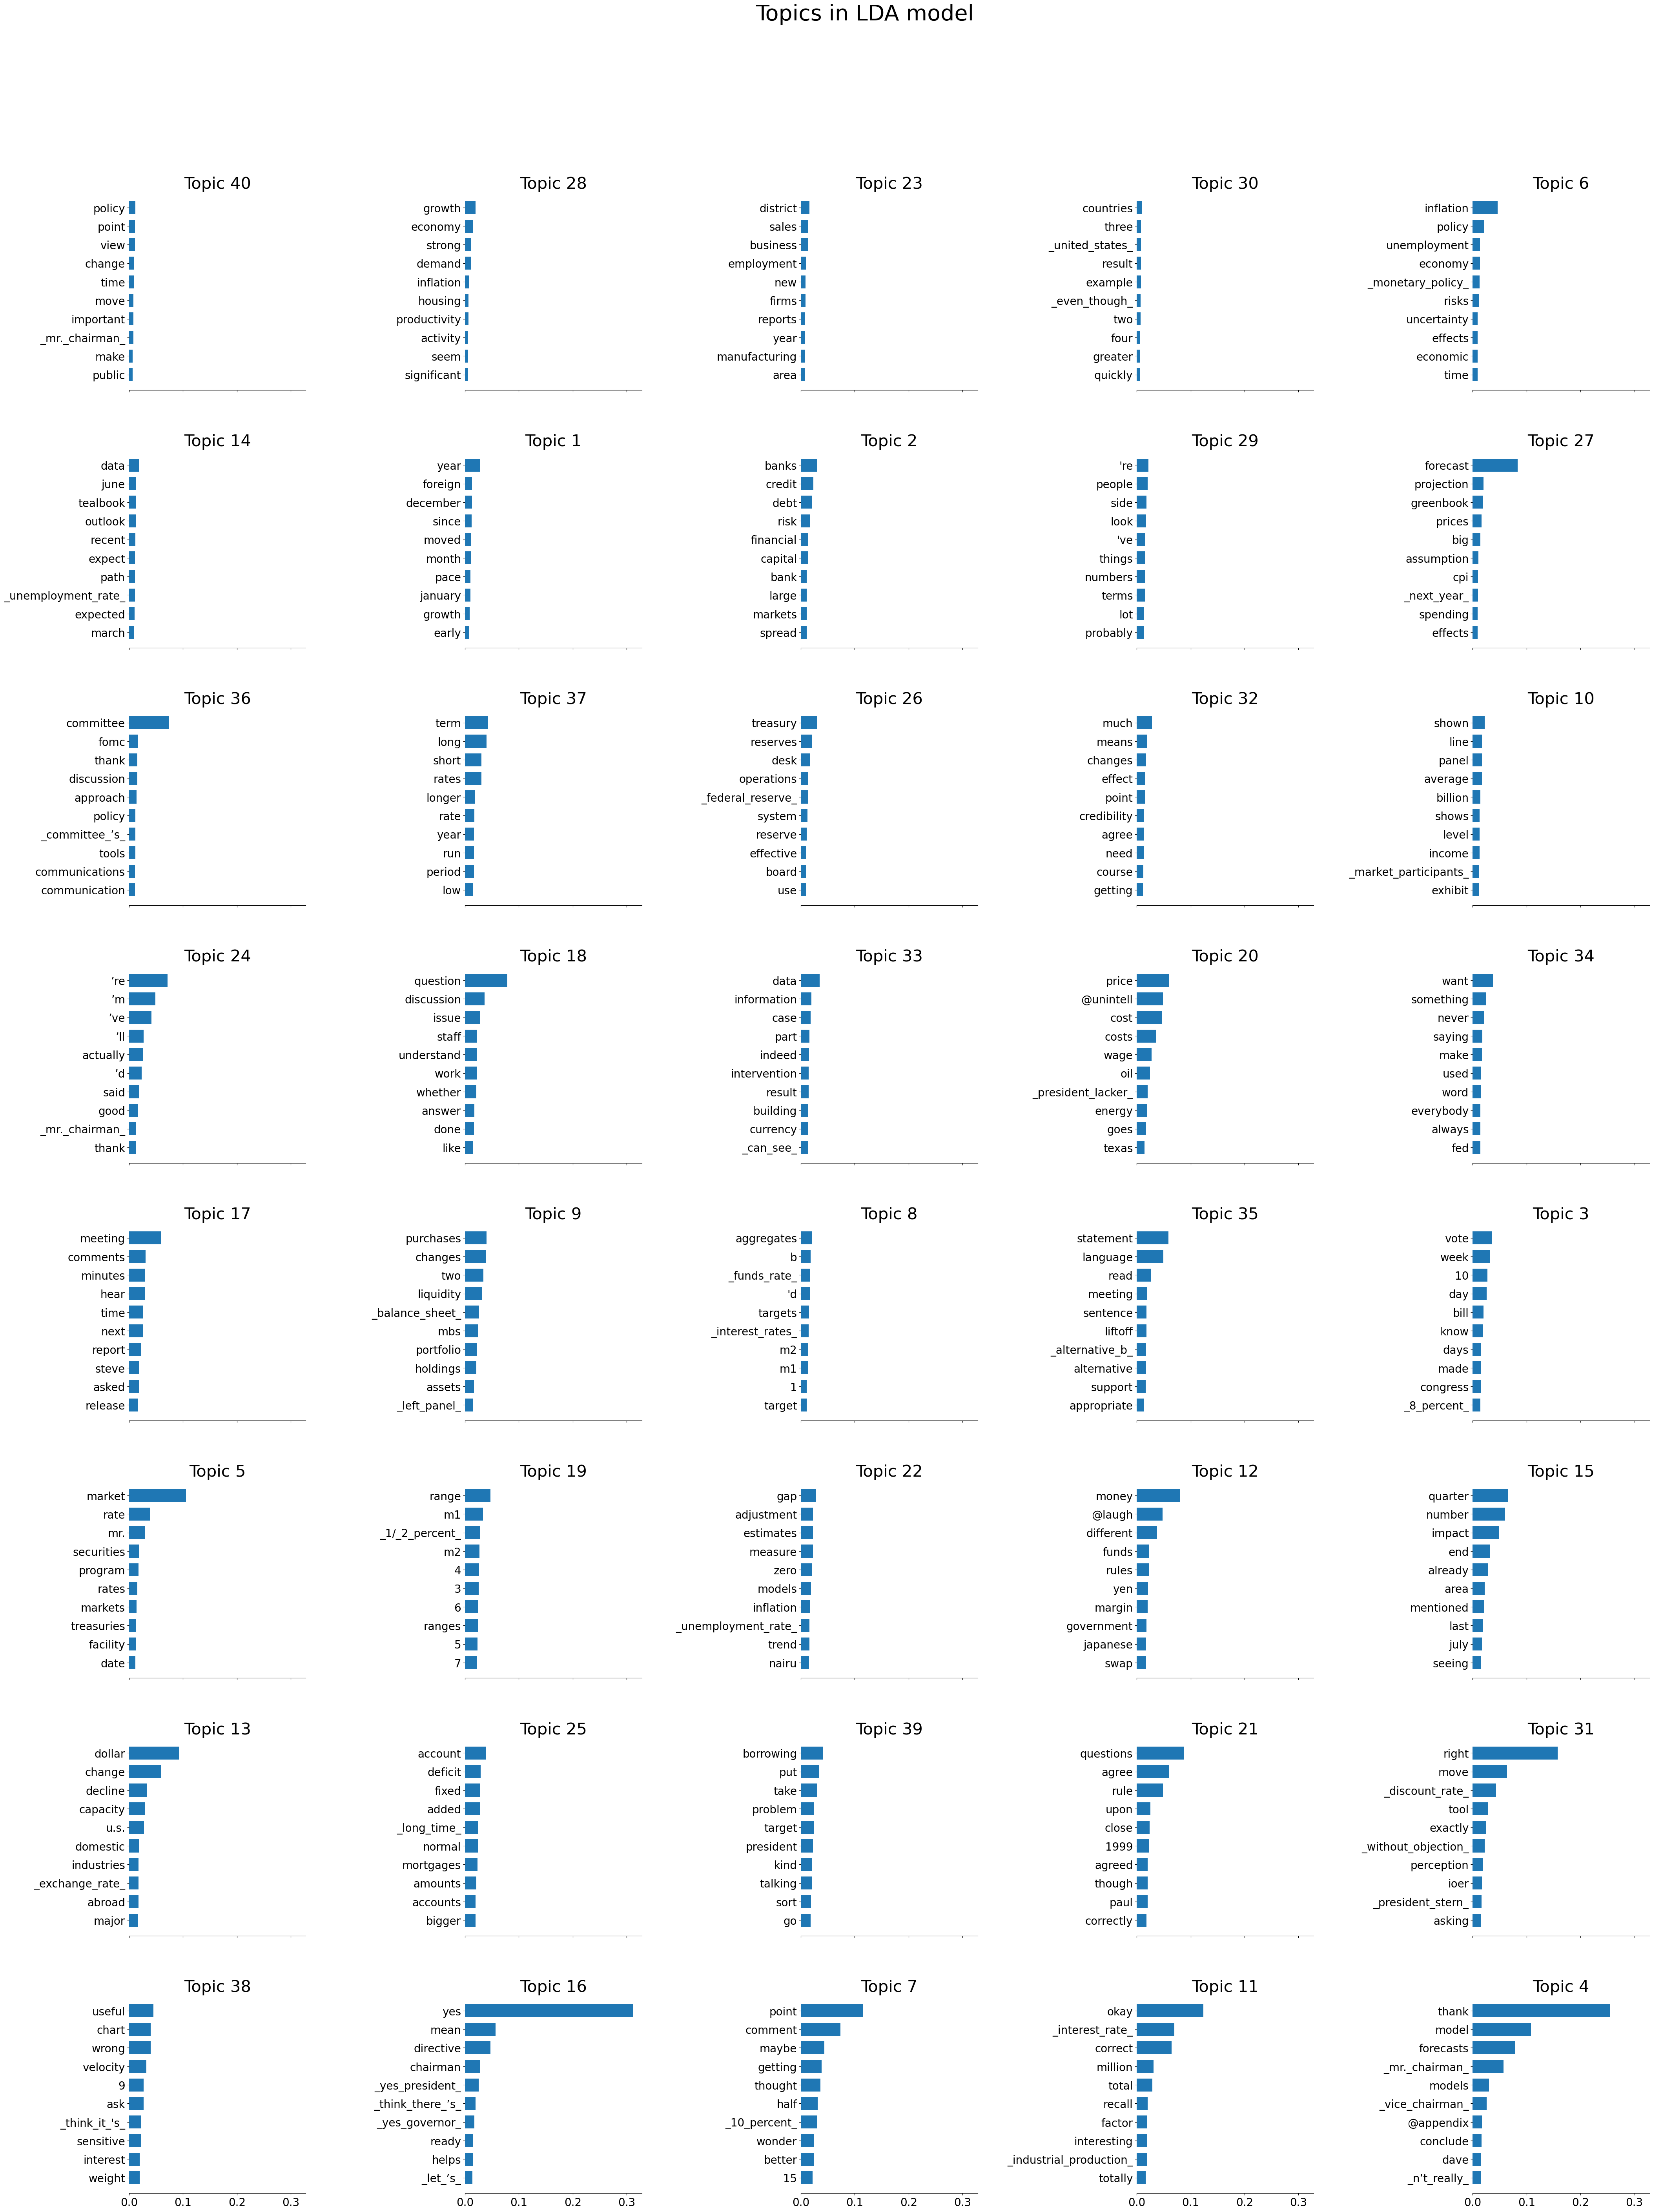

In [184]:
plot_top_words(lda_40_filtered, features_names, N_COMPONENTS, n_top_words, "Topics in LDA model", 'lda_results/lda_40_filtered.png')

# Lemmas

## Ngrams

### Quadgrams

In [22]:
colloc_finder = QuadgramCollocationFinder.from_documents(tokenized_statements_lemmas)
features = pd.DataFrame.from_dict(colloc_finder.ngram_fd, orient='index').reset_index()
print(f"Nombre de quadgrams total: {features.shape[0]}")
features.columns = ['infos', 'count']
features = features [ features['count'] >= 50 ]
features = features.sort_values(by='count', ascending=False)
features

Nombre de quadgrams total: 13377858


,infos,count
24,"(federal, reserve, bank, of)",13329
3068,"(of, the, federal, reserve)",11487
4943,"(the, federal, reserve, system)",8917
156,"(., for, example, ,)",7886
3183,"(in, the, united, state)",7776
...,...,...
969526,"(to, carry, out, the)",50
485867,"(a, short, period, of)",50
1212818,"(law, and, regulation, ,)",50
1211406,"(like, the, federal, reserve)",50


In [23]:
features['lemma_1'] = features['infos'].apply(lambda x: x[0].split('#')[0])
features['lemma_2'] = features['infos'].apply(lambda x: x[1].split('#')[0])
features['lemma_3'] = features['infos'].apply(lambda x: x[2].split('#')[0])
features['lemma_4'] = features['infos'].apply(lambda x: x[3].split('#')[0])
features['ngram'] = features.apply(lambda x: f"{x['lemma_1']} {x['lemma_2']} {x['lemma_3']} {x['lemma_4']}", axis=1)
features = features[['ngram', 'count', 'lemma_1', 'lemma_2', 'lemma_3', 'lemma_4', 'infos']]
features


,ngram,count,lemma_1,lemma_2,lemma_3,lemma_4,infos
24,federal reserve bank of,13329,federal,reserve,bank,of,"(federal, reserve, bank, of)"
3068,of the federal reserve,11487,of,the,federal,reserve,"(of, the, federal, reserve)"
4943,the federal reserve system,8917,the,federal,reserve,system,"(the, federal, reserve, system)"
156,". for example ,",7886,.,for,example,",","(., for, example, ,)"
3183,in the united state,7776,in,the,united,state,"(in, the, united, state)"
...,...,...,...,...,...,...,...
969526,to carry out the,50,to,carry,out,the,"(to, carry, out, the)"
485867,a short period of,50,a,short,period,of,"(a, short, period, of)"
1212818,"law and regulation ,",50,law,and,regulation,",","(law, and, regulation, ,)"
1211406,like the federal reserve,50,like,the,federal,reserve,"(like, the, federal, reserve)"


In [25]:
# Ponctuation ?
sorted(list(set(list(''.join(features['ngram'].to_list())))))


[' ',
 '!',
 '"',
 '%',
 '&',
 "'",
 '(',
 ')',
 '*',
 ',',
 '-',
 '.',
 '0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 ':',
 ';',
 '?',
 '[',
 '\\',
 ']',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 '—']

In [13]:
ponctuation = [' ',
 '!',
 '"',
 '%',
 '&',
 "'",
 '(',
 ')',
 '*',
 ',',
 '-',
 '.',
 ':',
 ';',
 '?',
 '[',
 '\\',
 ']',
 '—']

In [25]:
features = features[ (
    ~((features['lemma_1'].isin(ponctuation)) | (features['lemma_2'].isin(ponctuation)) | (features['lemma_3'].isin(ponctuation)) | (features['lemma_4'].isin(ponctuation)))
) & (
    ~((features['lemma_1'].isin(stop_words_selected)) | (features['lemma_4'].isin(stop_words_selected)))
) ]
features

,ngram,count,lemma_1,lemma_2,lemma_3,lemma_4,infos
1952,federal open market committee,5060,federal,open,market,committee,"(federal, open, market, committee)"
5069,governors of the federal,4276,governors,of,the,federal,"(governors, of, the, federal)"
13421,bis central banker speech,3537,bis,central,banker,speech,"(bis, central, banker, speech)"
2778,reserve bank of st.,3242,reserve,bank,of,st.,"(reserve, bank, of, st.)"
2779,bank of st. louis,3231,bank,of,st.,louis,"(bank, of, st., louis)"
...,...,...,...,...,...,...,...
63000,policy in a way,50,policy,in,a,way,"(policy, in, a, way)"
837192,remark by esther l.,50,remark,by,esther,l.,"(remark, by, esther, l.)"
240022,bank and other depository,50,bank,and,other,depository,"(bank, and, other, depository)"
70361,racial and ethnic group,50,racial,and,ethnic,group,"(racial, and, ethnic, group)"


In [26]:
features.head(20)

,ngram,count,lemma_1,lemma_2,lemma_3,lemma_4,infos
1952,federal open market committee,5060,federal,open,market,committee,"(federal, open, market, committee)"
5069,governors of the federal,4276,governors,of,the,federal,"(governors, of, the, federal)"
13421,bis central banker speech,3537,bis,central,banker,speech,"(bis, central, banker, speech)"
2778,reserve bank of st.,3242,reserve,bank,of,st.,"(reserve, bank, of, st.)"
2779,bank of st. louis,3231,bank,of,st.,louis,"(bank, of, st., louis)"
23895,digitized for fraser federal,2449,digitized,for,fraser,federal,"(digitized, for, fraser, federal)"
23897,fraser federal reserve bank,2448,fraser,federal,reserve,bank,"(fraser, federal, reserve, bank)"
23454,reserve bank of new,2413,reserve,bank,of,new,"(reserve, bank, of, new)"
23455,bank of new york,2302,bank,of,new,york,"(bank, of, new, york)"
29225,president and chief executive,1341,president,and,chief,executive,"(president, and, chief, executive)"


In [44]:
# apply filter to colloc_finder

In [37]:
kept_quadgrams = features['ngram'].to_list()
colloc_finder.apply_ngram_filter(lambda w1, w2, w3, w4: f"{w1} {w2} {w3} {w4}" not in kept_quadgrams)

In [38]:
len(colloc_finder.score_ngrams(QuadgramAssocMeasures.raw_freq))

2099

In [39]:
likelihood_ratio = pd.DataFrame(colloc_finder.score_ngrams(QuadgramAssocMeasures.likelihood_ratio), columns=['infos', 'llr'])

In [40]:
likelihood_ratio

,infos,llr
0,"(federal, reserve, monetary, policy)",1.097359e+06
1,"(give, the, federal, reserve)",9.223947e+05
2,"(within, the, federal, reserve)",9.222524e+05
3,"(throughout, the, federal, reserve)",9.213029e+05
4,"(across, the, federal, reserve)",9.207033e+05
...,...,...
2094,"(2012, 2013, 2014, 2015)",2.568021e+03
2095,"(6, 4, 2, 0)",2.526959e+03
2096,"(2008, 2009, 2010, 2011)",2.494720e+03
2097,"(net, stable, funding, ratio)",2.435783e+03


In [41]:
features = features.merge(likelihood_ratio, on='infos')
features

,ngram,count,lemma_1,lemma_2,lemma_3,lemma_4,infos,llr
0,federal open market committee,5060,federal,open,market,committee,"(federal, open, market, committee)",186996.468937
1,governors of the federal,4276,governors,of,the,federal,"(governors, of, the, federal)",570250.859642
2,bis central banker speech,3537,bis,central,banker,speech,"(bis, central, banker, speech)",209164.722247
3,reserve bank of st.,3242,reserve,bank,of,st.,"(reserve, bank, of, st.)",222496.385751
4,bank of st. louis,3231,bank,of,st.,louis,"(bank, of, st., louis)",157497.579460
...,...,...,...,...,...,...,...,...
2094,policy in a way,50,policy,in,a,way,"(policy, in, a, way)",31298.686422
2095,remark by esther l.,50,remark,by,esther,l.,"(remark, by, esther, l.)",17693.472221
2096,bank and other depository,50,bank,and,other,depository,"(bank, and, other, depository)",44091.609741
2097,racial and ethnic group,50,racial,and,ethnic,group,"(racial, and, ethnic, group)",4496.731507


In [42]:
features.sort_values(by='llr', ascending=False).head(50)

,ngram,count,lemma_1,lemma_2,lemma_3,lemma_4,infos,llr
341,federal reserve monetary policy,157,federal,reserve,monetary,policy,"(federal, reserve, monetary, policy)",1.097359e+06
354,give the federal reserve,154,give,the,federal,reserve,"(give, the, federal, reserve)",9.223947e+05
140,within the federal reserve,280,within,the,federal,reserve,"(within, the, federal, reserve)",9.222524e+05
1037,throughout the federal reserve,83,throughout,the,federal,reserve,"(throughout, the, federal, reserve)",9.213029e+05
316,across the federal reserve,163,across,the,federal,reserve,"(across, the, federal, reserve)",9.207033e+05
362,include the federal reserve,151,include,the,federal,reserve,"(include, the, federal, reserve)",9.166816e+05
1084,discuss the federal reserve,81,discuss,the,federal,reserve,"(discuss, the, federal, reserve)",9.160038e+05
1370,whether the federal reserve,68,whether,the,federal,reserve,"(whether, the, federal, reserve)",9.159776e+05
1321,although the federal reserve,70,although,the,federal,reserve,"(although, the, federal, reserve)",9.159194e+05
1266,join the federal reserve,72,join,the,federal,reserve,"(join, the, federal, reserve)",9.142186e+05


In [43]:
features.sort_values(by='llr', ascending=False).tail(50)

,ngram,count,lemma_1,lemma_2,lemma_3,lemma_4,infos,llr
830,price and sharply decline,92,price,and,sharply,decline,"(price, and, sharply, decline)",3943.104280
810,car price will subside,92,car,price,will,subside,"(car, price, will, subside)",3933.332930
1401,initiative on global market,67,initiative,on,global,market,"(initiative, on, global, market)",3915.428506
1970,interest on require reserve,52,interest,on,require,reserve,"(interest, on, require, reserve)",3898.676721
1227,'s biography speaker 's,74,'s,biography,speaker,'s,"('s, biography, speaker, 's)",3865.362500
631,conference series on public,107,conference,series,on,public,"(conference, series, on, public)",3842.401741
829,suggest a insufficient supply,92,suggest,a,insufficient,supply,"(suggest, a, insufficient, supply)",3835.418774
1374,labor and capital resource,68,labor,and,capital,resource,"(labor, and, capital, resource)",3783.306591
822,wasnt there a nonbank,92,wasnt,there,a,nonbank,"(wasnt, there, a, nonbank)",3762.729504
1437,general agreement on tariffs,66,general,agreement,on,tariffs,"(general, agreement, on, tariffs)",3730.681364


Axes(0.125,0.11;0.775x0.77)


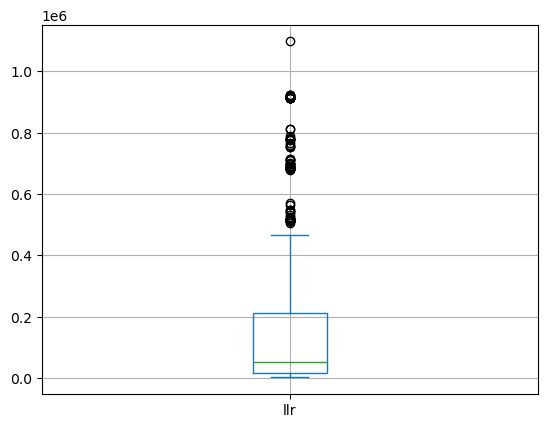

In [44]:
print( 
    features['llr'].plot.box(grid=True) 
)

In [45]:
# je pense qu'on peut tous les garder (il y a un petit "lender of last resort" à la fin)

In [47]:
quadgrams = features['ngram'].to_list()
quadgrams

['federal open market committee',
 'governors of the federal',
 'bis central banker speech',
 'reserve bank of st.',
 'bank of st. louis',
 'digitized for fraser federal',
 'fraser federal reserve bank',
 'reserve bank of new',
 'bank of new york',
 'president and chief executive',
 'employment and price stability',
 'member of the board',
 'stance of monetary policy',
 'officer federal reserve bank',
 'chief executive officer federal',
 'executive officer federal reserve',
 'reserve bank of cleveland',
 'us federal reserve system',
 'reserve bank of san',
 'bank of san francisco',
 'reserve bank of richmond',
 'reserve bank of atlanta',
 'reserve bank of kansas',
 'maximum employment and price',
 'bank of kansas city',
 'governors of the us',
 'colleague on the federal',
 'national bureau of economic',
 'federal deposit insurance corporation',
 'bureau of economic research',
 'play a important role',
 'conduct of monetary policy',
 'reserve bank of boston',
 'reserve bank of chicago',

### Trigrams

In [58]:
colloc_finder = TrigramCollocationFinder.from_documents(tokenized_statements_lemmas)
features = pd.DataFrame.from_dict(colloc_finder.ngram_fd, orient='index').reset_index()
print(f"Nombre de trigrams total: {features.shape[0]}")
features.columns = ['infos', 'count']
features = features [ features['count'] >= 50 ]
features = features.sort_values(by='count', ascending=False)
features

Nombre de trigrams total: 7023922


,infos,count
2797,"(the, federal, reserve)",43434
3002,"(the, united, state)",14592
24,"(federal, reserve, bank)",14323
154,"(for, example, ,)",14063
1226,"(,, and, the)",13985
...,...,...
681803,"(foreign, economy, ,)",50
197434,"(about, the, labor)",50
233904,"(for, the, use)",50
487661,"(trade, with, the)",50


In [59]:
features['lemma_1'] = features['infos'].apply(lambda x: x[0].split('#')[0])
features['lemma_2'] = features['infos'].apply(lambda x: x[1].split('#')[0])
features['lemma_3'] = features['infos'].apply(lambda x: x[2].split('#')[0])
features['ngram'] = features.apply(lambda x: f"{x['lemma_1']} {x['lemma_2']} {x['lemma_3']}", axis=1)
features = features[['ngram', 'count', 'lemma_1', 'lemma_2', 'lemma_3', 'infos']]
features


,ngram,count,lemma_1,lemma_2,lemma_3,infos
2797,the federal reserve,43434,the,federal,reserve,"(the, federal, reserve)"
3002,the united state,14592,the,united,state,"(the, united, state)"
24,federal reserve bank,14323,federal,reserve,bank,"(federal, reserve, bank)"
154,"for example ,",14063,for,example,",","(for, example, ,)"
1226,", and the",13985,",",and,the,"(,, and, the)"
...,...,...,...,...,...,...
681803,"foreign economy ,",50,foreign,economy,",","(foreign, economy, ,)"
197434,about the labor,50,about,the,labor,"(about, the, labor)"
233904,for the use,50,for,the,use,"(for, the, use)"
487661,trade with the,50,trade,with,the,"(trade, with, the)"


In [61]:
features = features[ (
    ~((features['lemma_1'].isin(ponctuation)) | (features['lemma_2'].isin(ponctuation)) | (features['lemma_3'].isin(ponctuation)))
) & (
    ~((features['lemma_1'].isin(stop_words_selected)) | (features['lemma_3'].isin(stop_words_selected)))
) ]
features

,ngram,count,lemma_1,lemma_2,lemma_3,infos
24,federal reserve bank,14323,federal,reserve,bank,"(federal, reserve, bank)"
2668,federal reserve system,10330,federal,reserve,system,"(federal, reserve, system)"
2701,board of governors,7876,board,of,governors,"(board, of, governors)"
107,federal fund rate,6846,federal,fund,rate,"(federal, fund, rate)"
1857,open market committee,5205,open,market,committee,"(open, market, committee)"
...,...,...,...,...,...,...
289931,attempt to reduce,50,attempt,to,reduce,"(attempt, to, reduce)"
74021,much more important,50,much,more,important,"(much, more, important)"
682775,run federal fund,50,run,federal,fund,"(run, federal, fund)"
122219,save and invest,50,save,and,invest,"(save, and, invest)"


In [62]:
features.head(20)

,ngram,count,lemma_1,lemma_2,lemma_3,infos
24,federal reserve bank,14323,federal,reserve,bank,"(federal, reserve, bank)"
2668,federal reserve system,10330,federal,reserve,system,"(federal, reserve, system)"
2701,board of governors,7876,board,of,governors,"(board, of, governors)"
107,federal fund rate,6846,federal,fund,rate,"(federal, fund, rate)"
1857,open market committee,5205,open,market,committee,"(open, market, committee)"
1856,federal open market,5116,federal,open,market,"(federal, open, market)"
12450,bis central banker,4835,bis,central,banker,"(bis, central, banker)"
71,term interest rate,3712,term,interest,rate,"(term, interest, rate)"
12451,central banker speech,3537,central,banker,speech,"(central, banker, speech)"
2624,bank of st.,3247,bank,of,st.,"(bank, of, st.)"


In [73]:
# apply filter to colloc_finder

In [64]:
kept_trigrams = features['ngram'].to_list()
colloc_finder.apply_ngram_filter(lambda w1, w2, w3: f"{w1} {w2} {w3}" not in kept_trigrams)

In [65]:
len(colloc_finder.score_ngrams(TrigramAssocMeasures.raw_freq))

5756

In [66]:
likelihood_ratio = pd.DataFrame(colloc_finder.score_ngrams(TrigramAssocMeasures.likelihood_ratio), columns=['infos', 'llr'])

In [67]:
likelihood_ratio

,infos,llr
0,"(federal, reserve, bank)",776377.753883
1,"(federal, reserve, system)",753692.899938
2,"(federal, reserve, banks)",708904.119974
3,"(fraser, federal, reserve)",704062.288373
4,"(federal, reserve, board)",694426.721776
...,...,...
5751,"(year, of, expansion)",545.388545
5752,"(create, the, condition)",529.364932
5753,"(government, and, central)",485.214057
5754,"(inflation, to, average)",473.866172


In [68]:
features = features.merge(likelihood_ratio, on='infos')
features

,ngram,count,lemma_1,lemma_2,lemma_3,infos,llr
0,federal reserve bank,14323,federal,reserve,bank,"(federal, reserve, bank)",776377.753883
1,federal reserve system,10330,federal,reserve,system,"(federal, reserve, system)",753692.899938
2,board of governors,7876,board,of,governors,"(board, of, governors)",168276.969469
3,federal fund rate,6846,federal,fund,rate,"(federal, fund, rate)",145810.068948
4,open market committee,5205,open,market,committee,"(open, market, committee)",130321.135806
...,...,...,...,...,...,...,...
5751,attempt to reduce,50,attempt,to,reduce,"(attempt, to, reduce)",24213.222567
5752,much more important,50,much,more,important,"(much, more, important)",15656.093494
5753,run federal fund,50,run,federal,fund,"(run, federal, fund)",56852.313669
5754,save and invest,50,save,and,invest,"(save, and, invest)",1793.881954


In [69]:
features.sort_values(by='llr', ascending=False).head(50)

,ngram,count,lemma_1,lemma_2,lemma_3,infos,llr
0,federal reserve bank,14323,federal,reserve,bank,"(federal, reserve, bank)",776377.753883
1,federal reserve system,10330,federal,reserve,system,"(federal, reserve, system)",753692.899938
35,federal reserve banks,1171,federal,reserve,banks,"(federal, reserve, banks)",708904.119974
15,fraser federal reserve,2448,fraser,federal,reserve,"(fraser, federal, reserve)",704062.288373
11,federal reserve board,2817,federal,reserve,board,"(federal, reserve, board)",694426.721776
16,federal reserve 's,2187,federal,reserve,'s,"(federal, reserve, 's)",685920.560992
46,officer federal reserve,1026,officer,federal,reserve,"(officer, federal, reserve)",685559.727843
51,us federal reserve,994,us,federal,reserve,"(us, federal, reserve)",685057.654780
275,federal reserve balance,375,federal,reserve,balance,"(federal, reserve, balance)",683649.871315
127,federal reserve district,620,federal,reserve,district,"(federal, reserve, district)",681023.012976


In [70]:
features.sort_values(by='llr', ascending=False).tail(50)

,ngram,count,lemma_1,lemma_2,lemma_3,infos,llr
3866,credit and market,66,credit,and,market,"(credit, and, market)",940.240331
5640,10 to 15,50,10,to,15,"(10, to, 15)",918.330375
3955,investment by business,65,investment,by,business,"(investment, by, business)",917.811234
5329,provide the necessary,52,provide,the,necessary,"(provide, the, necessary)",890.139467
1725,economy that work,112,economy,that,work,"(economy, that, work)",890.119479
5225,july and august,53,july,and,august,"(july, and, august)",860.724054
5730,bank structure conference,50,bank,structure,conference,"(bank, structure, conference)",859.557874
3916,opportunity and challenge,66,opportunity,and,challenge,"(opportunity, and, challenge)",855.324032
3816,percent to percent,67,percent,to,percent,"(percent, to, percent)",847.587445
4515,credit to business,59,credit,to,business,"(credit, to, business)",844.769721


Axes(0.125,0.11;0.775x0.77)


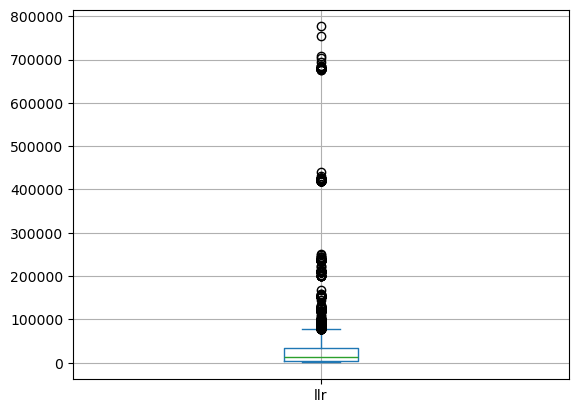

In [71]:
print( 
    features['llr'].plot.box(grid=True) 
)

In [73]:
trigrams = features['ngram'].to_list()
trigrams

['federal reserve bank',
 'federal reserve system',
 'board of governors',
 'federal fund rate',
 'open market committee',
 'federal open market',
 'bis central banker',
 'term interest rate',
 'central banker speech',
 'bank of st.',
 'bank hold company',
 'federal reserve board',
 'digitized for fraser',
 'goods and service',
 'bank of new',
 'fraser federal reserve',
 "federal reserve 's",
 'around the world',
 'real interest rate',
 'safety and soundness',
 'household and business',
 'new york fed',
 'labor force participation',
 'chief executive officer',
 'low interest rate',
 'commercial real estate',
 'economic and financial',
 'supervision and regulation',
 'gross domestic product',
 'president and chief',
 'rate of inflation',
 'employment and price',
 'feed fund rate',
 'food and energy',
 'past few year',
 'federal reserve banks',
 'board of director',
 'stance of monetary',
 'president and ceo',
 'federal deposit insurance',
 'standard of live',
 'personal consumption expe

### Bigrams

In [87]:
colloc_finder = BigramCollocationFinder.from_documents(tokenized_statements_lemmas)
features = pd.DataFrame.from_dict(colloc_finder.ngram_fd, orient='index').reset_index()
print(f"Nombre de bigrams total: {features.shape[0]}")
features.columns = ['infos', 'count']
features = features [ features['count'] >= 50 ]
features = features.sort_values(by='count', ascending=False)
features

Nombre de bigrams total: 1645380


,infos,count
170,"(of, the)",173590
194,"(in, the)",141038
298,"(,, and)",122059
78,"(,, the)",109531
281,"(., the)",92009
...,...,...
42805,"(and, against)",50
15593,"(they, leave)",50
320152,"(germany, be)",50
92173,"(december, 17)",50


In [88]:
features['lemma_1'] = features['infos'].apply(lambda x: x[0].split('#')[0])
features['lemma_2'] = features['infos'].apply(lambda x: x[1].split('#')[0])
features['ngram'] = features.apply(lambda x: f"{x['lemma_1']} {x['lemma_2']}", axis=1)
features = features[['ngram', 'count', 'lemma_1', 'lemma_2', 'infos']]
features


,ngram,count,lemma_1,lemma_2,infos
170,of the,173590,of,the,"(of, the)"
194,in the,141038,in,the,"(in, the)"
298,", and",122059,",",and,"(,, and)"
78,", the",109531,",",the,"(,, the)"
281,. the,92009,.,the,"(., the)"
...,...,...,...,...,...
42805,and against,50,and,against,"(and, against)"
15593,they leave,50,they,leave,"(they, leave)"
320152,germany be,50,germany,be,"(germany, be)"
92173,december 17,50,december,17,"(december, 17)"


In [90]:
features = features[ (
    ~((features['lemma_1'].isin(ponctuation)) | (features['lemma_2'].isin(ponctuation)))
) & (
    ~((features['lemma_1'].isin(stop_words_selected)) | (features['lemma_2'].isin(stop_words_selected)))
) ]
features

,ngram,count,lemma_1,lemma_2,infos
24,federal reserve,60664,federal,reserve,"(federal, reserve)"
39,monetary policy,41001,monetary,policy,"(monetary, policy)"
69,interest rate,21965,interest,rate,"(interest, rate)"
2232,central bank,17720,central,bank,"(central, bank)"
25,reserve bank,16406,reserve,bank,"(reserve, bank)"
...,...,...,...,...,...
154320,general revenue,50,general,revenue,"(general, revenue)"
214541,major disruption,50,major,disruption,"(major, disruption)"
27518,toward economic,50,toward,economic,"(toward, economic)"
92173,december 17,50,december,17,"(december, 17)"


In [91]:
features.head(20)

,ngram,count,lemma_1,lemma_2,infos
24,federal reserve,60664,federal,reserve,"(federal, reserve)"
39,monetary policy,41001,monetary,policy,"(monetary, policy)"
69,interest rate,21965,interest,rate,"(interest, rate)"
2232,central bank,17720,central,bank,"(central, bank)"
25,reserve bank,16406,reserve,bank,"(reserve, bank)"
2352,united state,15098,united,state,"(united, state)"
1216,labor market,11728,labor,market,"(labor, market)"
1698,financial market,11240,financial,market,"(financial, market)"
2101,reserve system,10380,reserve,system,"(reserve, system)"
7492,financial system,10272,financial,system,"(financial, system)"


In [93]:
# apply filter to colloc_finder

In [94]:
kept_bigrams = features['ngram'].to_list()
colloc_finder.apply_ngram_filter(lambda w1, w2: f"{w1} {w2}" not in kept_bigrams)

In [95]:
len(colloc_finder.score_ngrams(BigramAssocMeasures.raw_freq))

13293

In [96]:
likelihood_ratio = pd.DataFrame(colloc_finder.score_ngrams(BigramAssocMeasures.likelihood_ratio), columns=['infos', 'llr'])

In [88]:
likelihood_ratio

,infos,llr
0,"(federal, reserve)",663263.274056
1,"(monetary, policy)",408009.883007
2,"(interest, rate)",202484.558299
3,"(united, state)",190932.582447
4,"(central, bank)",145481.638320
...,...,...
12953,"(think, will)",0.003108
12954,"(percent, low)",0.001668
12955,"(market, still)",0.000166
12956,"(rate, continue)",0.000106


In [97]:
features = features.merge(likelihood_ratio, on='infos')
features

,ngram,count,lemma_1,lemma_2,infos,llr
0,federal reserve,60664,federal,reserve,"(federal, reserve)",676998.281216
1,monetary policy,41001,monetary,policy,"(monetary, policy)",420116.426668
2,interest rate,21965,interest,rate,"(interest, rate)",208941.530660
3,central bank,17720,central,bank,"(central, bank)",152174.995443
4,reserve bank,16406,reserve,bank,"(reserve, bank)",98665.366179
...,...,...,...,...,...,...
13288,general revenue,50,general,revenue,"(general, revenue)",358.632152
13289,major disruption,50,major,disruption,"(major, disruption)",285.254851
13290,toward economic,50,toward,economic,"(toward, economic)",30.073468
13291,december 17,50,december,17,"(december, 17)",361.640968


In [179]:
# features['llr_pvalue'] = features['llr'].apply(chi2_p_value)
# features

In [98]:
features.sort_values(by='llr', ascending=False).head(50)

,ngram,count,lemma_1,lemma_2,infos,llr
0,federal reserve,60664,federal,reserve,"(federal, reserve)",676998.281216
1,monetary policy,41001,monetary,policy,"(monetary, policy)",420116.426668
2,interest rate,21965,interest,rate,"(interest, rate)",208941.530660
5,united state,15098,united,state,"(united, state)",200894.330668
3,central bank,17720,central,bank,"(central, bank)",152174.995443
15,balance sheet,8786,balance,sheet,"(balance, sheet)",125942.381277
13,new york,9147,new,york,"(new, york)",117724.797491
4,reserve bank,16406,reserve,bank,"(reserve, bank)",98665.366179
6,labor market,11728,labor,market,"(labor, market)",97348.191203
34,st. louis,4778,st.,louis,"(st., louis)",88400.394388


In [99]:
features.sort_values(by='llr', ascending=False).tail(50)

,ngram,count,lemma_1,lemma_2,infos,llr
7283,reserve large,85,reserve,large,"(reserve, large)",0.230424
10488,also good,61,also,good,"(also, good)",0.228534
3330,long rate,160,long,rate,"(long, rate)",0.228114
12533,take one,52,take,one,"(take, one)",0.224960
5379,make economic,108,make,economic,"(make, economic)",0.222439
11304,fund can,57,fund,can,"(fund, can)",0.214662
7544,reserve use,82,reserve,use,"(reserve, use)",0.214121
7535,market today,82,market,today,"(market, today)",0.207729
3989,term market,139,term,market,"(term, market)",0.200620
11052,1 economic,58,1,economic,"(1, economic)",0.199406


Axes(0.125,0.11;0.775x0.77)


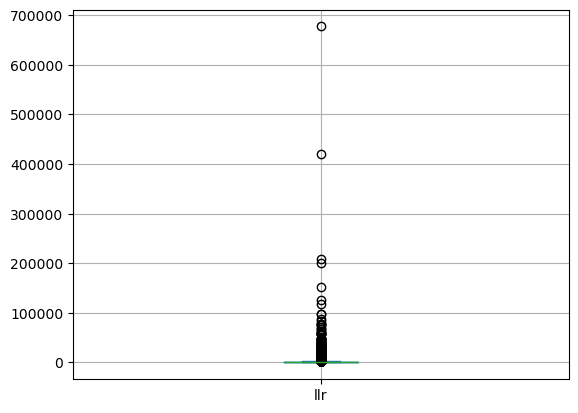

In [100]:
print( 
    features['llr'].plot.box(grid=True) 
)

In [93]:
print(features [ np.percentile(features['llr'], 75) <= features['llr'] ].sort_values(by='llr', ascending=False).to_markdown())

|       | ngram                       |   count | lemma_1           | lemma_2         | infos                              |        llr |
|------:|:----------------------------|--------:|:------------------|:----------------|:-----------------------------------|-----------:|
|     0 | federal reserve             |   59455 | federal           | reserve         | ('federal', 'reserve')             | 663263     |
|     1 | monetary policy             |   39682 | monetary          | policy          | ('monetary', 'policy')             | 408010     |
|     2 | interest rate               |   21215 | interest          | rate            | ('interest', 'rate')               | 202485     |
|     5 | united state                |   14330 | united            | state           | ('united', 'state')                | 190933     |
|     3 | central bank                |   17048 | central           | bank            | ('central', 'bank')                | 145482     |
|    15 | balance sheet           

In [94]:
print( features [ np.percentile(features['llr'], 50) > features['llr'] ].drop('infos', axis=1).sort_values(by='llr', ascending=False).to_markdown() )

|       | ngram                     |   count | lemma_1        | lemma_2         |           llr |
|------:|:--------------------------|--------:|:---------------|:----------------|--------------:|
| 11137 | fintech company           |      57 | fintech        | company         | 447.872       |
|  4226 | recent meeting            |     129 | recent         | meeting         | 447.839       |
| 10084 | april 19                  |      62 | april          | 19              | 447.805       |
| 11687 | gross settlement          |      54 | gross          | settlement      | 447.684       |
| 12207 | vast amount               |      52 | vast           | amount          | 447.636       |
|  2836 | market outcome            |     179 | market         | outcome         | 447.579       |
|  6057 | per person                |      96 | per            | person          | 447.257       |
| 12097 | fairly quickly            |      53 | fairly         | quickly         | 447.229       |
| 10333 | 

In [101]:
bigrams = features[ np.percentile(features['llr'], 50) <= features['llr'] ]['ngram'].to_list()
bigrams

['federal reserve',
 'monetary policy',
 'interest rate',
 'central bank',
 'reserve bank',
 'united state',
 'labor market',
 'financial market',
 'reserve system',
 'financial system',
 '2 percent',
 'fund rate',
 'financial institution',
 'new york',
 'unemployment rate',
 'balance sheet',
 'price stability',
 'federal fund',
 'economic growth',
 'last year',
 'open market',
 'inflation expectation',
 'central banker',
 'financial stability',
 'financial crisis',
 'u.s. economy',
 'economic activity',
 'banking system',
 'hold company',
 'market committee',
 'risk management',
 'small business',
 'federal open',
 'bis central',
 'st. louis',
 'productivity growth',
 'financial service',
 'market participant',
 'recent year',
 'labor force',
 'payment system',
 'community bank',
 'real estate',
 'economic outlook',
 'banking organization',
 'will continue',
 'term interest',
 'percentage point',
 'year ago',
 'exchange rate',
 'banker speech',
 "fed 's",
 'deposit insurance',
 'finan

## Fusion de termes et retrait des stopwords

In [115]:
tokenized_statements_lemmas_ngrams = []

In [116]:
from tqdm import tqdm

In [117]:
for i, st in tqdm(enumerate(tokenized_statements_lemmas)):
    st = ' '.join(st)
    for q in quadgrams:
        if q in st:
            st = st.replace(q, '_' + q.replace(' ', '_') + '_') # mettre des '_' et encadrer par des '#' pour ne pas que ce soit joint à un autre nrgam
            # print(i, q, st)
    for t in trigrams:
        if t in st:
            st = st.replace(t, '_' + t.replace(' ', '_') + '_') # mettre des '_' et encadrer par des '#' pour ne pas que ce soit joint à un autre nrgam
            # print(i, t, st)
    for b in bigrams:
        if b in st:
            st = st.replace(b, '_' + b.replace(' ', '_') + '_') # mettre des '_' et encadrer par des '#' pour ne pas que ce soit joint à un autre nrgam
            # print(i, b, st)
    tokenized_statements_lemmas_ngrams.append(st.split(' '))

7239it [25:50,  4.67it/s]


In [118]:
tokenized_statements_lemmas_ngrams[:4]

[['hold___for___release___at___8:30___a.m.___pst___friday___,___november___4___,___1994___western___growers___association____robert_t._parry____,___president___tucson___,___az___federal____reserve_bank_of_san_____francisco_for_delivery____on___november___4___,___1994___shifting___to___another___gear___:____monetary_policy____in___1994___i___.____good_morning____.___a___.___this___year____monetary_policy____begin___shift___into___another___gear___.___1___.___after____four_year____of___gradually___lower___short___-____term_interest_rate____to____stimulate_the_economy____recovery___from___recession___,___the___fed___begin____raise_rate____in___february___.___a___.___all___tell___,___this___year___,___there___have___be___five____rate_increase____,___bear___take___the____federal_fund_rate____from____3_percent____to___4___%___percent___.___b.___the___fed___take___this___action___to___contain___the___buildup___of____inflationary_pressure____,___which___be___key___to___foster____sustainable_ec

In [115]:
# tokenized_statements_lemmas_ngrams_cleaned = []

In [116]:
# for statement in tqdm(tokenized_statements_lemmas_ngrams):
#     temp = []
#     for tok in statement:
#         if tok in stop_words_selected or tok in ponctuation:
#             continue
#         else:
#             temp.append(tok)
#     tokenized_statements_lemmas_ngrams_cleaned.append(temp)

100%|██████████| 7107/7107 [00:00<00:00, 175439.46it/s]


In [117]:
# tokenized_statements_lemmas_ngrams_cleaned[:4]

[["small___enterprise___capital___access___partnerships___(___secap___)___federal____reserve_bank_of_chicago____chicago___,___illinois___september___15___,___1999___i.____good_morning____.___i___be___pleased___to___welcome___you___here___today___as___we___formally___kick___off___the___small___enterprise___capital___access___partnership___,___or___secap___.___a.___before___i___talk___about___the___initiative___,___i___would___like___to___recognize___the___organization___that___have___agree___to___co-convene___secap___with___the___federal___reser___have____bank_of_chicago____.___the___secap___co-convener___include___the___chicago___association___of___neighborhood___development___organizations___,___good___know___as___cando___,___the___womens___business___development___center___,___the___chicago___district___office___of___the___u.s.___sba___,___the___chicagoland____chamber_of_commerce____,___the___illinois____bankers_association____,___and___the___cosmopolitan____chamber_of_commerce____._

In [120]:
import pickle

with open("tokenized_statements_lemmas_ngrams", "wb") as fp:   #Pickling
    pickle.dump(tokenized_statements_lemmas_ngrams, fp)



In [19]:
import pickle
with open("tokenized_statements_lemmas_ngrams", "rb") as fp:   # Unpickling
    tokenized_statements_lemmas_ngrams = pickle.load(fp)

In [21]:
tokenized_statements_lemmas_ngrams[:3]

[['hold___for___release___at___8:30___a.m.___pst___friday___,___november___4___,___1994___western___growers___association____robert_t._parry____,___president___tucson___,___az___federal____reserve_bank_of_san_____francisco_for_delivery____on___november___4___,___1994___shifting___to___another___gear___:____monetary_policy____in___1994___i___.____good_morning____.___a___.___this___year____monetary_policy____begin___shift___into___another___gear___.___1___.___after____four_year____of___gradually___lower___short___-____term_interest_rate____to____stimulate_the_economy____recovery___from___recession___,___the___fed___begin____raise_rate____in___february___.___a___.___all___tell___,___this___year___,___there___have___be___five____rate_increase____,___bear___take___the____federal_fund_rate____from____3_percent____to___4___%___percent___.___b.___the___fed___take___this___action___to___contain___the___buildup___of____inflationary_pressure____,___which___be___key___to___foster____sustainable_ec

## Do this only when it has the weird ___ thingy

In [22]:
def smart_split(text):
    # 1. Split on 3 or more underscores
    parts = re.split(r'_{3,}', text)

    cleaned = []
    for p in parts:
        if not p:
            continue

        # 2. If the token contains at least one underscore,
        #    but does NOT already start and end with one,
        #    wrap it with underscores.
        if "_" in p and not (p.startswith("_") and p.endswith("_")):
            p = f"_{p}_"

        cleaned.append(p)

    return cleaned

tokenized_statements_lemmas_ngrams_cleaned2 = [
    [smart_split(text) for text in sublist]
    for sublist in tokenized_statements_lemmas_ngrams
]

tokenized_statements_lemmas_ngrams_cleaned2[:2]


[[['hold',
   'for',
   'release',
   'at',
   '8:30',
   'a.m.',
   'pst',
   'friday',
   ',',
   'november',
   '4',
   ',',
   '1994',
   'western',
   'growers',
   'association',
   '_robert_t._parry_',
   ',',
   'president',
   'tucson',
   ',',
   'az',
   'federal',
   '_reserve_bank_of_san_',
   '_francisco_for_delivery_',
   'on',
   'november',
   '4',
   ',',
   '1994',
   'shifting',
   'to',
   'another',
   'gear',
   ':',
   '_monetary_policy_',
   'in',
   '1994',
   'i',
   '.',
   '_good_morning_',
   '.',
   'a',
   '.',
   'this',
   'year',
   '_monetary_policy_',
   'begin',
   'shift',
   'into',
   'another',
   'gear',
   '.',
   '1',
   '.',
   'after',
   '_four_year_',
   'of',
   'gradually',
   'lower',
   'short',
   '-',
   '_term_interest_rate_',
   'to',
   '_stimulate_the_economy_',
   'recovery',
   'from',
   'recession',
   ',',
   'the',
   'fed',
   'begin',
   '_raise_rate_',
   'in',
   'february',
   '.',
   'a',
   '.',
   'all',
   'tell'

In [36]:
# only did if they have 3 brackets
dummy = [inner[0] for inner in tokenized_statements_lemmas_ngrams_cleaned2]
dummy[:2]

[['hold',
  'for',
  'release',
  'at',
  '8:30',
  'a.m.',
  'pst',
  'friday',
  ',',
  'november',
  '4',
  ',',
  '1994',
  'western',
  'growers',
  'association',
  '_robert_t._parry_',
  ',',
  'president',
  'tucson',
  ',',
  'az',
  'federal',
  '_reserve_bank_of_san_',
  '_francisco_for_delivery_',
  'on',
  'november',
  '4',
  ',',
  '1994',
  'shifting',
  'to',
  'another',
  'gear',
  ':',
  '_monetary_policy_',
  'in',
  '1994',
  'i',
  '.',
  '_good_morning_',
  '.',
  'a',
  '.',
  'this',
  'year',
  '_monetary_policy_',
  'begin',
  'shift',
  'into',
  'another',
  'gear',
  '.',
  '1',
  '.',
  'after',
  '_four_year_',
  'of',
  'gradually',
  'lower',
  'short',
  '-',
  '_term_interest_rate_',
  'to',
  '_stimulate_the_economy_',
  'recovery',
  'from',
  'recession',
  ',',
  'the',
  'fed',
  'begin',
  '_raise_rate_',
  'in',
  'february',
  '.',
  'a',
  '.',
  'all',
  'tell',
  ',',
  'this',
  'year',
  ',',
  'there',
  'have',
  'be',
  'five',
  '_r

In [44]:
# i need to remove stop words and thingy again!
tokenized_statements_lemmas_ngrams_cleaned3 = []

In [46]:
from tqdm import tqdm
for statement in tqdm(dummy):
    temp = []
    for tok in statement:
        if tok in stop_words_selected or tok in ponctuation:
            continue
        else:
            temp.append(tok)
    tokenized_statements_lemmas_ngrams_cleaned3.append(temp)
    

100%|██████████| 7239/7239 [00:59<00:00, 121.77it/s]


In [47]:
tokenized_statements_lemmas_ngrams_cleaned3[:2]


[['hold',
  'release',
  '8:30',
  'a.m.',
  'pst',
  'friday',
  'november',
  '4',
  '1994',
  'western',
  'growers',
  'association',
  '_robert_t._parry_',
  'president',
  'tucson',
  'az',
  'federal',
  '_reserve_bank_of_san_',
  '_francisco_for_delivery_',
  'november',
  '4',
  '1994',
  'shifting',
  'another',
  'gear',
  '_monetary_policy_',
  '1994',
  '_good_morning_',
  'year',
  '_monetary_policy_',
  'begin',
  'shift',
  'another',
  'gear',
  '1',
  '_four_year_',
  'gradually',
  'lower',
  'short',
  '_term_interest_rate_',
  '_stimulate_the_economy_',
  'recovery',
  'recession',
  'fed',
  'begin',
  '_raise_rate_',
  'february',
  'tell',
  'year',
  'five',
  '_rate_increase_',
  'bear',
  'take',
  '_federal_fund_rate_',
  '_3_percent_',
  '4',
  'percent',
  'b.',
  'fed',
  'take',
  'action',
  'contain',
  'buildup',
  '_inflationary_pressure_',
  'key',
  'foster',
  '_sustainable_economic_growth_',
  'c.',
  'move',
  'meet',
  'controversy',
  'quarter

In [50]:
import pickle

with open("LDAtokenized", "wb") as fp:   #Pickling
    pickle.dump(tokenized_statements_lemmas_ngrams_cleaned3, fp)


## LDA

In [14]:
import pickle
with open("LDAtokenized", "rb") as fp:   # Unpickling
    tokenized_statements_lemmas_ngrams_cleaned = pickle.load(fp)
tokenized_statements_lemmas_ngrams_cleaned[:2]


[['hold',
  'release',
  '8:30',
  'a.m.',
  'pst',
  'friday',
  'november',
  '4',
  '1994',
  'western',
  'growers',
  'association',
  '_robert_t._parry_',
  'president',
  'tucson',
  'az',
  'federal',
  '_reserve_bank_of_san_',
  '_francisco_for_delivery_',
  'november',
  '4',
  '1994',
  'shifting',
  'another',
  'gear',
  '_monetary_policy_',
  '1994',
  '_good_morning_',
  'year',
  '_monetary_policy_',
  'begin',
  'shift',
  'another',
  'gear',
  '1',
  '_four_year_',
  'gradually',
  'lower',
  'short',
  '_term_interest_rate_',
  '_stimulate_the_economy_',
  'recovery',
  'recession',
  'fed',
  'begin',
  '_raise_rate_',
  'february',
  'tell',
  'year',
  'five',
  '_rate_increase_',
  'bear',
  'take',
  '_federal_fund_rate_',
  '_3_percent_',
  '4',
  'percent',
  'b.',
  'fed',
  'take',
  'action',
  'contain',
  'buildup',
  '_inflationary_pressure_',
  'key',
  'foster',
  '_sustainable_economic_growth_',
  'c.',
  'move',
  'meet',
  'controversy',
  'quarter

In [16]:
def identity_tokenizer(text):
    return text

In [17]:
n_top_words = 10

In [18]:
def plot_top_words(model, feature_names, n_components, n_top_words, title, filename):

    unique_values, counts = np.unique(np.argmax(model.components_, axis=0), return_counts=True)
    topics_ordered_by_most_tokens = list(pd.Series(data=counts, index=unique_values).sort_values(ascending=False).index)
    
    topics_words_distribution = model.components_ / model.components_.sum(axis=1)[:, np.newaxis]

    fig, axes = plt.subplots(n_components//5, 5, figsize=(50, 15*n_components//10), sharex=True)
    axes = axes.flatten()

    for idx, topic_idx in enumerate(topics_ordered_by_most_tokens):
        # topic = model.components_[topic_idx]
        # topic = ( model.components_ / model.components_.sum(axis=1)[:, np.newaxis] ) [topic_idx, :]
        topic = topics_words_distribution [topic_idx, :]
        top_features_ind = topic.argsort()[-n_top_words:]
        top_features = feature_names[top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx +1}", fontdict={"fontsize": 30})
        ax.tick_params(axis="both", which="major", labelsize=20)
        for i in "top right left".split():
            ax.spines[i].set_visible(False)
        fig.suptitle(title, fontsize=40)

    plt.subplots_adjust(top=0.90, bottom=0.05, wspace=0.90, hspace=0.3)
    plt.show()

    fig.savefig("Graphs/TopicModel"+filename)

def print_top_words(model, feature_names, n_top_words=15):
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        print(f"Topic {topic_idx}: {' | '.join(top_features)}")


In [20]:
vectorizer = CountVectorizer(
    tokenizer=identity_tokenizer, lowercase=False, # identity tokenization since we already did it
    ngram_range=(1, 1)
)    
tf = vectorizer.fit_transform(tokenized_statements_lemmas_ngrams_cleaned)

C:\Users\Lynn\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [21]:
features_count = tf.sum(axis=0).tolist()[0]
features_names = vectorizer.get_feature_names_out()
features = pd.DataFrame(
    zip(features_names, features_count), 
    columns=['feature', 'count']
).sort_values(by=['count'], ascending=False)
features

,feature,count
122231,will,47130
44985,bank,41913
48894,can,36052
83272,market,32919
115266,time,32280
...,...,...
76453,investiment,1
27698,_less_than_3_.5_,1
76455,investingand,1
76456,investisant,1


In [218]:
(tf[:, 3320].indptr == 0).sum()

484

In [219]:
tf[:, 3320].data

array([1], dtype=int64)

In [224]:
tf[4, 3320]

0

In [283]:
tokenized_statements[121235]

['thank#thank',
 'you#you',
 ',#,',
 'mr.#mr.',
 'chair#chair',
 '.#.',
 'over#over',
 'the#the',
 'past#past',
 'month#month',
 ',#,',
 'most#most',
 'real#real',
 '-#-',
 'sector#sector',
 'economic#economic',
 'data#datum',
 'have#have',
 'come#come',
 'in#in',
 'as#as',
 'expected#expect',
 ',#,',
 'resulting#result',
 'in#in',
 'surprisingly#surprisingly',
 'little#little',
 'change#change',
 'in#in',
 'most#most',
 'economic#economic',
 'forecasts#forecast',
 '.#.',
 'in#in',
 'contrast#contrast',
 ',#,',
 'many#many',
 'financial#financial',
 'indicators#indicator',
 'have#have',
 'been#be',
 'downbeat#downbeat',
 '.#.',
 'the#the',
 'stock#stock',
 'market#market',
 'is#be',
 'significantly#significantly',
 'lower#low',
 ',#,',
 'and#and',
 'the#the',
 'treasury#treasury',
 'yield#yield',
 'curve#curve',
 'has#have',
 'flattened#flatten',
 'as#as',
 'the#the',
 '10#10',
 '-#-',
 'year#year',
 'treasury#treasury',
 'rate#rate',
 'has#have',
 'fallen#fall',
 'about#about',
 '30#3

In [287]:
shuffled_df.iloc[121235].values

array(['MR. ROSENGREN',
       'Thank you, Mr. Chair. Over the past month, most real-sector economic data have come in as expected, resulting in surprisingly little change in most economic forecasts. In contrast, many financial indicators have been downbeat. The stock market is significantly lower, and the Treasury yield curve has flattened as the 10-year Treasury rate has fallen about 30 basis points below its level as of the previous FOMC meeting. So now it is a bit of a dilemma as to how the seemingly conflicting data should affect our outlook and policy decisions. As I mentioned, most of the economic data have come in as expected and are relatively upbeat. Payroll employment over the past three months grew, on average, by 170,000, well above what is necessary to keep the unemployment rate steady. Unfortunately, the resulting downward pressure on the unemployment rate is occurring when unemployment is already at a level well below the range of most forecasters’ estimates of what is 

In [22]:
N_COMPONENTS = 10
# Fit the LDA model
print(
    "Fitting LDA models with tf features"
)
lda_10 = LatentDirichletAllocation(
    n_components=N_COMPONENTS,
    #doc_topic_prior=1/N_COMPONENTS, # adding 1 fake word
    #topic_word_prior=1/N_COMPONENTS, # adding 
    learning_method="online",
    max_iter=100,
    evaluate_every=1,
    verbose=True,
    random_state=118712
)
t0 = time()
lda_10.fit(tf)
print("done in %0.3fs." % (time() - t0))

Fitting LDA models with tf features
iteration: 1 of max_iter: 100, perplexity: 4586.3175
iteration: 2 of max_iter: 100, perplexity: 4456.1232
iteration: 3 of max_iter: 100, perplexity: 4420.7691



KeyboardInterrupt



In [ ]:
plot_top_words(lda_10, features_names, N_COMPONENTS, n_top_words, "Topics in LDA model", 'LDA/lda_10_lemma.png')


In [25]:
print(features['feature'].head(100).to_list())

['will', 'bank', 'can', 'market', 'time', 'risk', 'also', 'one', 'economy', 'increase', 'inflation', 'long', 'may', 'make', 'policy', 'well', 'change', "'s", 'many', 'see', 'year', 'use', 'good', 'new', 'high', 'work', 'rate', 'provide', 'growth', 'include', 'need', 'however', 'example', 'now', 'even', 'business', 'term', 'low', '_federal_reserve_', 'first', '2', 'large', 'firm', 'think', '1', 'issue', 'much', 'important', 'result', 'u.s.', 'today', 'take', 'price', 'system', 'fed', '--', 'problem', '_monetary_policy_', 'economic', 'give', 'continue', 'state', 'view', 'institution', 'cost', 'country', 'know', 'datum', 'level', 'just', 'expect', 'financial', 'effect', 'asset', 'loan', 'part', 'measure', 'way', '3', 'future', 'process', 'great', 'run', 'support', 'since', 'person', 'still', 'like', 'decline', 'less', 'help', 'current', 'remain', 'information', 'capital', 'two', 'credit', 'fomc', 'must', 'say']


In [26]:
# find garbage tokens potentially
features[(features['feature'].str.len() <= 2)].sort_values('count', ascending=False).head(50)


,feature,count
153,'s,23910
5994,2,17948
2061,1,17425
275,--,15758
8997,3,13599
69396,go,12210
10242,4,10697
11288,5,8336
2553,10,6867
12097,6,6805


In [29]:
stop_supp = [
    # Generic modal / filler words / formatting / garbage tokens
    'will', 'however', 'although', 'since', 
    '"', "''", 's/.', '--', "'s", "—", "1s","uh","um",
    'a.', 'b.', 'c.', 'd.', 'e.', 'f.', 'g.', 'h.', 'i.', 'j.', 'k.', 'l.', 'm.',
    'n.', 'o.', 'p.', 'q.', 'r.', 's.', 't.', 'u.', 'v.', 'w.', 'x.', 'y.', 'z.',


    # Boilerplate speech words (non‑economic)
    'thank', 'thanks', 'today', 'conference', 'remarks', 'welcome', 'pleased',
    'honor', 'discuss', 'talk', 'speak', 'question', 'answer', 'audience',
    'panel', 'event', 'symposium',

    # Numeric / magnitude words (safe to remove)
    'percent', '_per_cent_', 'million', 'billion', 'trillion', 'cent',

    # Generic connectors / weak semantic content
    'include', 'result', 'factor', 'impact', 'recent', 'reflect', 'trend',
    'follow', 'base', 'overall',

    # Time words that do NOT help distinguish topics
    'time', 'current', 'end'
    
]


In [30]:
filtered_voc = features[
    (features['count'] >= 50)
    & ~(features['feature'].isin(stop_supp))
    & ~(features['feature'].str.isdigit())
    & features['feature'].str.len().ge(2)
    & features['feature'].str.contains(r"[A-Za-z]", regex=True)  # must contain at least one letter
    & ~features['feature'].str.fullmatch(r"[\W_]+")           # remove pure punctuation
]['feature'].to_list()


filtered_voc[:10]


['bank',
 'can',
 'market',
 'risk',
 'also',
 'one',
 'economy',
 'increase',
 'inflation',
 'long']

In [497]:
# allFeatures = features['feature'].tolist()
# with open('allFeatures.txt', 'w') as file:
#     file.writelines(f"{item}\n" for item in allFeatures)


In [498]:
# results = [s for s in allFeatures if '"' in s]
# results

In [33]:
vectorizer = CountVectorizer(
    tokenizer=identity_tokenizer, lowercase=False, # identity tokenization since we already did it
    ngram_range=(1, 1),
    vocabulary=filtered_voc
)    
tf = vectorizer.fit_transform(tokenized_statements_lemmas_ngrams_cleaned)

C:\Users\Lynn\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:521: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [34]:
features_count = tf.sum(axis=0).tolist()[0]
features_names = vectorizer.get_feature_names_out()
features = pd.DataFrame(
    zip(features_names, features_count), 
    columns=['feature', 'count']
).sort_values(by=['count'], ascending=False)
features

,feature,count
0,bank,41913
1,can,36052
2,market,32919
3,risk,32274
4,also,31964
...,...,...
15686,_include_the_follow_,50
15687,_need_to_help_,50
15688,marine,50
15689,unbiased,50


In [502]:
# https://stackoverflow.com/questions/46326173/understanding-lda-topic-modelling-too-much-topic-overlap

In [35]:
N_COMPONENTS = 10
# Fit the LDA model
print(
    "Fitting LDA models with tf features"
)
lda_10_filtered = LatentDirichletAllocation(
    n_components=N_COMPONENTS,
    #doc_topic_prior=1/N_COMPONENTS, # adding 1 fake word
    #topic_word_prior=1/N_COMPONENTS, # adding 
    learning_method="online",
    max_iter=100,
    evaluate_every=1,
    verbose=True,
    random_state=118712
)
t0 = time()
lda_10_filtered.fit(tf)
print("done in %0.3fs." % (time() - t0))

Fitting LDA models with tf features
iteration: 1 of max_iter: 100, perplexity: 2980.2812
iteration: 2 of max_iter: 100, perplexity: 2954.9718
iteration: 3 of max_iter: 100, perplexity: 2946.0717
iteration: 4 of max_iter: 100, perplexity: 2941.3756
iteration: 5 of max_iter: 100, perplexity: 2938.4272
iteration: 6 of max_iter: 100, perplexity: 2936.3847
iteration: 7 of max_iter: 100, perplexity: 2934.8544
iteration: 8 of max_iter: 100, perplexity: 2933.6597
iteration: 9 of max_iter: 100, perplexity: 2932.6896
iteration: 10 of max_iter: 100, perplexity: 2931.8875
iteration: 11 of max_iter: 100, perplexity: 2931.2017
iteration: 12 of max_iter: 100, perplexity: 2930.5978
iteration: 13 of max_iter: 100, perplexity: 2930.0715
iteration: 14 of max_iter: 100, perplexity: 2929.6029
iteration: 15 of max_iter: 100, perplexity: 2929.1835
iteration: 16 of max_iter: 100, perplexity: 2928.8063
iteration: 17 of max_iter: 100, perplexity: 2928.4719
iteration: 18 of max_iter: 100, perplexity: 2928.1594
i

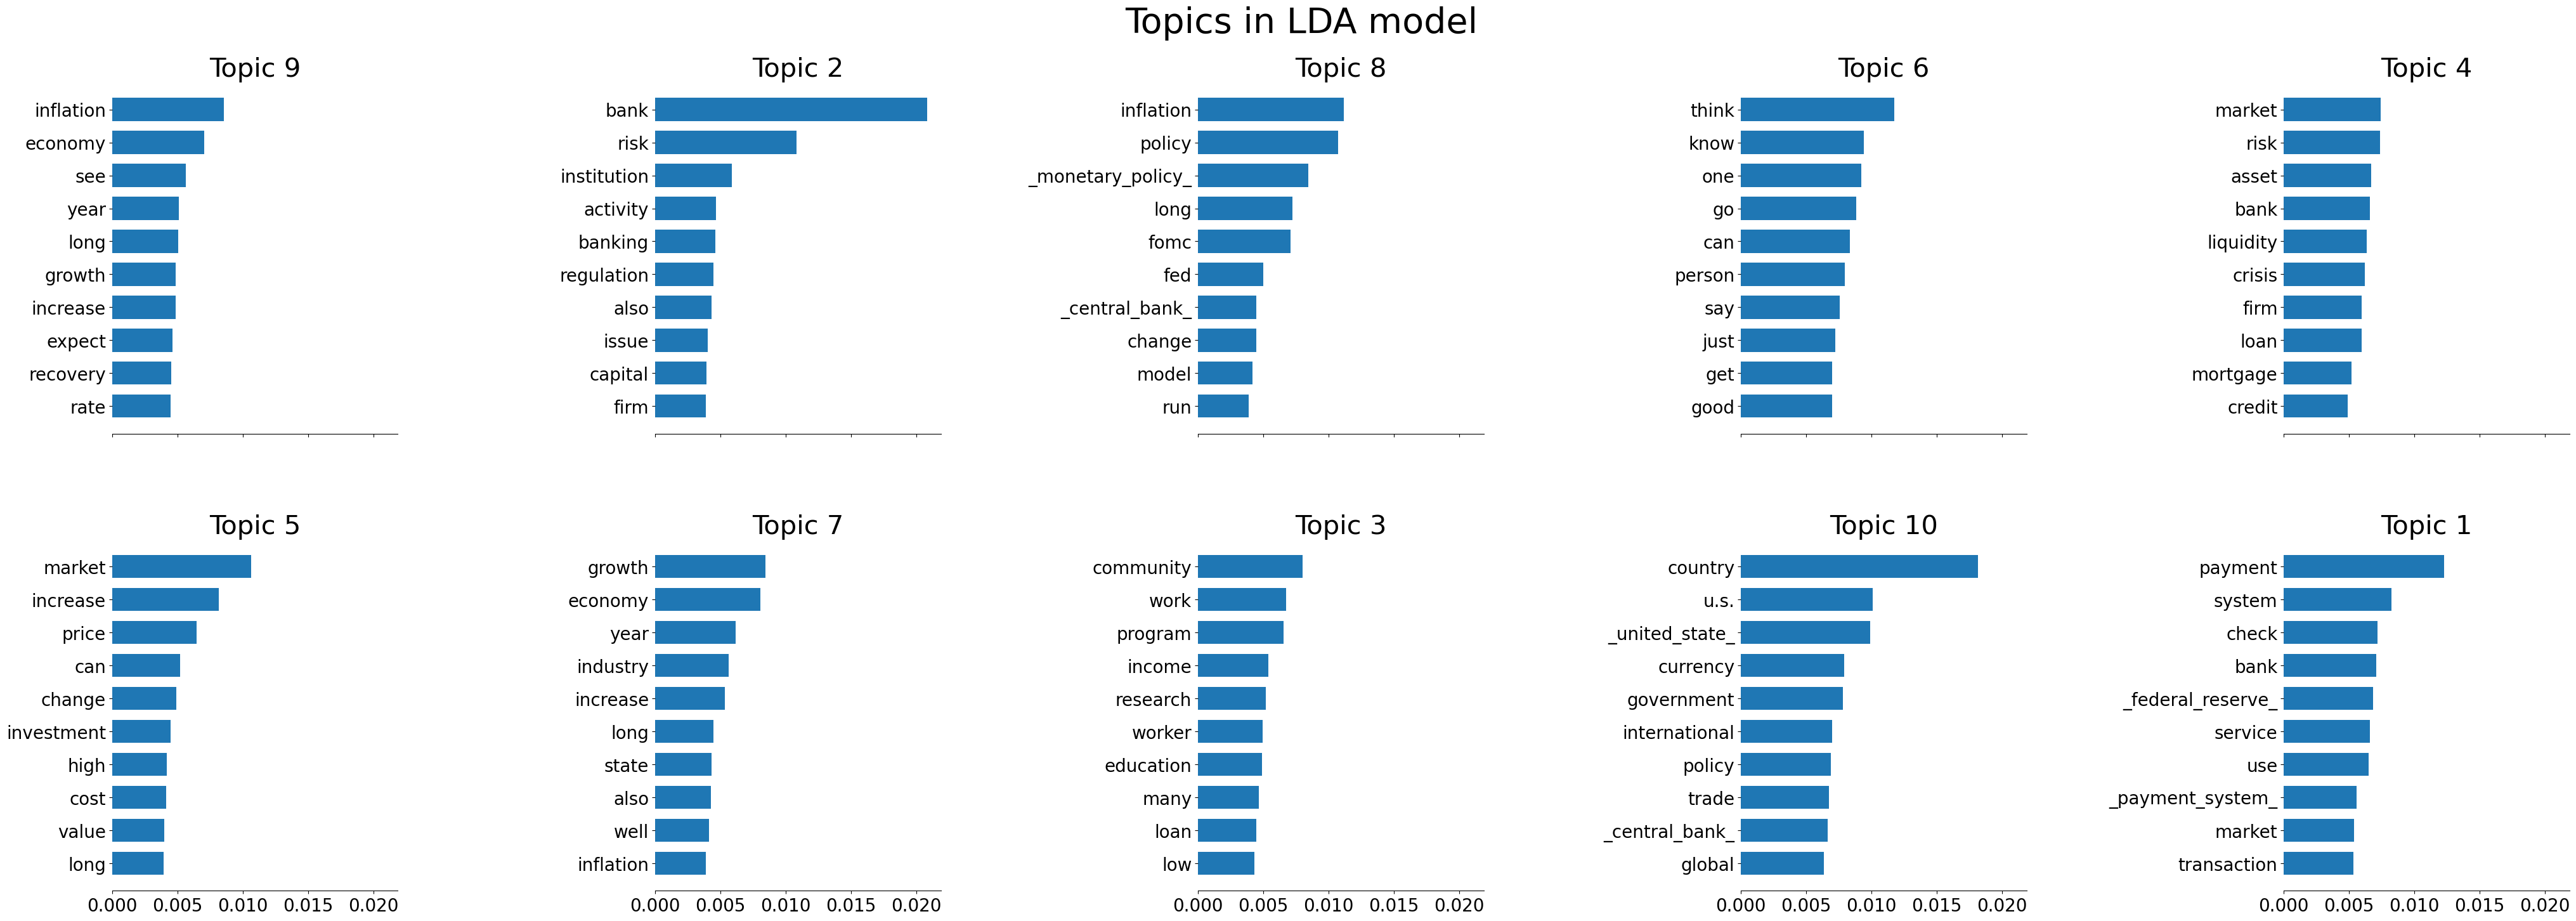

In [37]:
plot_top_words(lda_10_filtered, features_names, N_COMPONENTS, n_top_words, "Topics in LDA model", 'LDA/lda_10_lemma_filtered.png')


In [38]:
feature_names = vectorizer.get_feature_names_out()
print_top_words(lda_10_filtered, feature_names, n_top_words=10)


Topic 0: payment | system | check | bank | _federal_reserve_ | service | use | _payment_system_ | market | transaction
Topic 1: bank | risk | institution | activity | banking | regulation | also | issue | capital | firm
Topic 2: community | work | program | income | research | worker | education | many | loan | low
Topic 3: market | risk | asset | bank | liquidity | crisis | firm | loan | mortgage | credit
Topic 4: market | increase | price | can | change | investment | high | cost | value | long
Topic 5: think | know | one | go | can | person | say | just | get | good
Topic 6: growth | economy | year | industry | increase | long | state | also | well | inflation
Topic 7: inflation | policy | _monetary_policy_ | long | fomc | fed | _central_bank_ | change | model | run
Topic 8: inflation | economy | see | year | long | growth | increase | expect | recovery | rate
Topic 9: country | u.s. | _united_state_ | currency | government | international | policy | trade | _central_bank_ | global


In [39]:
N_COMPONENTS = 20
# Fit the LDA model
print(
    "Fitting LDA models with tf features"
)
lda_20_filtered = LatentDirichletAllocation(
    n_components=N_COMPONENTS,
    #doc_topic_prior=1/N_COMPONENTS, # adding 1 fake word
    #topic_word_prior=1/N_COMPONENTS, # adding 
    learning_method="online",
    max_iter=100,
    evaluate_every=1,
    verbose=True,
    random_state=118712
)
t0 = time()
lda_20_filtered.fit(tf)
print("done in %0.3fs." % (time() - t0))

Fitting LDA models with tf features
iteration: 1 of max_iter: 100, perplexity: 2849.8040
iteration: 2 of max_iter: 100, perplexity: 2801.9844
iteration: 3 of max_iter: 100, perplexity: 2784.5693
iteration: 4 of max_iter: 100, perplexity: 2775.3469
iteration: 5 of max_iter: 100, perplexity: 2769.5926
iteration: 6 of max_iter: 100, perplexity: 2765.6024
iteration: 7 of max_iter: 100, perplexity: 2762.6757
iteration: 8 of max_iter: 100, perplexity: 2760.4348
iteration: 9 of max_iter: 100, perplexity: 2758.6628
iteration: 10 of max_iter: 100, perplexity: 2757.2143
iteration: 11 of max_iter: 100, perplexity: 2755.9957
iteration: 12 of max_iter: 100, perplexity: 2754.9482
iteration: 13 of max_iter: 100, perplexity: 2754.0451
iteration: 14 of max_iter: 100, perplexity: 2753.2695
iteration: 15 of max_iter: 100, perplexity: 2752.5756
iteration: 16 of max_iter: 100, perplexity: 2751.9611
iteration: 17 of max_iter: 100, perplexity: 2751.4162
iteration: 18 of max_iter: 100, perplexity: 2750.9403
i

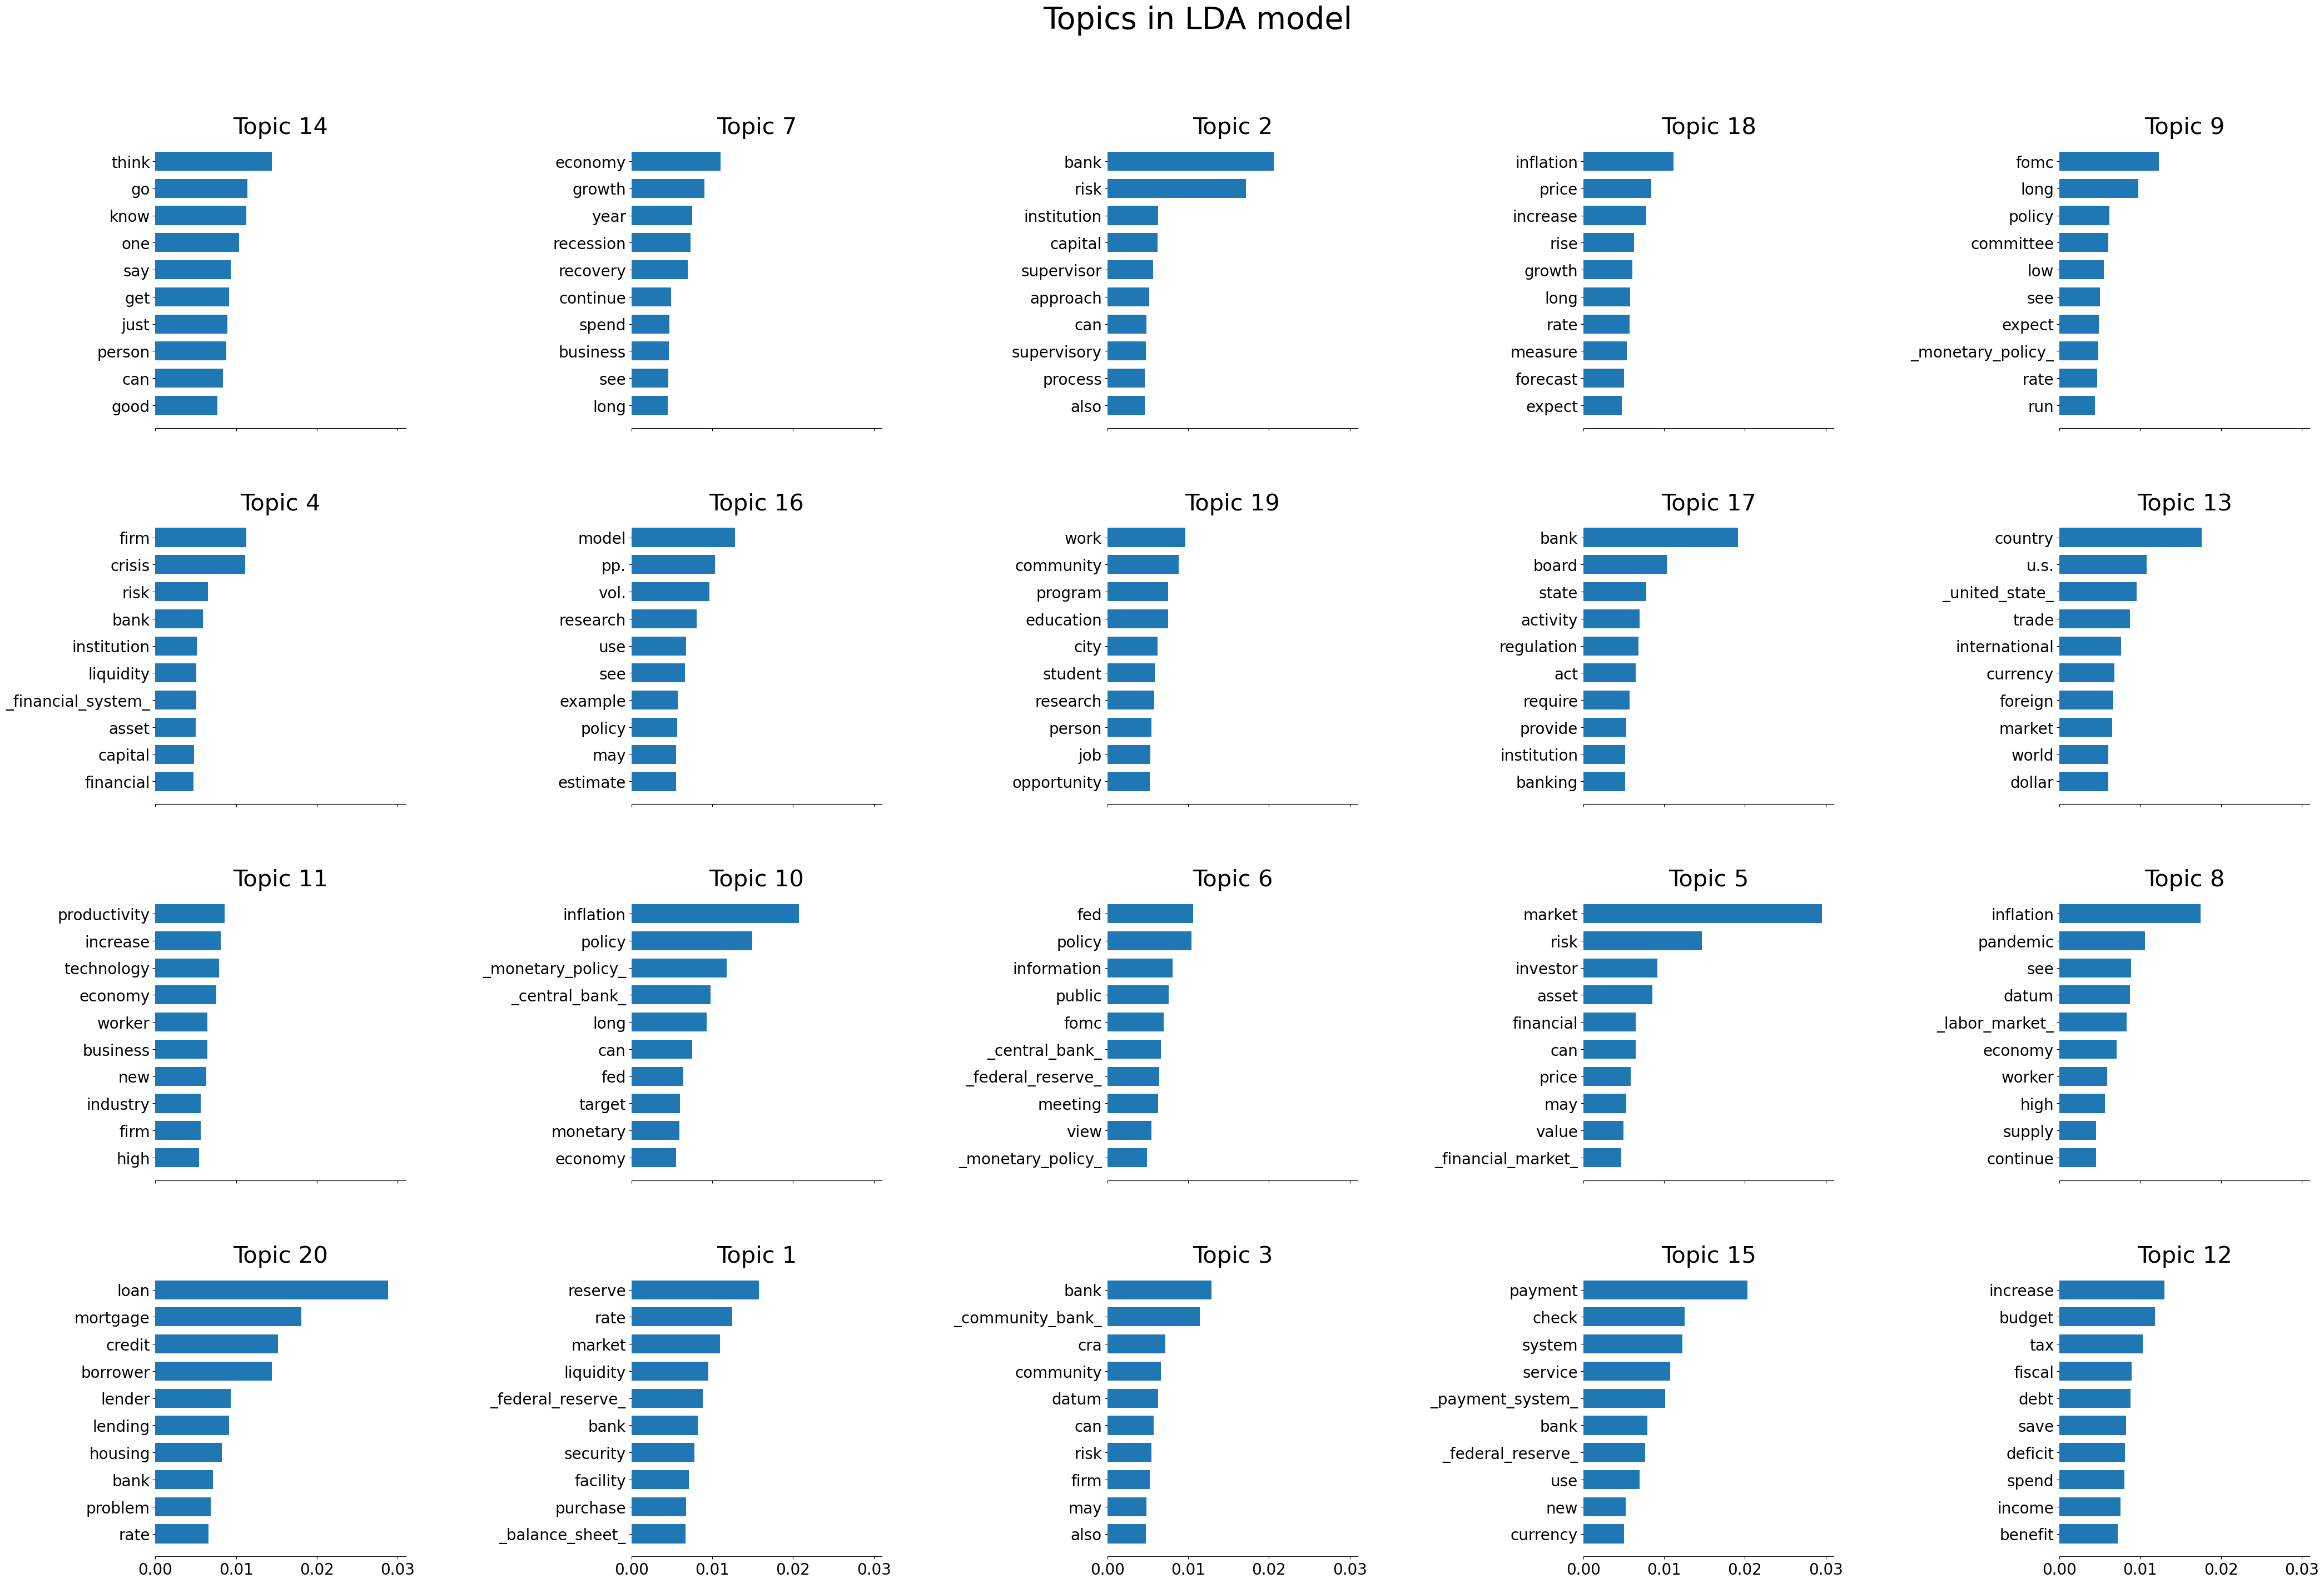

In [41]:
plot_top_words(lda_20_filtered, features_names, N_COMPONENTS, n_top_words, "Topics in LDA model", f'LDA/lda_{N_COMPONENTS}_lemma_filtered.png')


In [42]:
feature_names = vectorizer.get_feature_names_out()
print_top_words(lda_20_filtered, feature_names, n_top_words=10)


Topic 0: reserve | rate | market | liquidity | _federal_reserve_ | bank | security | facility | purchase | _balance_sheet_
Topic 1: bank | risk | institution | capital | supervisor | approach | can | supervisory | process | also
Topic 2: bank | _community_bank_ | cra | community | datum | can | risk | firm | may | also
Topic 3: firm | crisis | risk | bank | institution | liquidity | _financial_system_ | asset | capital | financial
Topic 4: market | risk | investor | asset | financial | can | price | may | value | _financial_market_
Topic 5: fed | policy | information | public | fomc | _central_bank_ | _federal_reserve_ | meeting | view | _monetary_policy_
Topic 6: economy | growth | year | recession | recovery | continue | spend | business | see | long
Topic 7: inflation | pandemic | see | datum | _labor_market_ | economy | worker | high | supply | continue
Topic 8: fomc | long | policy | committee | low | see | expect | _monetary_policy_ | rate | run
Topic 9: inflation | policy | _mon

In [43]:
N_COMPONENTS = 40
# Fit the LDA model
print(
    "Fitting LDA models with tf features"
)
lda_40_filtered = LatentDirichletAllocation(
    n_components=N_COMPONENTS,
    #doc_topic_prior=1/N_COMPONENTS, # adding 1 fake word
    #topic_word_prior=1/N_COMPONENTS, # adding 
    learning_method="online",
    max_iter=100,
    evaluate_every=1,
    verbose=True,
    random_state=118712
)
t0 = time()
lda_40_filtered.fit(tf)
print("done in %0.3fs." % (time() - t0))

Fitting LDA models with tf features
iteration: 1 of max_iter: 100, perplexity: 2818.2623
iteration: 2 of max_iter: 100, perplexity: 2755.5922
iteration: 3 of max_iter: 100, perplexity: 2735.6706
iteration: 4 of max_iter: 100, perplexity: 2725.7402
iteration: 5 of max_iter: 100, perplexity: 2719.6927
iteration: 6 of max_iter: 100, perplexity: 2715.5294
iteration: 7 of max_iter: 100, perplexity: 2712.4388
iteration: 8 of max_iter: 100, perplexity: 2710.0575
iteration: 9 of max_iter: 100, perplexity: 2708.1252
iteration: 10 of max_iter: 100, perplexity: 2706.5412
iteration: 11 of max_iter: 100, perplexity: 2705.1884
iteration: 12 of max_iter: 100, perplexity: 2704.0129
iteration: 13 of max_iter: 100, perplexity: 2703.0092
iteration: 14 of max_iter: 100, perplexity: 2702.1273
iteration: 15 of max_iter: 100, perplexity: 2701.3474
iteration: 16 of max_iter: 100, perplexity: 2700.6440
iteration: 17 of max_iter: 100, perplexity: 2699.9982
iteration: 18 of max_iter: 100, perplexity: 2699.4446
i

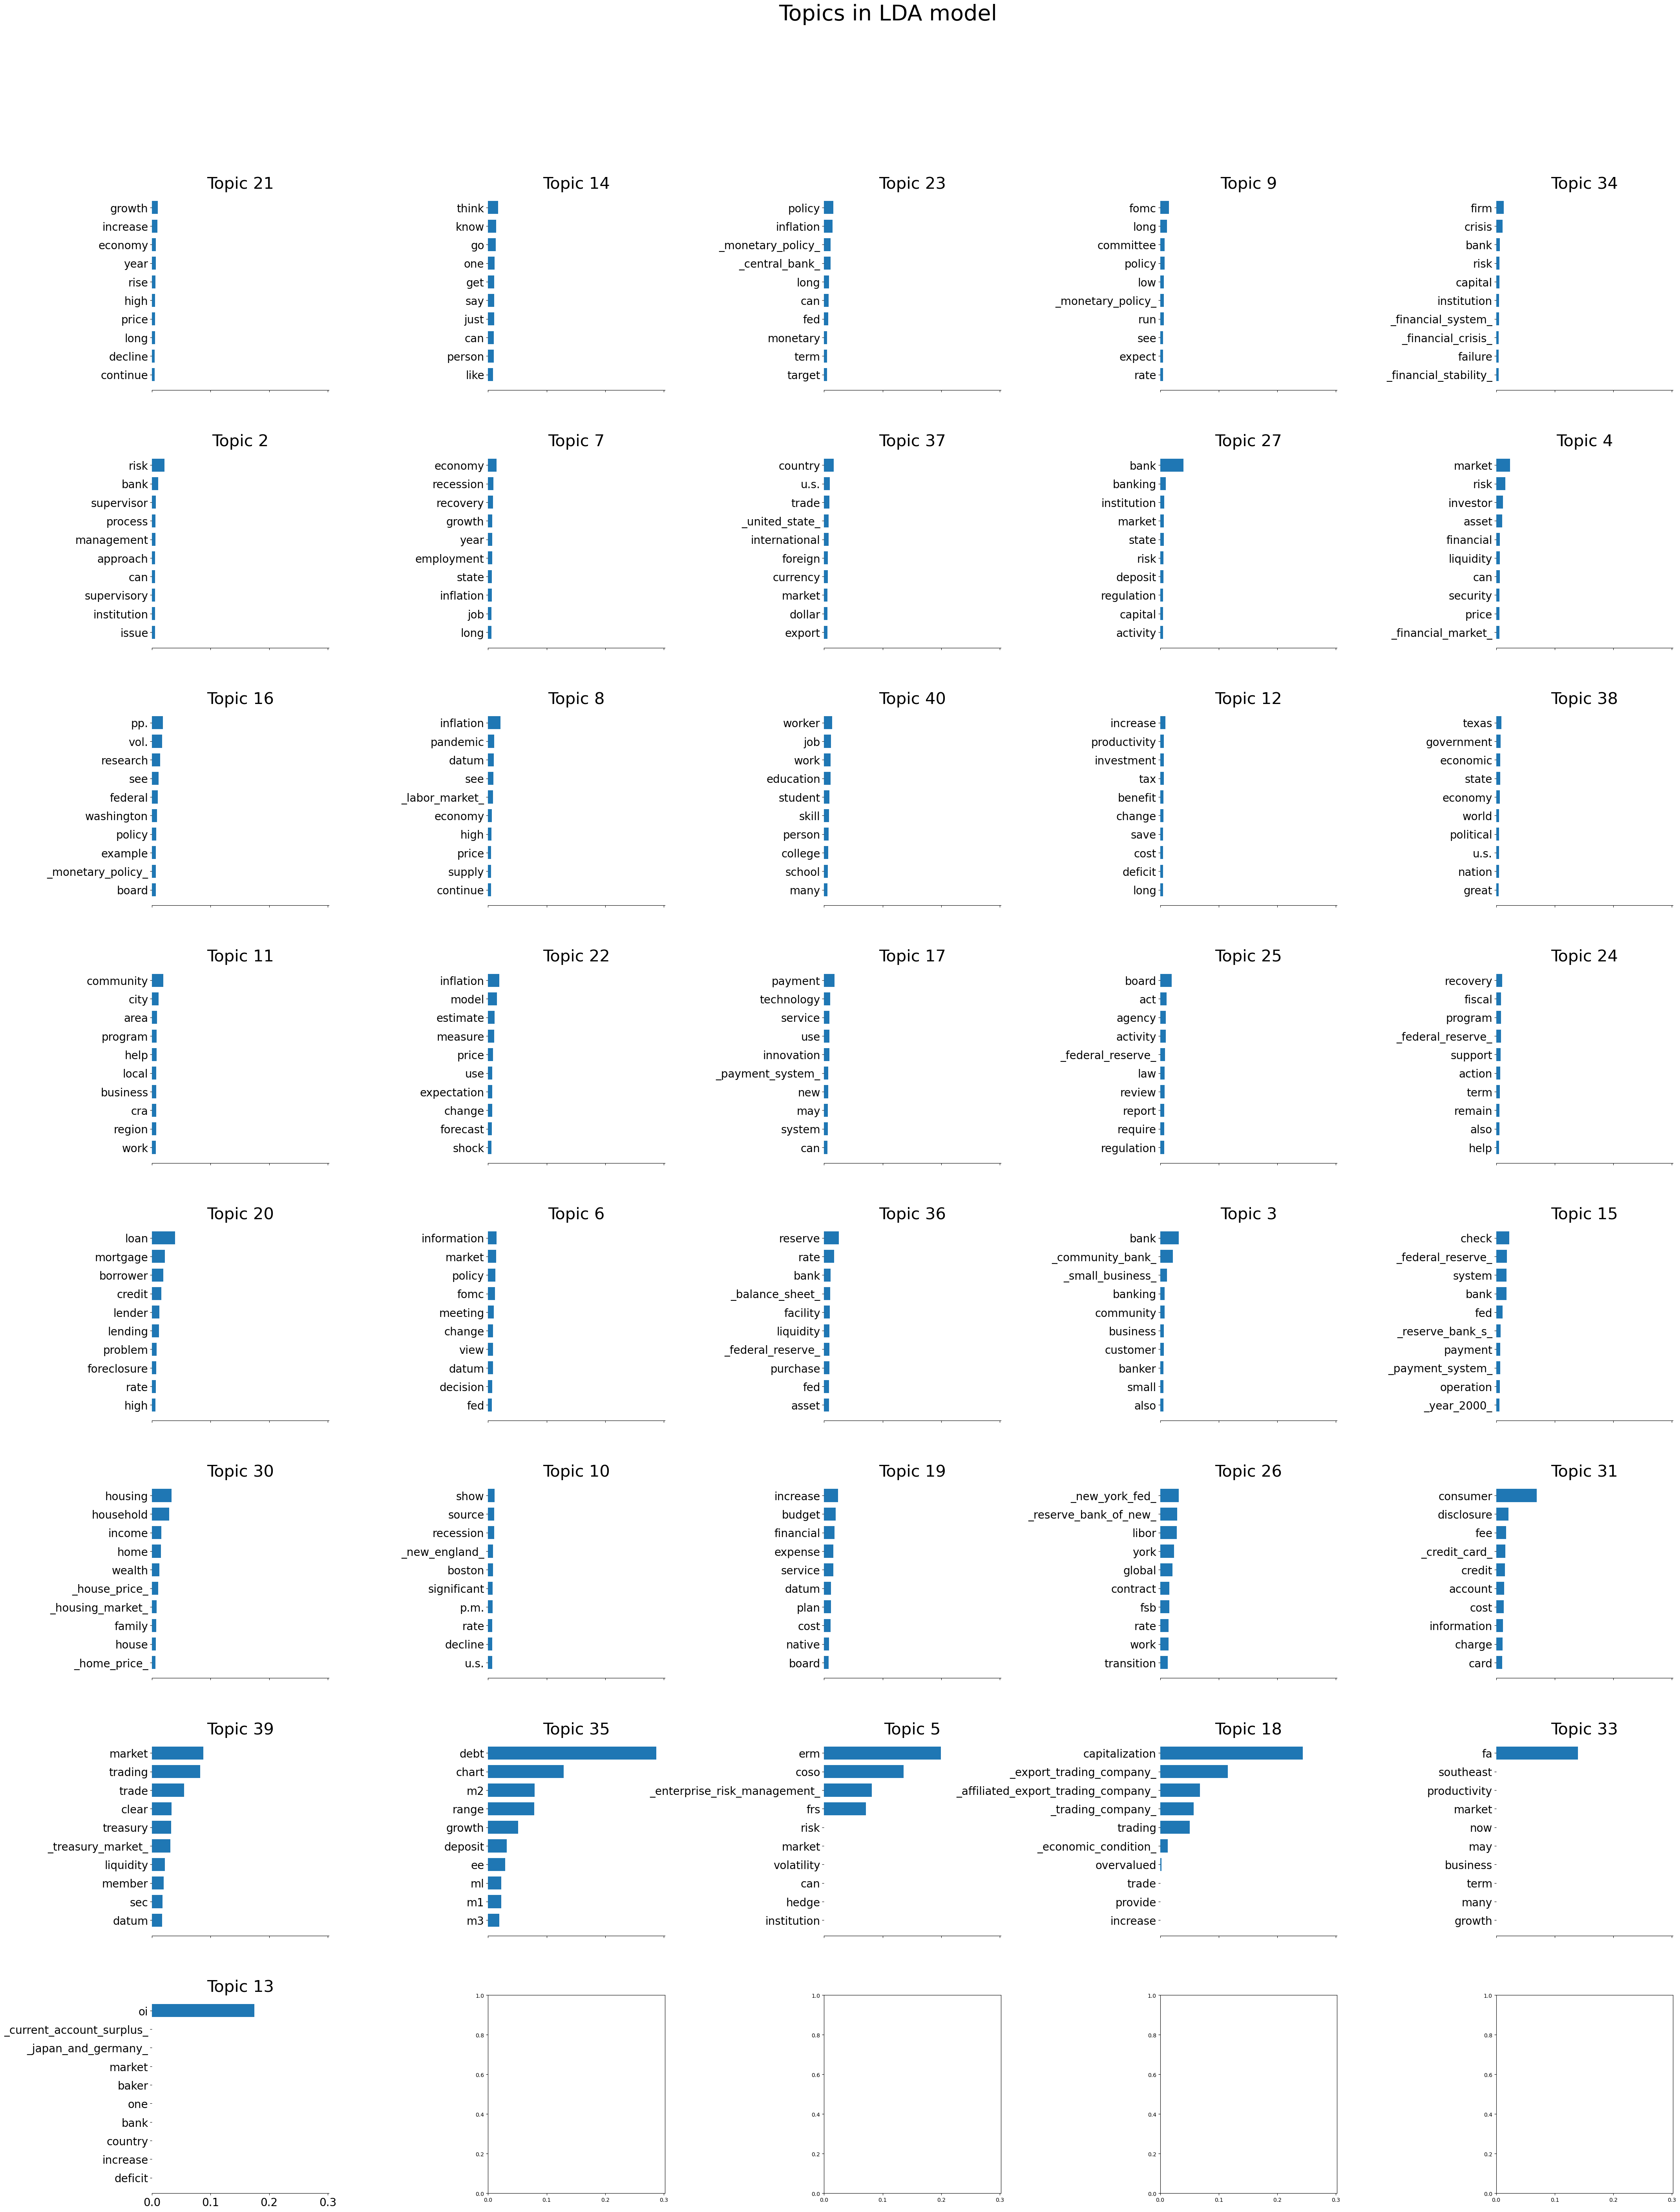

In [45]:
plot_top_words(lda_40_filtered, features_names, N_COMPONENTS, n_top_words, "Topics in LDA model", 'LDA/lda_40_lemma_filtered.png')


In [46]:
feature_names = vectorizer.get_feature_names_out()
print_top_words(lda_40_filtered, feature_names, n_top_words=10)


Topic 0: _digital_currency_ | bank | _payment_system_ | liquidity | can | _electronic_money_ | make | system | _federal_reserve_ | risk
Topic 1: risk | bank | supervisor | process | management | approach | can | supervisory | institution | issue
Topic 2: bank | _community_bank_ | _small_business_ | banking | community | business | customer | banker | small | also
Topic 3: market | risk | investor | asset | financial | liquidity | can | security | price | _financial_market_
Topic 4: erm | coso | _enterprise_risk_management_ | frs | risk | market | volatility | can | hedge | institution
Topic 5: information | market | policy | fomc | meeting | change | view | datum | decision | fed
Topic 6: economy | recession | recovery | growth | year | employment | state | inflation | job | long
Topic 7: inflation | pandemic | datum | see | _labor_market_ | economy | high | price | supply | continue
Topic 8: fomc | long | committee | policy | low | _monetary_policy_ | run | see | expect | rate
Topic 9

In [ ]:
# Le topic sur la politique a disparu...

In [47]:
N_COMPONENTS = 30
# Fit the LDA model
print(
    "Fitting LDA models with tf features"
)
lda_30_filtered = LatentDirichletAllocation(
    n_components=N_COMPONENTS,
    #doc_topic_prior=1/N_COMPONENTS, # adding 1 fake word
    #topic_word_prior=1/N_COMPONENTS, # adding 
    learning_method="online",
    max_iter=100,
    evaluate_every=1,
    verbose=True,
    random_state=118712
)
t0 = time()
lda_30_filtered.fit(tf)
print("done in %0.3fs." % (time() - t0))

Fitting LDA models with tf features
iteration: 1 of max_iter: 100, perplexity: 2837.1350
iteration: 2 of max_iter: 100, perplexity: 2779.9287
iteration: 3 of max_iter: 100, perplexity: 2760.1606
iteration: 4 of max_iter: 100, perplexity: 2749.8460
iteration: 5 of max_iter: 100, perplexity: 2743.2441
iteration: 6 of max_iter: 100, perplexity: 2738.6360
iteration: 7 of max_iter: 100, perplexity: 2735.1552
iteration: 8 of max_iter: 100, perplexity: 2732.4196
iteration: 9 of max_iter: 100, perplexity: 2730.1887
iteration: 10 of max_iter: 100, perplexity: 2728.3341
iteration: 11 of max_iter: 100, perplexity: 2726.7474
iteration: 12 of max_iter: 100, perplexity: 2725.3865
iteration: 13 of max_iter: 100, perplexity: 2724.1994
iteration: 14 of max_iter: 100, perplexity: 2723.1476
iteration: 15 of max_iter: 100, perplexity: 2722.2200
iteration: 16 of max_iter: 100, perplexity: 2721.3821
iteration: 17 of max_iter: 100, perplexity: 2720.6118
iteration: 18 of max_iter: 100, perplexity: 2719.9021
i

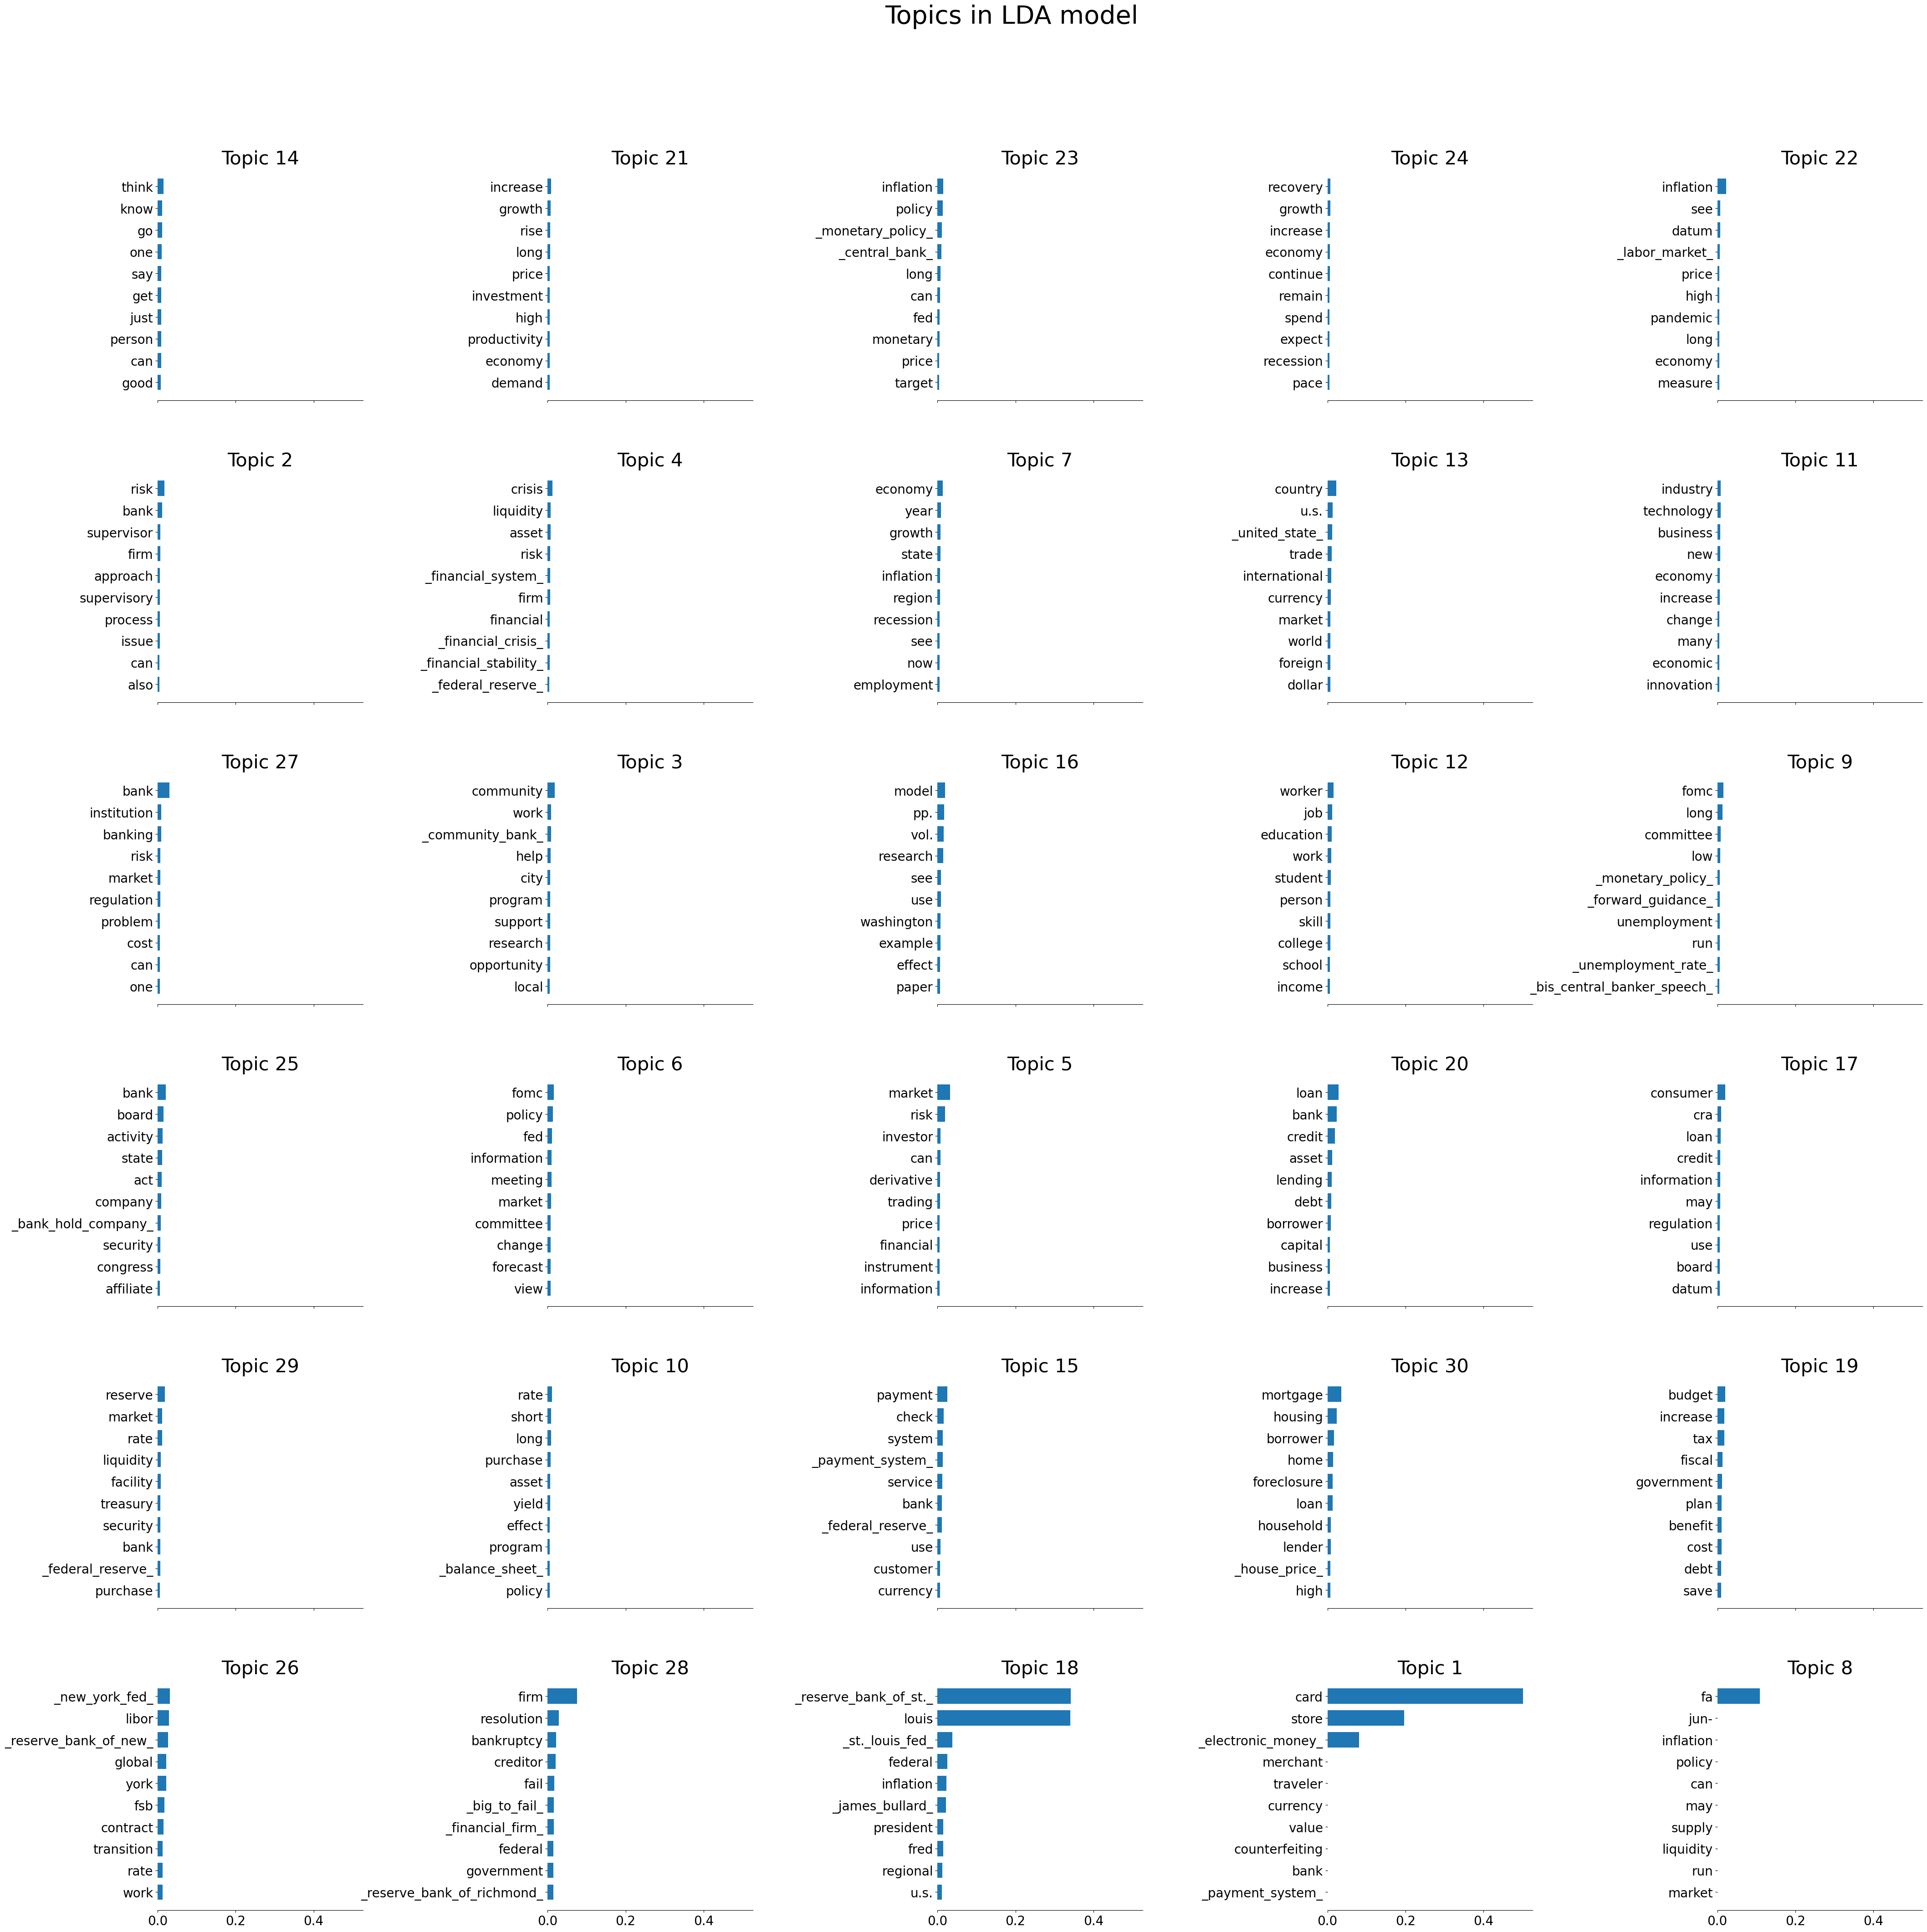

In [49]:
plot_top_words(lda_30_filtered, features_names, N_COMPONENTS, n_top_words, "Topics in LDA model", 'LDA/lda_30_lemma_filtered.png')


In [50]:
feature_names = vectorizer.get_feature_names_out()
print_top_words(lda_30_filtered, feature_names, n_top_words=10)


Topic 0: card | store | _electronic_money_ | merchant | traveler | currency | value | counterfeiting | bank | _payment_system_
Topic 1: risk | bank | supervisor | firm | approach | supervisory | process | issue | can | also
Topic 2: community | work | _community_bank_ | help | city | program | support | research | opportunity | local
Topic 3: crisis | liquidity | asset | risk | _financial_system_ | firm | financial | _financial_crisis_ | _financial_stability_ | _federal_reserve_
Topic 4: market | risk | investor | can | derivative | trading | price | financial | instrument | information
Topic 5: fomc | policy | fed | information | meeting | market | committee | change | forecast | view
Topic 6: economy | year | growth | state | inflation | region | recession | see | now | employment
Topic 7: fa | jun- | inflation | policy | can | may | supply | liquidity | run | market
Topic 8: fomc | long | committee | low | _monetary_policy_ | _forward_guidance_ | unemployment | run | _unemployment_r

In [ ]:
# Politique

In [316]:
lda_80_filtered.components_.shape

(80, 11028)

In [323]:
np.argmax(features_names == 'republican')

np.int64(8073)

In [324]:
features_names[8073]

'republican'

In [326]:
lda_80_filtered.components_[:, 8073].argmax()

np.int64(7)

In [333]:
np.argmax(features_names == 'democratic')

np.int64(0)

In [338]:
np.argmax(features_names == 'congress')

np.int64(662)

In [339]:
features_names[662]

'congress'

In [340]:
lda_80_filtered.components_[:, 662].argmax()

np.int64(7)

In [344]:
lda_80_filtered.components_[7, :]

array([0.0125, 0.0125, 0.0125, ..., 0.0125, 0.0125, 0.0125])

In [349]:
# Top words of topic 7
features_names[lda_80_filtered.components_[7, :].argsort()[-100:][::-1]]

array(['day', 'vote', 'bill', 'start', 'call', 'congress', 'member',
       'mr.', 'subcommittee', 'record', '_federal_reserve_', 'pass',
       'legislation', 'requirement', 'stand', 'meet', 'understanding',
       'house', 'administration', 'letter', 'name', 'voting', 'practice',
       '_feed_fund_', 'carry', 'serve', 'agency', 'rps', 'fail',
       'awfully', '_one_or_two_', '_policy_record_', 'criticism',
       'instruction', '_time_to_time_', 'legislative', 'free',
       'negotiation', 'cone', 'formal', 'majority', 'senate',
       '_just_take_', 'lock', 'statute', '_bank_of_new_york_', 'file',
       'amendment', 'fisher', 'therefore', "_'s_no_question_", 'request',
       'unhappy', '_symmetric_language_', 'martin', 'affair',
       '_comment_or_question_', 'rally', 'statutory', 'repos',
       '_discount_rate_change_', 'counsel', '_bill_english_',
       'justification', 'evening', '_governor_coldwell_', 'senator',
       '_telephone_conference_', '_current_estimate_',
     

In [366]:
# Fiscal

In [367]:
np.argmax(features_names == 'debt')

np.int64(272)

In [369]:
lda_80_filtered.components_[:, 272].argmax()

np.int64(72)

In [370]:
np.argmax(features_names == 'budget')

np.int64(885)

In [371]:
lda_80_filtered.components_[:, 885].argmax()

np.int64(74)

In [383]:
lda_80_filtered.components_[:, 885].argsort()[-5:][::-1]

array([74, 33, 77, 79, 76])

In [372]:
np.argmax(features_names == 'deficit')

np.int64(901)

In [373]:
lda_80_filtered.components_[:, 901].argmax()

np.int64(45)

In [384]:
lda_80_filtered.components_[:, 901].argsort()[-5:][::-1]

array([45, 79, 77, 78, 75])

In [374]:
np.argmax(features_names == 'fiscal')

np.int64(633)

In [375]:
lda_80_filtered.components_[:, 633].argmax()

np.int64(48)

In [385]:
lda_80_filtered.components_[:, 633].argsort()[-5:][::-1]

array([48, 79, 77, 78, 75])

In [376]:
np.argmax(features_names == 'tax')

np.int64(533)

In [377]:
lda_80_filtered.components_[:, 533].argmax()

np.int64(77)

In [386]:
lda_80_filtered.components_[:, 533].argsort()[-5:][::-1]

array([77, 15, 46, 79, 75])

In [ ]:
# 77, 79 reviennent

In [387]:
# Top words of topic 7
features_names[lda_80_filtered.components_[77, :].argsort()[-100:][::-1]]

array(['policy', '_monetary_policy_', 'either', 'cost', 'question',
       'work', 'time', 'approach', 'economy', 'economic', 'view', 'find',
       'set', 'goal', 'different', 'today', 'base', 'process',
       'particular', 'forward', 'outcome', 'framework', 'explain',
       'actually', 'broad', 'provide', 'consider', 'tax', 'involve',
       'simply', 'instead', 'perspective', 'stimulus', "_let_'s_",
       'achieve', 'course', 'without', 'analysis', 'start', 'choose',
       'regard', 'whether', 'determine', 'level', 'difficult', 'fed',
       'unemployment', 'type', 'paper', 'must', 'address', 'package',
       'adjust', 'zero', 'inflation', 'experience', 'big', 'discussion',
       'arise', '_inflation_target_', 'context', 'follow', 'debate',
       'temporary', 'possible', 'form', 'fact', 'theory', 'research',
       '_full_employment_', 'argue', 'much', 'influence', 'great', 'kind',
       'path', 'allow', 'consistent', 'choice', 'design', 'feed',
       'evolve', 'role', 'not

In [388]:
# Top words of topic 7
features_names[lda_80_filtered.components_[79, :].argsort()[-100:][::-1]]

array(['number', 'high', 'figure', 'low', 'assume', 'relationship', 'gnp',
       '_money_supply_', 'target', "_'s_right_", 'whatever', 'accept',
       'imply', 'send', 'anyway', 'context', '_last_year_', 'behave',
       'operational', 'bias', 'tight', 'explanation', '_want_to_go_',
       'wise', 'notice', 'much', 'happen', 'upper', 'publish',
       '_depend_upon_', 'technique', '_mr._axilrod_',
       '_end_of_the_range_', 'curious', 'message', 'bea', 'fact', 'allow',
       '_long_period_of_time_', '_six_week_', 'apart',
       '_decline_in_interest_rate_', '_broad_aggregate_',
       '_just_do_not_know_', '_1/_2_to_7_', '_try_to_keep_', 'speaker',
       'presume', 'tunnel', '_probably_will_', '_fund_rate_will_',
       'hindsight', '_quarterly_average_', '_change_the_range_',
       'disturb', 'differently', 'someplace', 'discount', 'hunch',
       '_capacity_constraint_', '2._7_percent_', 'awful',
       '_different_type_', '_rate_be_high_', 'halfway', 'lengthy',
       '_run_

### Back to Dataframe and rearrange it back


In [66]:
# import pandas as pd
# from sklearn.decomposition import LatentDirichletAllocation
# from sklearn.feature_extraction.text import CountVectorizer

# # Sample data
# documents = [
#     "I love programming in Python",
#     "Python and machine learning are fun",
#     "I enjoy learning new things",
#     "Machine learning is fascinating"
# ]

# # Vectorize the documents
# vectorizer = CountVectorizer()
# X = vectorizer.fit_transform(documents)

# # Fit the LDA model
# lda = LatentDirichletAllocation(n_components=2, random_state=42)
# lda.fit(X)

# Transform the data
Chosen = lda_20_filtered
lda_transformed = Chosen.transform(tf)

# Convert the topic distributions back to a DataFrame
df_topics = pd.DataFrame(lda_transformed, columns=[f'Topic {i}' for i in range(Chosen.n_components)])

print(df_topics.head())
print(df_topics.shape)


    Topic 0   Topic 1   Topic 2   Topic 3   Topic 4   Topic 5   Topic 6  \
0  0.000079  0.000079  0.000079  0.000079  0.000079  0.015377  0.632012   
1  0.000142  0.000142  0.000142  0.000142  0.072433  0.251969  0.000142   
2  0.000035  0.000035  0.000035  0.000035  0.032456  0.222365  0.000035   
3  0.082441  0.000032  0.006490  0.004144  0.076119  0.000032  0.415775   
4  0.000047  0.008200  0.000047  0.272163  0.000047  0.078493  0.000047   

    Topic 7   Topic 8   Topic 9  Topic 10  Topic 11  Topic 12  Topic 13  \
0  0.000079  0.010121  0.153301  0.000079  0.000079  0.021622  0.166458   
1  0.197327  0.374509  0.000142  0.000142  0.000142  0.000142  0.036068   
2  0.000035  0.015470  0.447514  0.008913  0.000035  0.000035  0.000035   
3  0.023621  0.000032  0.000032  0.000032  0.000032  0.000032  0.000032   
4  0.003029  0.000047  0.000047  0.000047  0.017621  0.012747  0.402791   

   Topic 14  Topic 15  Topic 16  Topic 17  Topic 18  Topic 19  
0  0.000079  0.000079  0.000079  0

In [67]:
shuffled_df2 = shuffled_df.reset_index()
shuffled_df2.head()

,index,District,MultSpeakers,VideoForm,Article,content,title,speaker,location,link,...,second_order_coherence,upStrain,board_role,IsBpres,title_main,name,dateOnly,timeOnly,score,text
0,5876,SanFrancisco,NaN,False,False,"HOLD FOR RELEASE AT 8:30 A.M. PST FRIDAY, NOVE...",Shifting to Another Gear: Monetary Policy in 1...,Robert T. Parry,Federal Reserve Bank of San Francisco,https://fraser.stlouisfed.org/files/docs/histo...,...,0.367792,4.531372,Not Board,True,shifting to another gear monetary policy in 19...,robert parry,1994-11-04,NaN,NaN,"HOLD FOR RELEASE AT 8:30 A.M. PST FRIDAY, NOVE..."
1,6306,StLouis,NaN,False,False,President's Message: The Fed's Latest Balance-...,The Fed's Latest Balance-Sheet Policy: What Co...,James Bullard,Federal Reserve Bank of St Louis,https://www.stlouisfed.org/publications/region...,...,0.443078,4.847228,Not Board,True,the feds latest balancesheet policy what const...,james bullard,2013-01-18,00:00:00,90.25641,President's Message: The Fed's Latest Balance-...
2,798,BoardGovernors,NaN,False,False,"Roger W Ferguson, Jr: Panel discussion - safeg...",Panel discussion - safeguarding good policy pr...,Roger W Ferguson,Board of Governors of the Federal Reserve,https://www.bis.org/review/r041013k.pdf,...,0.468183,5.560085,Vice Chair,False,panel discussion safeguarding good policy pra...,roger ferguson,2004-10-08,NaN,NaN,"Roger W Ferguson, Jr: Panel discussion - safeg..."
3,5013,Richmond,NaN,False,False,Home News Speeches Jeffrey M Lacker 2008 Jeffr...,The Economic Outlook for 2008,Jeffrey M Lacker,Federal Reserve Bank of Richmond,https://www.richmondfed.org/press_room/speeche...,...,0.473368,4.214442,Not Board,False,the economic outlook for 2008,jeffrey lacker,2008-02-05,NaN,NaN,Home News Speeches Jeffrey M Lacker 2008 Jeffr...
4,4609,Dallas,NaN,False,False,14:23 Ending 'Too Big to Fail' Speech by Richa...,Ending 'Too Big to Fail',Richard W. Fisher,Federal Reserve Bank of Dallas,https://www.dallasfed.org/news/speeches/fisher...,...,0.410897,4.701037,Not Board,True,ending too big to fail,richard fisher,2013-03-16,14:00:00,100.00000,14:23 Ending 'Too Big to Fail' Speech by Richa...


In [68]:
dfTopic = pd.concat([shuffled_df2, df_topics], axis = 1)
print(dfTopic.shape)
dfTopic.head()

(7239, 105)


,index,District,MultSpeakers,VideoForm,Article,content,title,speaker,location,link,...,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19
0,5876,SanFrancisco,NaN,False,False,"HOLD FOR RELEASE AT 8:30 A.M. PST FRIDAY, NOVE...",Shifting to Another Gear: Monetary Policy in 1...,Robert T. Parry,Federal Reserve Bank of San Francisco,https://fraser.stlouisfed.org/files/docs/histo...,...,0.000079,0.000079,0.021622,0.166458,0.000079,0.000079,0.000079,0.000079,0.000079,0.000079
1,6306,StLouis,NaN,False,False,President's Message: The Fed's Latest Balance-...,The Fed's Latest Balance-Sheet Policy: What Co...,James Bullard,Federal Reserve Bank of St Louis,https://www.stlouisfed.org/publications/region...,...,0.000142,0.000142,0.000142,0.036068,0.000142,0.031602,0.000142,0.000142,0.034240,0.000142
2,798,BoardGovernors,NaN,False,False,"Roger W Ferguson, Jr: Panel discussion - safeg...",Panel discussion - safeguarding good policy pr...,Roger W Ferguson,Board of Governors of the Federal Reserve,https://www.bis.org/review/r041013k.pdf,...,0.008913,0.000035,0.000035,0.000035,0.000035,0.134300,0.000035,0.138525,0.000035,0.000035
3,5013,Richmond,NaN,False,False,Home News Speeches Jeffrey M Lacker 2008 Jeffr...,The Economic Outlook for 2008,Jeffrey M Lacker,Federal Reserve Bank of Richmond,https://www.richmondfed.org/press_room/speeche...,...,0.000032,0.000032,0.000032,0.000032,0.000032,0.000032,0.000032,0.180071,0.000032,0.210953
4,4609,Dallas,NaN,False,False,14:23 Ending 'Too Big to Fail' Speech by Richa...,Ending 'Too Big to Fail',Richard W. Fisher,Federal Reserve Bank of Dallas,https://www.dallasfed.org/news/speeches/fisher...,...,0.000047,0.017621,0.012747,0.402791,0.002780,0.034951,0.166751,0.000047,0.000047,0.000047


In [69]:
# Set 'Name' column as index
dfTopic.set_index('index', inplace=True)

# Sort the DataFrame by the index
dfTopic.sort_index(inplace=True)

dfTopic.head()


,District,MultSpeakers,VideoForm,Article,content,title,speaker,location,link,date,...,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19
index,,,,,,,,,,,,,,,,,,,,,
0,Boston,0.0,False,False,"Economic Resilience, Amid Elevated Tariffs and...",Perspectives on the Economy from Susan M. Collins,Susan M. Collins,"Massachusetts towns of Fall River, New Bedford...",https://www.bostonfed.org/news-and-events/spee...,2025-06-25,...,0.054367,0.000094,0.000094,0.000094,0.000094,0.000094,0.000094,0.157189,0.174159,0.000094
1,Boston,0.0,False,False,I am pleased to welcome all of you to the Fede...,Welcoming Remarks at the forum on “Meeting the...,Susan M. Collins,Federal Reserve Bank of Boston,https://www.bostonfed.org/news-and-events/spee...,2024-09-30,...,0.000171,0.000171,0.000171,0.061778,0.000171,0.000171,0.000171,0.000171,0.512725,0.022568
2,Boston,0.0,False,False,Takeaways from Boston Fed President Susan M. C...,A Partnership for Progress,Susan M. Collins,"Lawrence, Massachusetts",https://www.bostonfed.org/news-and-events/spee...,2024-06-18,...,0.007728,0.000036,0.000036,0.088362,0.023008,0.000036,0.000036,0.000036,0.567451,0.000036
3,Boston,0.0,False,False,Boston Fed President and CEO Susan M. Collins'...,Reflections on Uncertainty and Patience in Mon...,Susan M. Collins,"Cambridge, Massachusetts",https://www.bostonfed.org/news-and-events/spee...,2024-05-08,...,0.024423,0.000028,0.000028,0.044043,0.054702,0.014881,0.000028,0.145100,0.094085,0.000028
4,Boston,1.0,True,False,"hi, good afternoon everyone. my name is Beth B...",Remarks for the National Association of Corpor...,Susan M. Collins,Federal Reserve Bank of Boston,https://www.bostonfed.org/news-and-events/spee...,2024-04-16,...,0.000029,0.000010,0.000010,0.554396,0.055425,0.000010,0.000010,0.040715,0.097247,0.008184


In [71]:
dfTopic.to_csv('FedSpeechesTopic.csv', date_format='%Y-%m-%d', index = False)


In [78]:
dfTopic.shape

(7239, 104)

# Compression des annotations Stanza

In [309]:
# import gzip

In [310]:
# from_json[3]

[[{'id': (1,),
   'text': 'What',
   'lemma': 'what',
   'start_char': 0,
   'end_char': 4},
  {'id': (2,),
   'text': 'bothers',
   'lemma': 'bother',
   'start_char': 5,
   'end_char': 12},
  {'id': (3,),
   'text': 'me',
   'lemma': 'I',
   'start_char': 13,
   'end_char': 15,
   'misc': 'SpaceAfter=No'},
  {'id': (4,),
   'text': '--',
   'lemma': '--',
   'start_char': 15,
   'end_char': 17,
   'misc': 'SpaceAfter=No'},
  {'id': (5,),
   'text': 'and',
   'lemma': 'and',
   'start_char': 17,
   'end_char': 20},
  {'id': (6,), 'text': 'I', 'lemma': 'I', 'start_char': 21, 'end_char': 22},
  {'id': (7,),
   'text': 'may',
   'lemma': 'may',
   'start_char': 23,
   'end_char': 26},
  {'id': (8,),
   'text': 'see',
   'lemma': 'see',
   'start_char': 27,
   'end_char': 30},
  {'id': (9,), 'text': 'it', 'lemma': 'it', 'start_char': 31, 'end_char': 33},
  {'id': (10,),
   'text': 'totally',
   'lemma': 'totally',
   'start_char': 34,
   'end_char': 41},
  {'id': (11,),
   'text': 'incorr

In [311]:
# with gzip.open('annotations_stanza_compressed.json', 'wt', encoding='UTF-8') as zipfile:
#     json.dump(from_json, zipfile)

In [350]:
# with gzip.open('annotations_stanza_compressed.json', 'rt', encoding='UTF-8') as zipfile:
#     from_compressed = json.load(zipfile)

In [357]:
# from_compressed[100000]

[[{'id': [1], 'text': 'I', 'lemma': 'I', 'start_char': 0, 'end_char': 1},
  {'id': [2],
   'text': 'appreciate',
   'lemma': 'appreciate',
   'start_char': 2,
   'end_char': 12},
  {'id': [3], 'text': 'the', 'lemma': 'the', 'start_char': 13, 'end_char': 16},
  {'id': [4],
   'text': 'opportunity',
   'lemma': 'opportunity',
   'start_char': 17,
   'end_char': 28},
  {'id': [5], 'text': 'to', 'lemma': 'to', 'start_char': 29, 'end_char': 31},
  {'id': [6],
   'text': 'talk',
   'lemma': 'talk',
   'start_char': 32,
   'end_char': 36},
  {'id': [7], 'text': 'at', 'lemma': 'at', 'start_char': 37, 'end_char': 39},
  {'id': [8], 'text': 'the', 'lemma': 'the', 'start_char': 40, 'end_char': 43},
  {'id': [9],
   'text': 'FOMC',
   'lemma': 'fomc',
   'start_char': 44,
   'end_char': 48},
  {'id': [10],
   'text': 'meeting',
   'lemma': 'meeting',
   'start_char': 49,
   'end_char': 56,
   'misc': 'SpaceAfter=No'},
  {'id': [11], 'text': '.', 'lemma': '.', 'start_char': 56, 'end_char': 57}],
 [

In [358]:
# from_json[100000]

[[{'id': (1,), 'text': 'I', 'lemma': 'I', 'start_char': 0, 'end_char': 1},
  {'id': (2,),
   'text': 'appreciate',
   'lemma': 'appreciate',
   'start_char': 2,
   'end_char': 12},
  {'id': (3,),
   'text': 'the',
   'lemma': 'the',
   'start_char': 13,
   'end_char': 16},
  {'id': (4,),
   'text': 'opportunity',
   'lemma': 'opportunity',
   'start_char': 17,
   'end_char': 28},
  {'id': (5,), 'text': 'to', 'lemma': 'to', 'start_char': 29, 'end_char': 31},
  {'id': (6,),
   'text': 'talk',
   'lemma': 'talk',
   'start_char': 32,
   'end_char': 36},
  {'id': (7,), 'text': 'at', 'lemma': 'at', 'start_char': 37, 'end_char': 39},
  {'id': (8,),
   'text': 'the',
   'lemma': 'the',
   'start_char': 40,
   'end_char': 43},
  {'id': (9,),
   'text': 'FOMC',
   'lemma': 'fomc',
   'start_char': 44,
   'end_char': 48},
  {'id': (10,),
   'text': 'meeting',
   'lemma': 'meeting',
   'start_char': 49,
   'end_char': 56,
   'misc': 'SpaceAfter=No'},
  {'id': (11,), 'text': '.', 'lemma': '.', 'st

# The end